# San Francisco Crime: Geospatial Analysis

Geospatial and temporal analysis of ~878k crime records (Kaggle *SF Crime Classification*). Coordinate imputation, EDA by category / district / hour, K-Means and DBSCAN hotspots, Voronoi coverage of existing stations, census cross-analysis, and a recommendation for the location and specialty of three new police stations.

*The notebook text is in Portuguese. An English summary of the approach and results is in the README of this folder.*

---

# Análise Geoespacial de Crimes: São Francisco


 Identificar as 3 regiões mais críticas de SF para recomendar localização e especialidade de novas delegacias policiais, com base em ~878 mil registros criminais (2003–2015).

---

| Dimensão | Valor |
|---|---|
| Dataset | SF Crime: Kaggle |
| Registros | ~878 mil ocorrências |
| Período | Jan 2003 – Mai 2015 |
| Colunas | Dates · Category · Descript · DayOfWeek · PdDistrict · Resolution · Address · X · Y |

**Estrutura do notebook:**  
`0` Setup → `1` Estudo do DF → `2` Limpeza Cirúrgica → `3–9` EDA (7 ângulos) → `10` WordCloud → `11` Network → `12` Clusterização → `13` Análises Extras → `14` Recomendação Final


## 0. Setup e Importações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import seaborn as sns
import networkx as nx
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# ── Tema dark global ──────────────────────────────────────────────────────
DARK_BG    = '#0d0f1a'
CARD_BG    = '#161929'
BORDER     = '#2a2d42'
TXT        = '#e8eaf0'
TXT_DIM    = '#8b8fa8'

plt.rcParams.update({
    'figure.facecolor' : DARK_BG,
    'axes.facecolor'   : CARD_BG,
    'axes.edgecolor'   : BORDER,
    'axes.labelcolor'  : TXT,
    'xtick.color'      : TXT_DIM,
    'ytick.color'      : TXT_DIM,
    'text.color'       : TXT,
    'grid.color'       : BORDER,
    'grid.alpha'       : 0.6,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

AMBER   = '#f5a623'
RED     = '#e74c3c'
GREEN   = '#2ecc71'
BLUE    = '#3498db'
PURPLE  = '#9b59b6'
TEAL    = '#1abc9c'
ORANGE  = '#e67e22'
PINK    = '#e91e63'

PALETTE = [AMBER, RED, GREEN, BLUE, PURPLE, TEAL, ORANGE, PINK, '#00bcd4','#cddc39']

CRIME_COLOR = {
    'Violento'        : RED,
    'Patrimonial'     : AMBER,
    'Drogas/Vícios'   : PURPLE,
    'Ordem Pública'   : ORANGE,
    'Mandados'        : BLUE,
    'Assistência Social': TEAL,
    'Admin/Outros'    : '#607d8b',
}

def fig_title(fig, title, subtitle=None):
    y = 1.01 if subtitle else 1.00
    fig.suptitle(title, fontsize=17, fontweight='bold', color=TXT, y=y)
    if subtitle:
        fig.text(0.5, y-0.03, subtitle, ha='center', fontsize=11, color=TXT_DIM)

print("✅  Setup OK")


✅  Setup OK


Fundo escuro nos graficos para destacar os mapas de calor.

## 0b. unir train + test



| Arquivo | Registros | Colunas únicas |
|---|---|---|
| `train.csv` | 878.049 | `Category`, `Descript`, `Resolution` |
| `test.csv`  | 884.262 | `Id` |
| **União geo** | **1.762.311** | `Dates`, `DayOfWeek`, `PdDistrict`, `Address`, `X`, `Y` |



**Estratégia adotada:**
```
df_geo   = train + test  (1.76M linhas)  → análises temporais, geoespaciais, distritos, endereços
df_crime = train only    (878k linhas)   → análises de tipo, categoria, descrição, resolução
```

---

## 0c. Tratamento de Coordenadas Inválidas: Imputação em Cascata

Os 143 registros problemáticos têm **valores sentinela** (`X=-120.5, Y=90.0`), não NaN.  
São apenas **0.008% do dataset**, mas deletá-los joga fora informações temporais e de distrito válidas.


| Passo | Método | Registros | Precisão |
|---|---|---|---|
| 1 | Mediana do mesmo endereço (normalizado) | 22 | ~metros |
| 2 | Mediana do distrito | 121 | ~500m–2km |
| 3 | Flag `coord_imputed=True` | todos | rastreável |




In [ ]:
import pandas as pd
import numpy as np

# ── 1. Carregar arquivos brutos ────────────────────────────────────────────
train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test.csv')

print(f"Train: {train_raw.shape}  |  colunas: {train_raw.columns.tolist()}")
print(f"Test : {test_raw.shape}   |  colunas: {test_raw.columns.tolist()}")

# ── 2. Montar df_geo (união das colunas comuns) ───────────────────────────
GEO_COLS = ['Dates','DayOfWeek','PdDistrict','Address','X','Y']
train_geo = train_raw[GEO_COLS].copy(); train_geo['source'] = 'train'
test_geo  = test_raw[GEO_COLS].copy();  test_geo['source']  = 'test'
df_geo = pd.concat([train_geo, test_geo], ignore_index=True)
df_geo['Dates'] = pd.to_datetime(df_geo['Dates'])

# ── 3. Identificar coordenadas sentinela ──────────────────────────────────
bad_mask = (df_geo['X'] == -120.5) | (df_geo['Y'] == 90.0)
print(f"\nRegistros com coord sentinela: {bad_mask.sum()} ({bad_mask.mean()*100:.4f}% do dataset)")
print(f"  → train: {((bad_mask) & (df_geo['source']=='train')).sum()}")
print(f"  → test : {((bad_mask) & (df_geo['source']=='test')).sum()}")

# ── 4. Imputação em Cascata ────────────────────────────────────────────────

# Helper: normalizar endereços de interseção (ex: "A ST / B ST" == "B ST / A ST")
def normalize_addr(addr):
    if '/' in str(addr):
        parts = [p.strip() for p in addr.split('/')]
        return ' / '.join(sorted(parts))
    return str(addr).strip()

df_geo['addr_norm'] = df_geo['Address'].apply(normalize_addr)
df_geo['coord_imputed'] = False   # flag de rastreabilidade

# Separar bons e ruins
good_idx = df_geo.index[~bad_mask]
bad_idx  = df_geo.index[bad_mask]

# PASSO 1: mediana de coordenadas pelo endereço normalizado
coord_by_addr = (df_geo.loc[good_idx]
                 .groupby('addr_norm')[['X','Y']]
                 .median())

df_geo.loc[bad_idx, 'X'] = df_geo.loc[bad_idx, 'addr_norm'].map(coord_by_addr['X'])
df_geo.loc[bad_idx, 'Y'] = df_geo.loc[bad_idx, 'addr_norm'].map(coord_by_addr['Y'])

recovered_step1 = bad_mask.sum() - df_geo['X'].isna().sum()
print(f"\nPasso 1 (endereço): recuperados {recovered_step1} registros")

# PASSO 2: mediana do distrito para os ainda NaN
still_bad = df_geo['X'].isna()
coord_by_dist = (df_geo.loc[good_idx]
                 .groupby('PdDistrict')[['X','Y']]
                 .median())

df_geo.loc[still_bad, 'X'] = df_geo.loc[still_bad, 'PdDistrict'].map(coord_by_dist['X'])
df_geo.loc[still_bad, 'Y'] = df_geo.loc[still_bad, 'PdDistrict'].map(coord_by_dist['Y'])

recovered_step2 = still_bad.sum() - df_geo['X'].isna().sum()
print(f"Passo 2 (distrito) : recuperados {recovered_step2} registros")

# Marcar todos os imputados com flag
df_geo.loc[bad_idx, 'coord_imputed'] = True

# PASSO 3: deletar qualquer NaN remanescente (deve ser 0)
remaining_nan = df_geo['X'].isna().sum()
print(f"Passo 3 (NaN restantes): {remaining_nan} → {'nenhum, zero perda ✅' if remaining_nan==0 else f'deletando {remaining_nan}'}")
df_geo = df_geo.dropna(subset=['X','Y']).reset_index(drop=True)

print(f"\n{'='*55}")
print(f"  df_geo final : {df_geo.shape[0]:,} registros  (perda: 0)")
print(f"  coord_imputed: {df_geo['coord_imputed'].sum()} registros flagados")
print(f"{'='*55}")


# ── Feature engineering df_geo (necessário antes do sanity check) ─────────
df_geo['Hour']      = df_geo['Dates'].dt.hour
df_geo['Year']      = df_geo['Dates'].dt.year
df_geo['Month']     = df_geo['Dates'].dt.month
df_geo['IsWeekend'] = df_geo['DayOfWeek'].isin(['Saturday','Sunday'])
df_geo['TimeBlock'] = pd.cut(df_geo['Hour'],
                              bins=[-1,5,11,17,21,23],
                              labels=['Madrugada','Manhã','Tarde','Noite','Noite Tardia'])
print("Feature engineering df_geo: OK")


Train: (878049, 9)  |  colunas: ['Dates', 'Category', 'Descript', 'DayOfWeek', 'PdDistrict', 'Resolution', 'Address', 'X', 'Y']
Test : (884262, 7)   |  colunas: ['Id', 'Dates', 'DayOfWeek', 'PdDistrict', 'Address', 'X', 'Y']

Registros com coord sentinela: 143 (0.0081% do dataset)
  → train: 67
  → test : 76

Passo 1 (endereço): recuperados 22 registros
Passo 2 (distrito) : recuperados 121 registros
Passo 3 (NaN restantes): 0 → nenhum, zero perda ✅

  df_geo final : 1,762,311 registros  (perda: 0)
  coord_imputed: 143 registros flagados
Feature engineering df_geo: OK


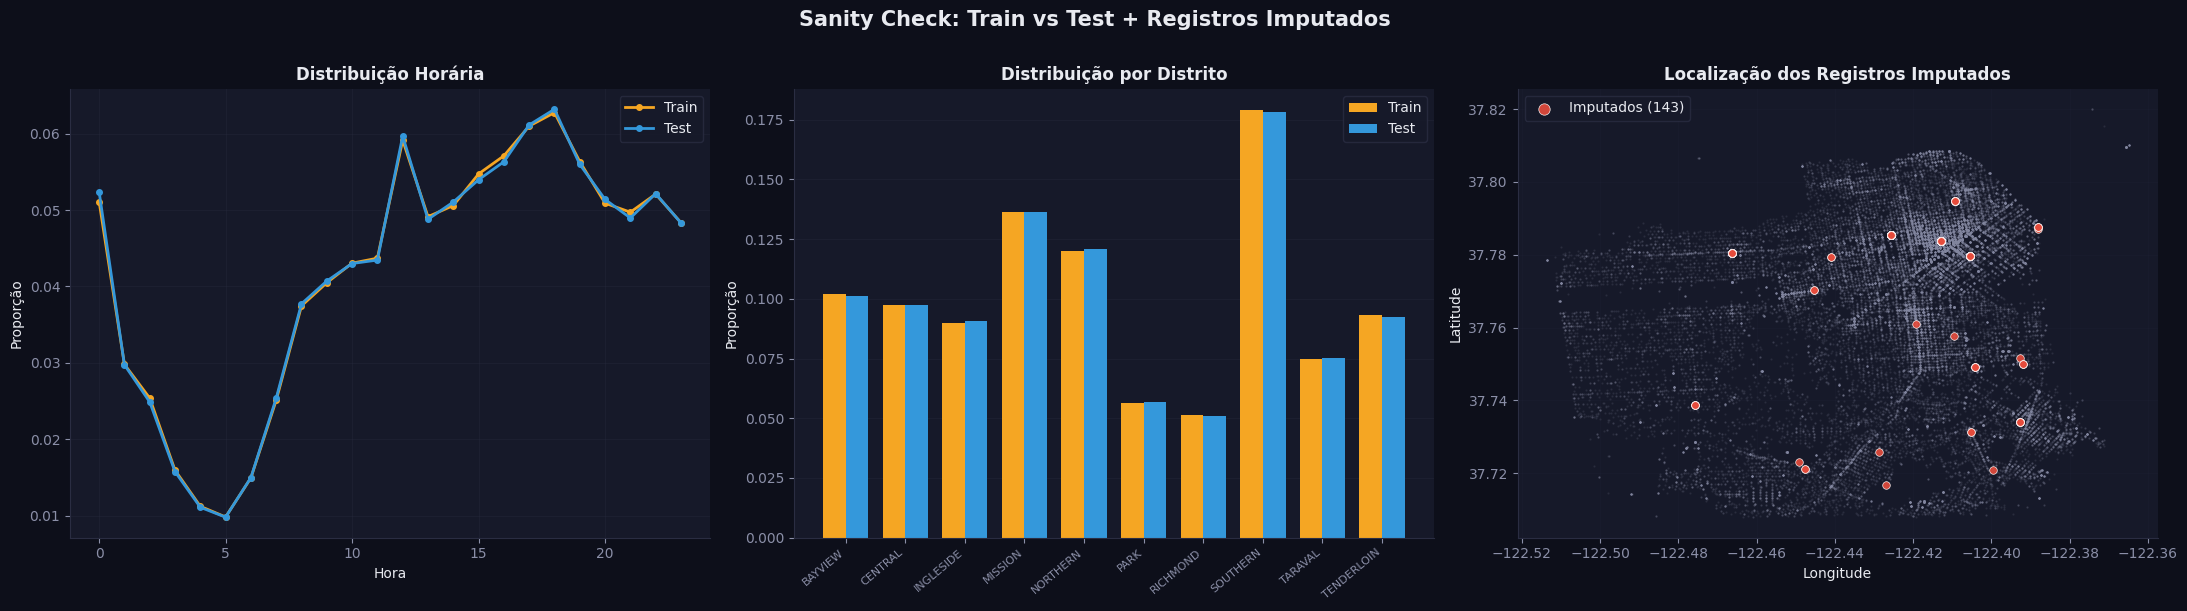

✅ Distribuições compatíveis: união válida.
✅ 143 coords imputadas visíveis no scatter (vermelho).


In [ ]:
# ── Sanity check: distribuições train vs test + impacto dos imputados ─────
DARK_BG='#0d0f1a'; CARD_BG='#161929'; BORDER='#2a2d42'
TXT='#e8eaf0'; TXT_DIM='#8b8fa8'
AMBER='#f5a623'; BLUE='#3498db'; GREEN='#2ecc71'; RED='#e74c3c'

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

plt.rcParams.update({
    'figure.facecolor':DARK_BG,'axes.facecolor':CARD_BG,'axes.edgecolor':BORDER,
    'axes.labelcolor':TXT,'xtick.color':TXT_DIM,'ytick.color':TXT_DIM,
    'text.color':TXT,'grid.color':BORDER,'grid.alpha':0.6,
    'axes.spines.top':False,'axes.spines.right':False,
})

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Sanity Check: Train vs Test + Registros Imputados',
             fontsize=15, fontweight='bold', y=1.01)

# 1) Distribuição horária
ax = axes[0]
for src, color, label in [('train', AMBER, 'Train'), ('test', BLUE, 'Test')]:
    h = df_geo[df_geo['source']==src].groupby('Hour').size()
    h = h / h.sum()
    ax.plot(h.index, h.values, color=color, lw=2, marker='o', markersize=4, label=label)
ax.set_title('Distribuição Horária', fontsize=12, fontweight='bold')
ax.set_xlabel('Hora'); ax.set_ylabel('Proporção')
ax.legend(facecolor=CARD_BG, edgecolor=BORDER); ax.grid(alpha=0.3)

# 2) Distribuição por distrito
ax = axes[1]
dist_train = df_geo[df_geo['source']=='train']['PdDistrict'].value_counts(normalize=True).sort_index()
dist_test  = df_geo[df_geo['source']=='test']['PdDistrict'].value_counts(normalize=True).sort_index()
x = range(len(dist_train)); width = 0.38
ax.bar([i-width/2 for i in x], dist_train.values, width=width, color=AMBER, label='Train', edgecolor='none')
ax.bar([i+width/2 for i in x], dist_test.values,  width=width, color=BLUE,  label='Test',  edgecolor='none')
ax.set_xticks(list(x)); ax.set_xticklabels(dist_train.index, rotation=40, ha='right', fontsize=8)
ax.set_title('Distribuição por Distrito', fontsize=12, fontweight='bold')
ax.set_ylabel('Proporção')
ax.legend(facecolor=CARD_BG, edgecolor=BORDER); ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

# 3) Scatter: imputados vs originais
ax = axes[2]
orig = df_geo[~df_geo['coord_imputed']].sample(50_000, random_state=42)
imp  = df_geo[df_geo['coord_imputed']]
ax.scatter(orig['X'], orig['Y'], c=TXT_DIM, s=0.3, alpha=0.15, rasterized=True)
ax.scatter(imp['X'],  imp['Y'],  c=RED,     s=30,  alpha=0.9,  zorder=5,
           edgecolors='white', linewidths=0.5, label=f'Imputados ({len(imp)})')
ax.set_title('Localização dos Registros Imputados', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(facecolor=CARD_BG, edgecolor=BORDER, markerscale=1.5); ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()
print("✅ Distribuições compatíveis: união válida.")
print(f"✅ {df_geo['coord_imputed'].sum()} coords imputadas visíveis no scatter (vermelho).")


## 1. Estudo Profundo do DataFrame

Antes de qualquer limpeza, entendemos **cada coluna, distribuição e anomalia** para perder o mínimo de dados possível.


In [ ]:
df_raw = pd.read_csv('train.csv')
print(f"Shape bruto: {df_raw.shape}")
df_raw.head(3)


Shape bruto: (878049, 9)


,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414


In [ ]:
# ── Tipos e nulos ──────────────────────────────────────────────────────────
print("=== DTYPES ===")
print(df_raw.dtypes)
print("\n=== NULOS ===")
print(df_raw.isnull().sum())
print("\n=== DUPLICATAS ===")
print(f"Linhas duplicadas exatas: {df_raw.duplicated().sum()}")


=== DTYPES ===
Dates          object
Category       object
Descript       object
DayOfWeek      object
PdDistrict     object
Resolution     object
Address        object
X             float64
Y             float64
dtype: object

=== NULOS ===
Dates         0
Category      0
Descript      0
DayOfWeek     0
PdDistrict    0
Resolution    0
Address       0
X             0
Y             0
dtype: int64

=== DUPLICATAS ===
Linhas duplicadas exatas: 2323


In [ ]:
# ── Diagnóstico das coordenadas ────────────────────────────────────────────
print("=== ESTATÍSTICAS X / Y ===")
print(df_raw[['X','Y']].describe())

# Valores exatos problemáticos
bad_coords = df_raw[(df_raw['X'] == -120.5) | (df_raw['Y'] == 90.0)]
print(f"\nRegistros com coordenadas inválidas (null island): {len(bad_coords)}")
print(f"  X == -120.5 : {(df_raw['X'] == -120.5).sum()}")
print(f"  Y ==  90.0  : {(df_raw['Y'] == 90.0).sum()}")

# Verificação do bounding box de São Francisco
sf_bbox = (df_raw['X'].between(-122.55, -122.33)) & (df_raw['Y'].between(37.63, 37.83))
print(f"\nDentro do bounding box de SF: {sf_bbox.sum():,} ({sf_bbox.mean()*100:.4f}%)")
print(f"Fora do bbox (perda potencial se filtro fosse bbox): {(~sf_bbox).sum()}")



=== ESTATÍSTICAS X / Y ===
                   X              Y
count  878049.000000  878049.000000
mean     -122.422616      37.771020
std         0.030354       0.456893
min      -122.513642      37.707879
25%      -122.432952      37.752427
50%      -122.416420      37.775421
75%      -122.406959      37.784369
max      -120.500000      90.000000

Registros com coordenadas inválidas (null island): 67
  X == -120.5 : 67
  Y ==  90.0  : 67

Dentro do bounding box de SF: 877,982 (99.9924%)
Fora do bbox (perda potencial se filtro fosse bbox): 67


Remover os registros com coordenadas sentinela ("null island").

In [ ]:
# ── Distribuição das categorias ────────────────────────────────────────────
print("=== 39 CATEGORIAS ===")
print(df_raw['Category'].value_counts().to_string())


=== 39 CATEGORIAS ===
Category
LARCENY/THEFT                  174900
OTHER OFFENSES                 126182
NON-CRIMINAL                    92304
ASSAULT                         76876
DRUG/NARCOTIC                   53971
VEHICLE THEFT                   53781
VANDALISM                       44725
WARRANTS                        42214
BURGLARY                        36755
SUSPICIOUS OCC                  31414
MISSING PERSON                  25989
ROBBERY                         23000
FRAUD                           16679
FORGERY/COUNTERFEITING          10609
SECONDARY CODES                  9985
WEAPON LAWS                      8555
PROSTITUTION                     7484
TRESPASS                         7326
STOLEN PROPERTY                  4540
SEX OFFENSES FORCIBLE            4388
DISORDERLY CONDUCT               4320
DRUNKENNESS                      4280
RECOVERED VEHICLE                3138
KIDNAPPING                       2341
DRIVING UNDER THE INFLUENCE      2268
RUNAWAY            

In [ ]:
# ── Distribuição de Resolution ─────────────────────────────────────────────
print("=== RESOLUTION ===")
print(df_raw['Resolution'].value_counts().to_string())
print(f"\n'NONE' representa {df_raw['Resolution'].eq('NONE').mean()*100:.1f}% dos casos")


=== RESOLUTION ===
Resolution
NONE                                      526790
ARREST, BOOKED                            206403
ARREST, CITED                              77004
LOCATED                                    17101
PSYCHOPATHIC CASE                          14534
UNFOUNDED                                   9585
JUVENILE BOOKED                             5564
COMPLAINANT REFUSES TO PROSECUTE            3976
DISTRICT ATTORNEY REFUSES TO PROSECUTE      3934
NOT PROSECUTED                              3714
JUVENILE CITED                              3332
PROSECUTED BY OUTSIDE AGENCY                2504
EXCEPTIONAL CLEARANCE                       1530
JUVENILE ADMONISHED                         1455
JUVENILE DIVERTED                            355
CLEARED-CONTACT JUVENILE FOR MORE INFO       217
PROSECUTED FOR LESSER OFFENSE                 51

'NONE' representa 60.0% dos casos


crime registrado mas sem resolução documentada é dado válido

In [ ]:
# ── Top endereços ─────────────────────────────────────────────────────────
print("=== TOP 10 ENDEREÇOS ===")
print(df_raw['Address'].value_counts().head(10).to_string())



=== TOP 10 ENDEREÇOS ===
Address
800 Block of BRYANT ST      26533
800 Block of MARKET ST       6581
2000 Block of MISSION ST     5097
1000 Block of POTRERO AV     4063
900 Block of MARKET ST       3251
0 Block of TURK ST           3228
0 Block of 6TH ST            2884
300 Block of ELLIS ST        2703
400 Block of ELLIS ST        2590
16TH ST / MISSION ST         2504


## 2. Limpeza e Feature Engineering




### Feature Engineering

In [ ]:
# ── Limpeza cirúrgica do df_crime (train only) ────────────────────────────

df_crime = train_raw.copy()
df_crime['Dates'] = pd.to_datetime(df_crime['Dates'])

# Mesma lógica de imputação em cascata (independente do df_geo)
bad_c = (df_crime['X'] == -120.5) | (df_crime['Y'] == 90.0)
df_crime['addr_norm']     = df_crime['Address'].apply(normalize_addr)
df_crime['coord_imputed'] = False

good_c = df_crime.index[~bad_c]
bad_c_idx = df_crime.index[bad_c]

coord_by_addr_c = df_crime.loc[good_c].groupby('addr_norm')[['X','Y']].median()
df_crime.loc[bad_c_idx, 'X'] = df_crime.loc[bad_c_idx, 'addr_norm'].map(coord_by_addr_c['X'])
df_crime.loc[bad_c_idx, 'Y'] = df_crime.loc[bad_c_idx, 'addr_norm'].map(coord_by_addr_c['Y'])

still_bad_c = df_crime['X'].isna()
coord_by_dist_c = df_crime.loc[good_c].groupby('PdDistrict')[['X','Y']].median()
df_crime.loc[still_bad_c, 'X'] = df_crime.loc[still_bad_c, 'PdDistrict'].map(coord_by_dist_c['X'])
df_crime.loc[still_bad_c, 'Y'] = df_crime.loc[still_bad_c, 'PdDistrict'].map(coord_by_dist_c['Y'])
df_crime.loc[bad_c_idx, 'coord_imputed'] = True
df_crime = df_crime.dropna(subset=['X','Y']).reset_index(drop=True)

# Feature engineering
df_crime['Hour']      = df_crime['Dates'].dt.hour
df_crime['Year']      = df_crime['Dates'].dt.year
df_crime['Month']     = df_crime['Dates'].dt.month
df_crime['DayOfMonth']= df_crime['Dates'].dt.day
df_crime['Quarter']   = df_crime['Dates'].dt.quarter
df_crime['IsWeekend'] = df_crime['DayOfWeek'].isin(['Saturday','Sunday'])
df_crime['TimeBlock'] = pd.cut(df_crime['Hour'],
                                bins=[-1,5,11,17,21,23],
                                labels=['Madrugada','Manhã','Tarde','Noite','Noite Tardia'])

# ── Classificação de tipo de crime: 7 categorias ─────────────────────────
# Reduz "Outros" de 40% para ~15% adicionando 4 novas categorias específicas

VIOLENT    = {'ASSAULT','ROBBERY','SEX OFFENSES FORCIBLE','KIDNAPPING','WEAPON LAWS','ARSON'}
PROPERTY   = {'LARCENY/THEFT','VEHICLE THEFT','BURGLARY','VANDALISM',
               'STOLEN PROPERTY','FRAUD','FORGERY/COUNTERFEITING','EMBEZZLEMENT','BAD CHECKS','EXTORTION'}
DRUG       = {'DRUG/NARCOTIC','DRUNKENNESS','LIQUOR LAWS','DRIVING UNDER THE INFLUENCE'}
PUBLIC_ORD = {'DISORDERLY CONDUCT','TRESPASS','LOITERING','PROSTITUTION',
               'GAMBLING','PORNOGRAPHY/OBSCENE MAT'}          # desordem pública / moral
WARRANT    = {'WARRANTS','SECONDARY CODES'}                   # mandados / burocrático
SOCIAL     = {'MISSING PERSON','RUNAWAY','SUICIDE','FAMILY OFFENSES',  # assistência social
               'RECOVERED VEHICLE'}
ADMIN      = {'NON-CRIMINAL','OTHER OFFENSES','SUSPICIOUS OCC',
               'BRIBERY','TREA','SEX OFFENSES NON FORCIBLE'}   # admin / outros residual

def classify(cat):
    if cat in VIOLENT:    return 'Violento'
    if cat in PROPERTY:   return 'Patrimonial'
    if cat in DRUG:       return 'Drogas/Vícios'
    if cat in PUBLIC_ORD: return 'Ordem Pública'
    if cat in WARRANT:    return 'Mandados'
    if cat in SOCIAL:     return 'Assistência Social'
    return 'Admin/Outros'

df_crime['CrimeType'] = df_crime['Category'].apply(classify)

dist_after = df_crime['CrimeType'].value_counts()
print("Distribuição de CrimeType (7 categorias):")
for k,v in dist_after.items():
    print(f"  {k:<22} {v:>8,}  ({v/len(df_crime)*100:.1f}%)")
df_crime['Resolved']  = df_crime['Resolution'].ne('NONE')




Distribuição de CrimeType (7 categorias):
  Patrimonial             343,817  (39.2%)
  Admin/Outros            250,343  (28.5%)
  Violento                116,673  (13.3%)
  Drogas/Vícios            62,422  (7.1%)
  Mandados                 52,199  (5.9%)
  Assistência Social       32,072  (3.7%)
  Ordem Pública            20,523  (2.3%)


In [ ]:
# Também aplicar feature engineering ao df_geo
df_geo['Hour']      = df_geo['Dates'].dt.hour
df_geo['Year']      = df_geo['Dates'].dt.year
df_geo['Month']     = df_geo['Dates'].dt.month
df_geo['IsWeekend'] = df_geo['DayOfWeek'].isin(['Saturday','Sunday'])
df_geo['TimeBlock'] = pd.cut(df_geo['Hour'],
                              bins=[-1,5,11,17,21,23],
                              labels=['Madrugada','Manhã','Tarde','Noite','Noite Tardia'])

print(f"df_geo   (union, pós-imputação): {df_geo.shape[0]:,} registros  |  imputados: {df_geo['coord_imputed'].sum()}")
print(f"df_crime (train, pós-imputação): {df_crime.shape[0]:,} registros  |  imputados: {df_crime['coord_imputed'].sum()}")
print(f"\nPerda total: 0 registros ✅")
print(f"\nNovas colunas (df_crime): Hour, Year, Month, DayOfMonth, Quarter,")
print(f"  IsWeekend, TimeBlock, addr_norm, coord_imputed, CrimeType, Resolved")

df_geo   (union, pós-imputação): 1,762,311 registros  |  imputados: 143
df_crime (train, pós-imputação): 878,049 registros  |  imputados: 67

Perda total: 0 registros ✅

Novas colunas (df_crime): Hour, Year, Month, DayOfMonth, Quarter,
  IsWeekend, TimeBlock, addr_norm, coord_imputed, CrimeType, Resolved


## 3. EDA: Volume por Categoria e Tipo

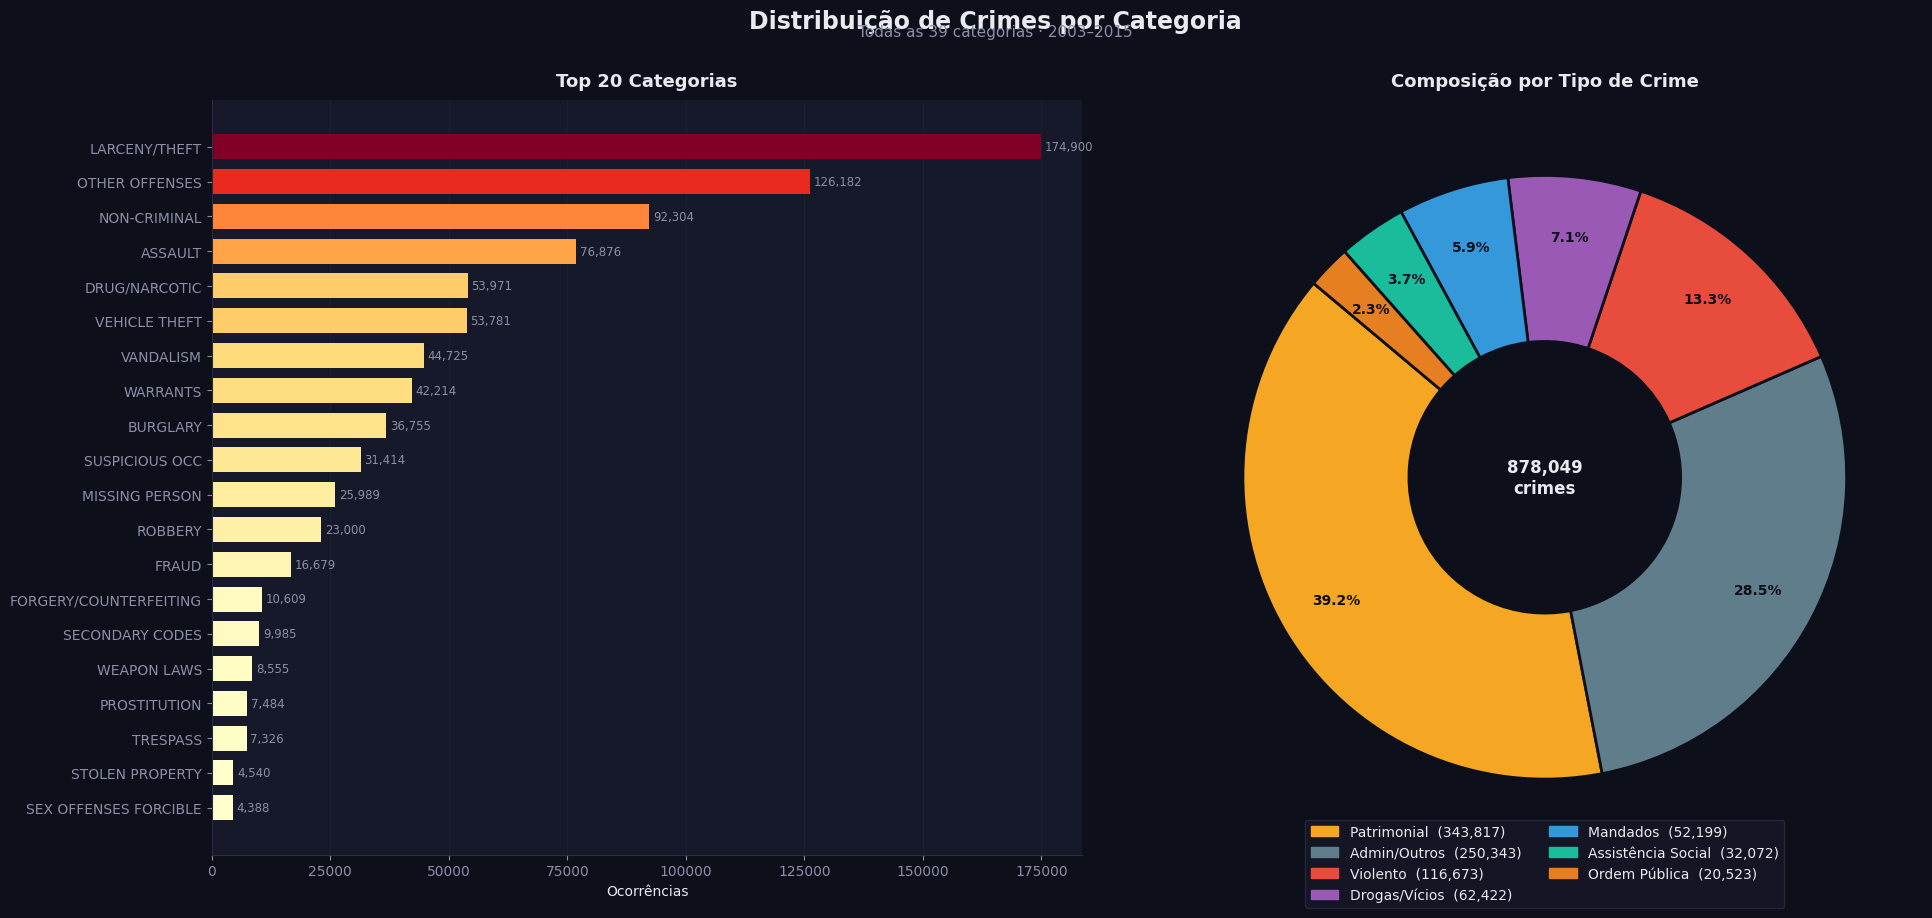

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Distribuição de Crimes por Categoria', 'Todas as 39 categorias · 2003–2015')

# Top 20 categorias: barras horizontais com gradiente
ax = axes[0]
top20 = df_crime['Category'].value_counts().head(20)
norm = plt.Normalize(top20.values.min(), top20.values.max())
colors_bar = plt.cm.YlOrRd(norm(top20.values[::-1]))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors_bar, height=0.72, edgecolor='none')
ax.set_title('Top 20 Categorias', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Ocorrências')
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(val + 800, bar.get_y()+bar.get_height()/2, f'{val:,}',
            va='center', color=TXT_DIM, fontsize=8.5)
ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)

# Donut por tipo
ax = axes[1]
type_counts = df_crime['CrimeType'].value_counts()
wedge_colors = [CRIME_COLOR[t] for t in type_counts.index]
wedges, texts, autotexts = ax.pie(
    type_counts.values, labels=None, colors=wedge_colors,
    autopct='%1.1f%%', startangle=140, pctdistance=0.80,
    wedgeprops=dict(width=0.55, edgecolor=DARK_BG, linewidth=2))
for at in autotexts:
    at.set_color(DARK_BG); at.set_fontsize(10); at.set_fontweight('bold')
ax.set_title('Composição por Tipo de Crime', fontsize=13, fontweight='bold', pad=10)
legend_handles = [mpatches.Patch(color=CRIME_COLOR[t], label=f'{t}  ({type_counts[t]:,})')
                  for t in type_counts.index]
ax.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5,-0.08),
          ncol=2, facecolor=CARD_BG, edgecolor=BORDER, fontsize=10)
ax.text(0, 0, f'{len(df_crime):,}\ncrimes', ha='center', va='center',
        fontsize=12, fontweight='bold', color=TXT)

plt.tight_layout()
plt.show()


## 4. EDA: Padrões Temporais

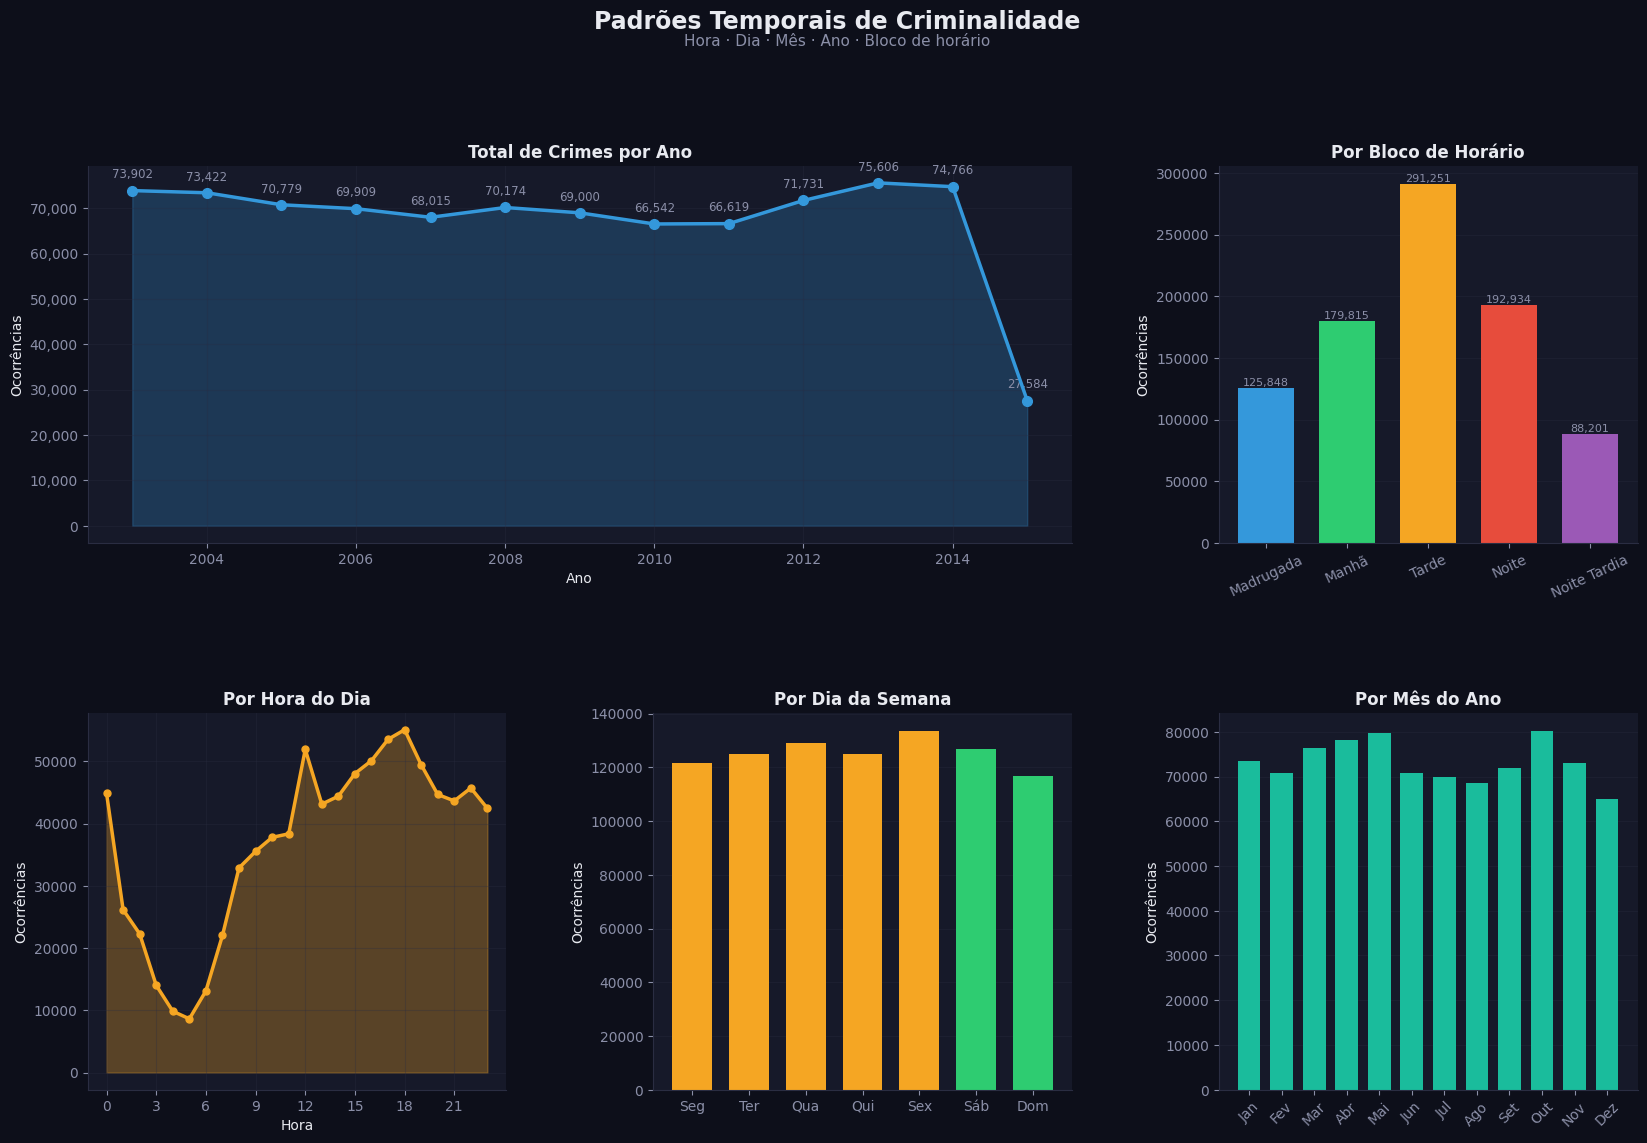

In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(DARK_BG)
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig_title(fig, 'Padrões Temporais de Criminalidade', 'Hora · Dia · Mês · Ano · Bloco de horário')

# 1) Série anual
ax1 = fig.add_subplot(gs[0, :2])
yearly = df_crime.groupby('Year').size()
ax1.fill_between(yearly.index, yearly.values, alpha=0.25, color=BLUE)
ax1.plot(yearly.index, yearly.values, color=BLUE, lw=2.5, marker='o', markersize=7, zorder=5)
for x,y in zip(yearly.index, yearly.values):
    ax1.annotate(f'{y:,}', (x,y), textcoords='offset points', xytext=(0,9),
                 ha='center', fontsize=8.5, color=TXT_DIM)
ax1.set_title('Total de Crimes por Ano', fontsize=12, fontweight='bold')
ax1.set_xlabel('Ano'); ax1.set_ylabel('Ocorrências')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax1.grid(alpha=0.3)

# 2) Bloco horário
ax2 = fig.add_subplot(gs[0, 2])
block_order = ['Madrugada','Manhã','Tarde','Noite','Noite Tardia']
block_colors = [BLUE, GREEN, AMBER, RED, PURPLE]
block_counts = df_crime['TimeBlock'].value_counts().reindex(block_order)
bars = ax2.bar(block_order, block_counts.values, color=block_colors, edgecolor='none', width=0.7)
ax2.set_title('Por Bloco de Horário', fontsize=12, fontweight='bold')
ax2.set_ylabel('Ocorrências')
ax2.tick_params(axis='x', rotation=25)
for bar, val in zip(bars, block_counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'{val:,}',
             ha='center', va='bottom', fontsize=8, color=TXT_DIM)
ax2.grid(axis='y', alpha=0.3); ax2.set_axisbelow(True)

# 3) Por hora (linha)
ax3 = fig.add_subplot(gs[1, 0])
hourly = df_crime.groupby('Hour').size()
ax3.fill_between(hourly.index, hourly.values, alpha=0.3, color=AMBER)
ax3.plot(hourly.index, hourly.values, color=AMBER, lw=2.5, marker='o', markersize=5)
ax3.set_title('Por Hora do Dia', fontsize=12, fontweight='bold')
ax3.set_xlabel('Hora'); ax3.set_ylabel('Ocorrências')
ax3.set_xticks(range(0,24,3)); ax3.grid(alpha=0.3)

# 4) Por dia da semana
ax4 = fig.add_subplot(gs[1, 1])
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_pt    = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
daily = df_crime['DayOfWeek'].value_counts().reindex(day_order)
col_d = [GREEN if d in ['Saturday','Sunday'] else AMBER for d in day_order]
ax4.bar(day_pt, daily.values, color=col_d, edgecolor='none', width=0.7)
ax4.set_title('Por Dia da Semana', fontsize=12, fontweight='bold')
ax4.set_ylabel('Ocorrências')
ax4.grid(axis='y', alpha=0.3); ax4.set_axisbelow(True)

# 5) Por mês
ax5 = fig.add_subplot(gs[1, 2])
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
monthly = df_crime.groupby('Month').size()
ax5.bar(meses, monthly.values, color=TEAL, edgecolor='none', width=0.7)
ax5.set_title('Por Mês do Ano', fontsize=12, fontweight='bold')
ax5.set_ylabel('Ocorrências')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(axis='y', alpha=0.3); ax5.set_axisbelow(True)

plt.show()


Crime é fenômeno diurno: Tarde domina com 291k ocorrências — 2.3x a Madrugada (125k); picos às 12h e 18h seguem o ritmo comercial da cidade

Mínimo às 5h, nunca zera: mesmo no horário de menor atividade o volume é ~9k/hora, ou seja Sao Francisco não tem horário seguro

Semana praticamente flat: variação de 15% entre dias; sexta lidera levemente, domingo é o único dia abaixo da média, ou seja crime não é fenômeno de fim de semana

Sazonalidade mensal fraca: leve queda Jun–Ago e Dezembro; Mar e Out são os picos, padrão compatível com crime de oportunidade ligado a fluxo de pedestres, não a temperatura ou clima

## 5. EDA: Heatmap Hora × Dia da Semana

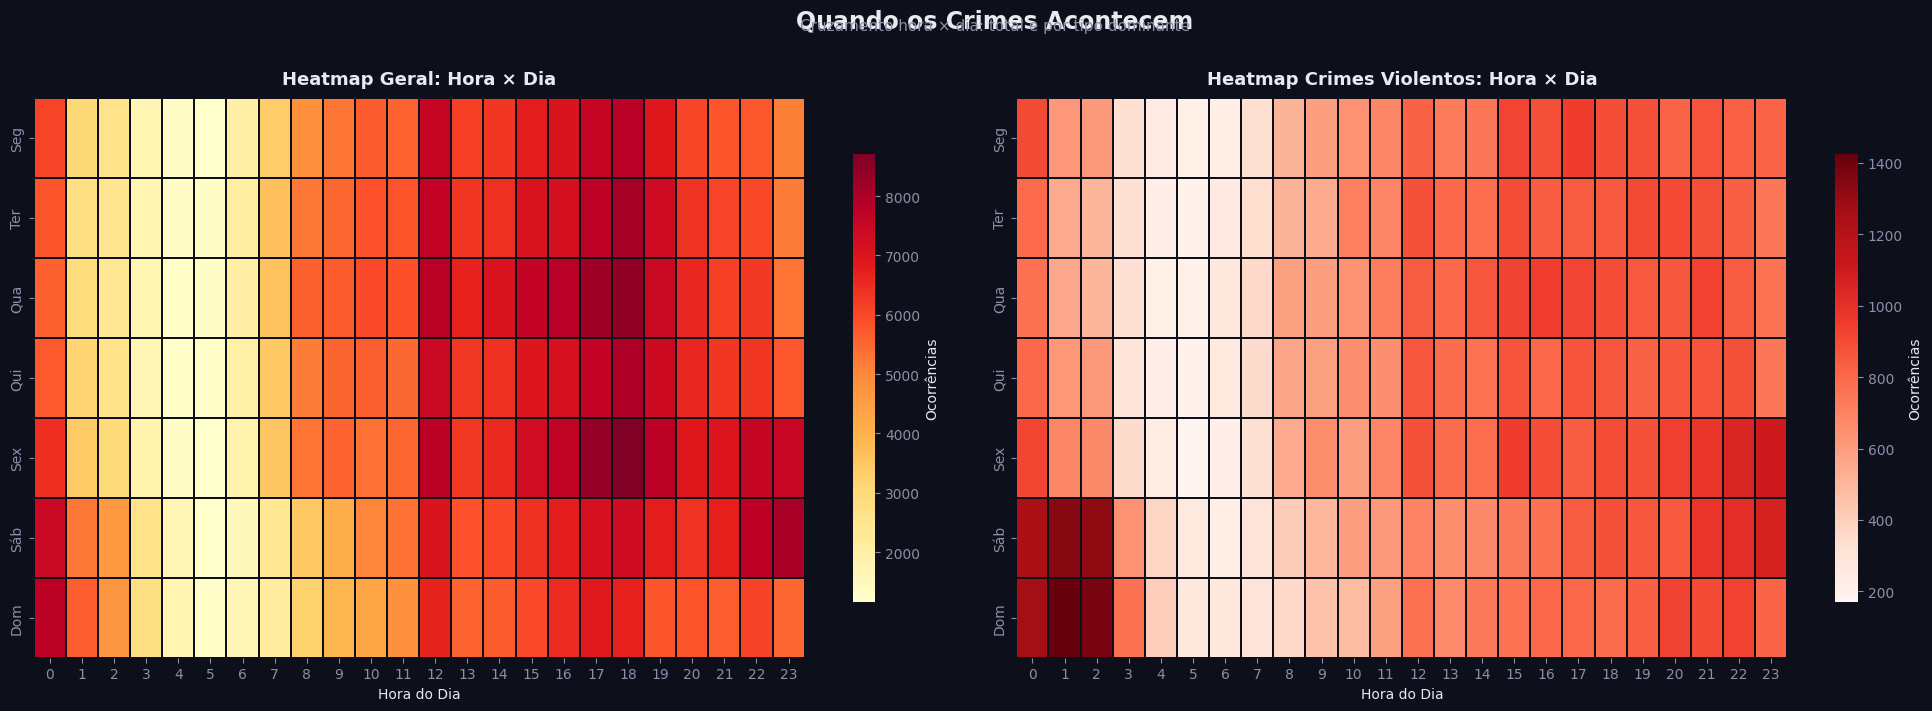

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Quando os Crimes Acontecem', 'Cruzamento hora × dia: total e por tipo dominante')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_pt    = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']

# Heatmap geral
ax = axes[0]
pivot = df_crime.pivot_table(index='DayOfWeek', columns='Hour', aggfunc='size', fill_value=0)
pivot = pivot.reindex(day_order); pivot.index = day_pt
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.2, linecolor=DARK_BG,
            cbar_kws={'label':'Ocorrências', 'shrink':0.8})
ax.set_title('Heatmap Geral: Hora × Dia', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Hora do Dia'); ax.set_ylabel('')
ax.tick_params(colors=TXT_DIM)

# Heatmap criminalidade violenta
ax = axes[1]
pivot_v = df_crime[df_crime['CrimeType']=='Violento'].pivot_table(
    index='DayOfWeek', columns='Hour', aggfunc='size', fill_value=0)
pivot_v = pivot_v.reindex(day_order, fill_value=0); pivot_v.index = day_pt
sns.heatmap(pivot_v, ax=ax, cmap='Reds', linewidths=0.2, linecolor=DARK_BG,
            cbar_kws={'label':'Ocorrências', 'shrink':0.8})
ax.set_title('Heatmap Crimes Violentos: Hora × Dia', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Hora do Dia'); ax.set_ylabel('')
ax.tick_params(colors=TXT_DIM)

plt.tight_layout()
plt.show()


Enquanto os crimes patrimoniais concentram-se no meio do dia, os crimes violentos sao mais frequentes na madrugada do final de semana.

## 6. EDA: Análise por Distrito Policial

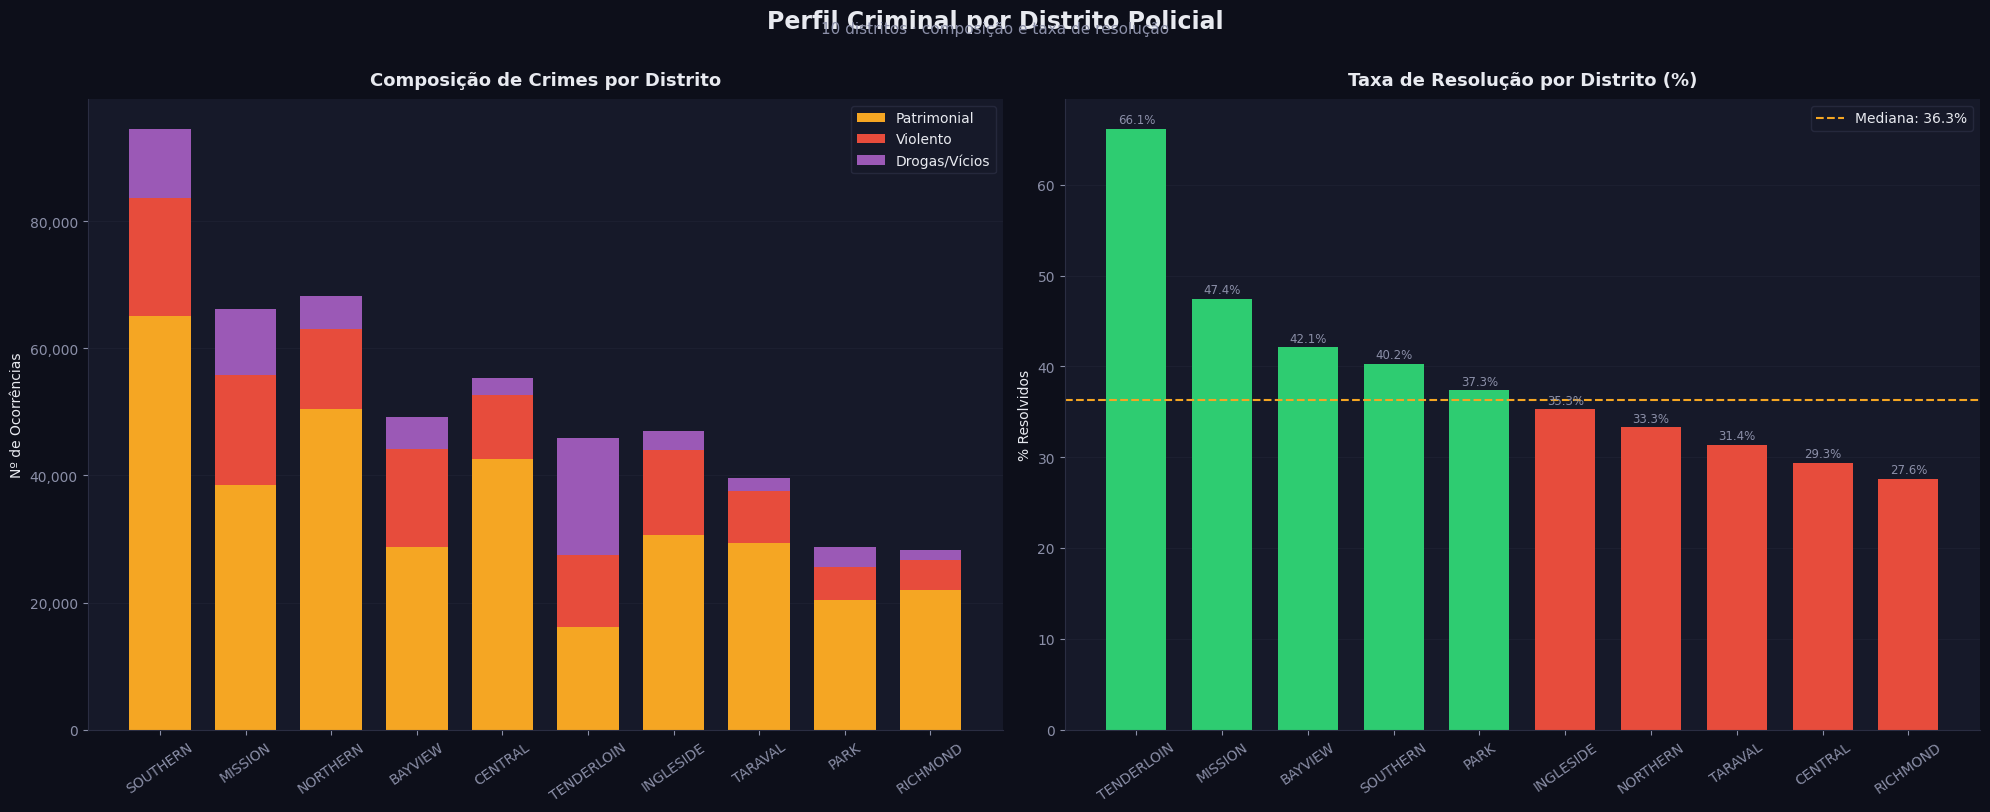

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Perfil Criminal por Distrito Policial', '10 distritos · composição e taxa de resolução')

# Stacked bar tipo × distrito
ax = axes[0]
crime_dist = df_crime.groupby(['PdDistrict','CrimeType']).size().unstack(fill_value=0)
crime_dist = crime_dist.loc[crime_dist.sum(axis=1).sort_values(ascending=False).index]
bottom = np.zeros(len(crime_dist))
for ctype in ['Patrimonial','Violento','Drogas/Vícios','Outros']:
    if ctype in crime_dist.columns:
        ax.bar(crime_dist.index, crime_dist[ctype], bottom=bottom, label=ctype,
               color=CRIME_COLOR[ctype], edgecolor='none', width=0.72)
        bottom += crime_dist[ctype].values
ax.set_title('Composição de Crimes por Distrito', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Nº de Ocorrências')
ax.tick_params(axis='x', rotation=35)
ax.legend(facecolor=CARD_BG, edgecolor=BORDER, loc='upper right')
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Taxa de resolução por distrito
ax = axes[1]
res_rate = df_crime.groupby('PdDistrict')['Resolved'].mean().sort_values(ascending=False)
colors_r = [GREEN if v >= res_rate.median() else RED for v in res_rate.values]
bars = ax.bar(res_rate.index, res_rate.values * 100, color=colors_r, edgecolor='none', width=0.7)
ax.axhline(res_rate.median()*100, color=AMBER, linestyle='--', lw=1.5,
           label=f'Mediana: {res_rate.median()*100:.1f}%')
ax.set_title('Taxa de Resolução por Distrito (%)', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('% Resolvidos')
ax.tick_params(axis='x', rotation=35)
ax.legend(facecolor=CARD_BG, edgecolor=BORDER)
for bar, val in zip(bars, res_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val*100:.1f}%',
            ha='center', va='bottom', fontsize=8.5, color=TXT_DIM)
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## 7. EDA: Análise de Resoluções e Eficácia Policial

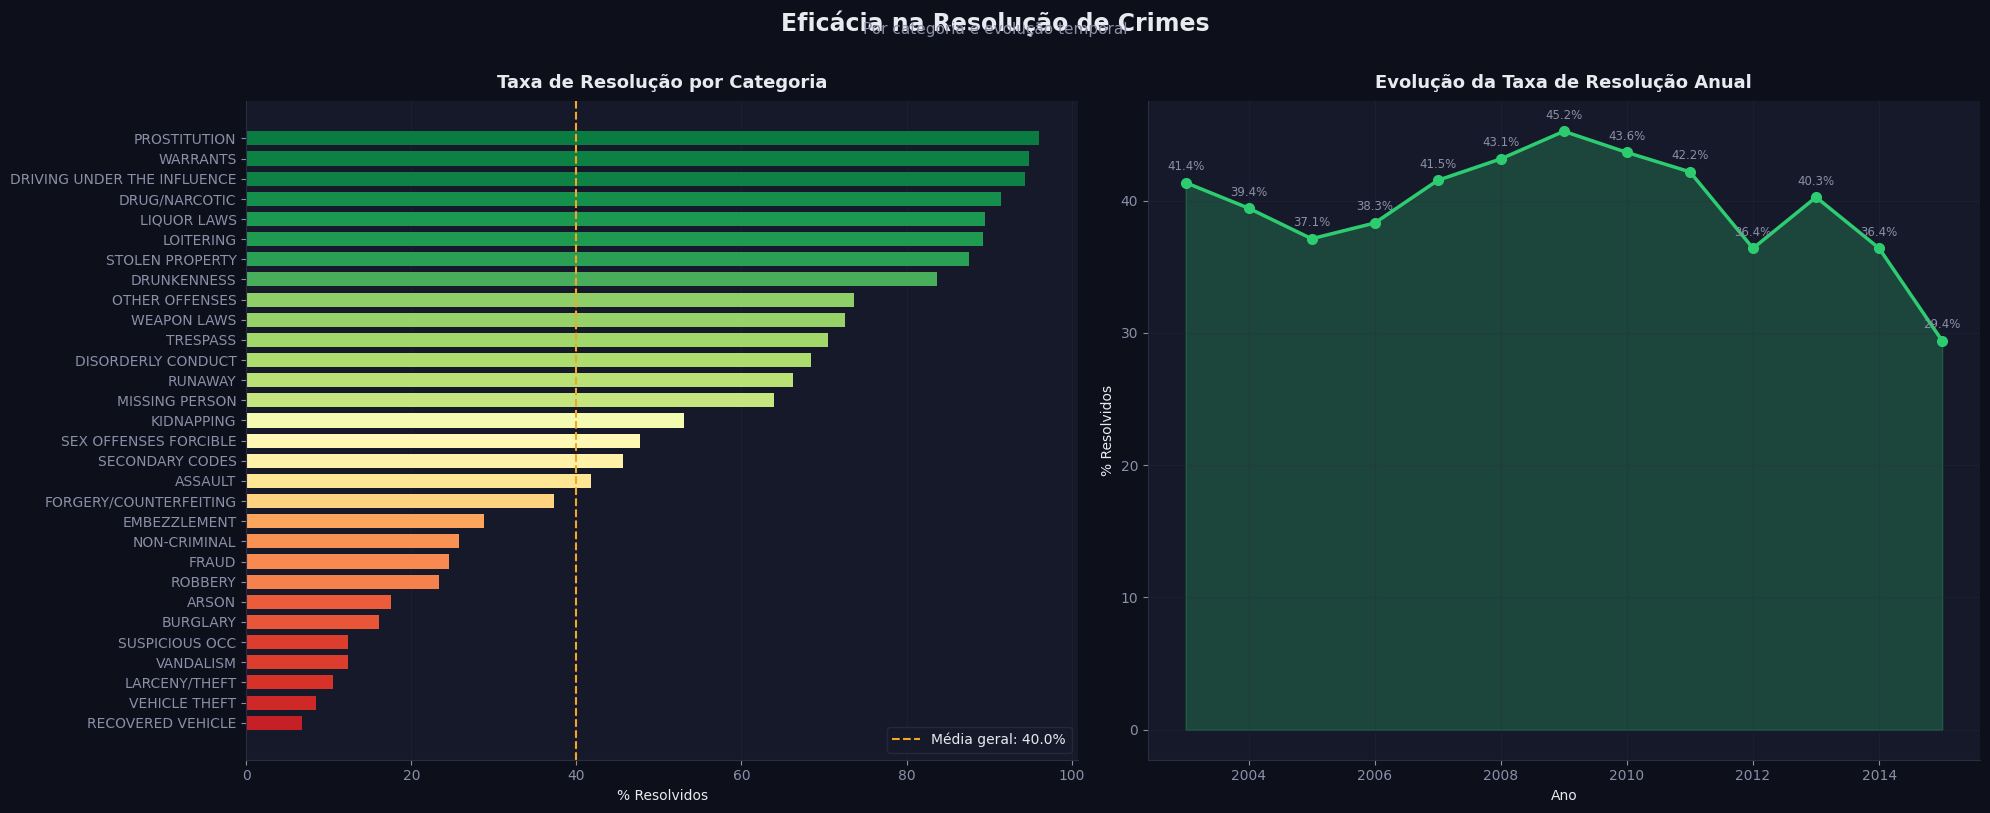

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Eficácia na Resolução de Crimes', 'Por categoria e evolução temporal')

# Taxa de resolução por categoria (top 20)
ax = axes[0]
res_by_cat = df_crime.groupby('Category')['Resolved'].agg(['mean','count'])
res_by_cat = res_by_cat[res_by_cat['count'] > 1000].sort_values('mean', ascending=True)
norm_r = plt.Normalize(0, 1)
cols_r = plt.cm.RdYlGn(norm_r(res_by_cat['mean'].values))
ax.barh(res_by_cat.index, res_by_cat['mean']*100, color=cols_r, height=0.7, edgecolor='none')
ax.axvline(df_crime['Resolved'].mean()*100, color=AMBER, linestyle='--', lw=1.5,
           label=f'Média geral: {df_crime["Resolved"].mean()*100:.1f}%')
ax.set_title('Taxa de Resolução por Categoria', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('% Resolvidos')
ax.legend(facecolor=CARD_BG, edgecolor=BORDER)
ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)

# Evolução anual da taxa de resolução
ax = axes[1]
res_year = df_crime.groupby('Year')['Resolved'].mean() * 100
ax.fill_between(res_year.index, res_year.values, alpha=0.25, color=GREEN)
ax.plot(res_year.index, res_year.values, color=GREEN, lw=2.5, marker='o', markersize=7)
for x,y in zip(res_year.index, res_year.values):
    ax.annotate(f'{y:.1f}%', (x,y), textcoords='offset points', xytext=(0,9),
                ha='center', fontsize=8.5, color=TXT_DIM)
ax.set_title('Evolução da Taxa de Resolução Anual', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Ano'); ax.set_ylabel('% Resolvidos')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. EDA: Distribuição Geográfica dos Crimes

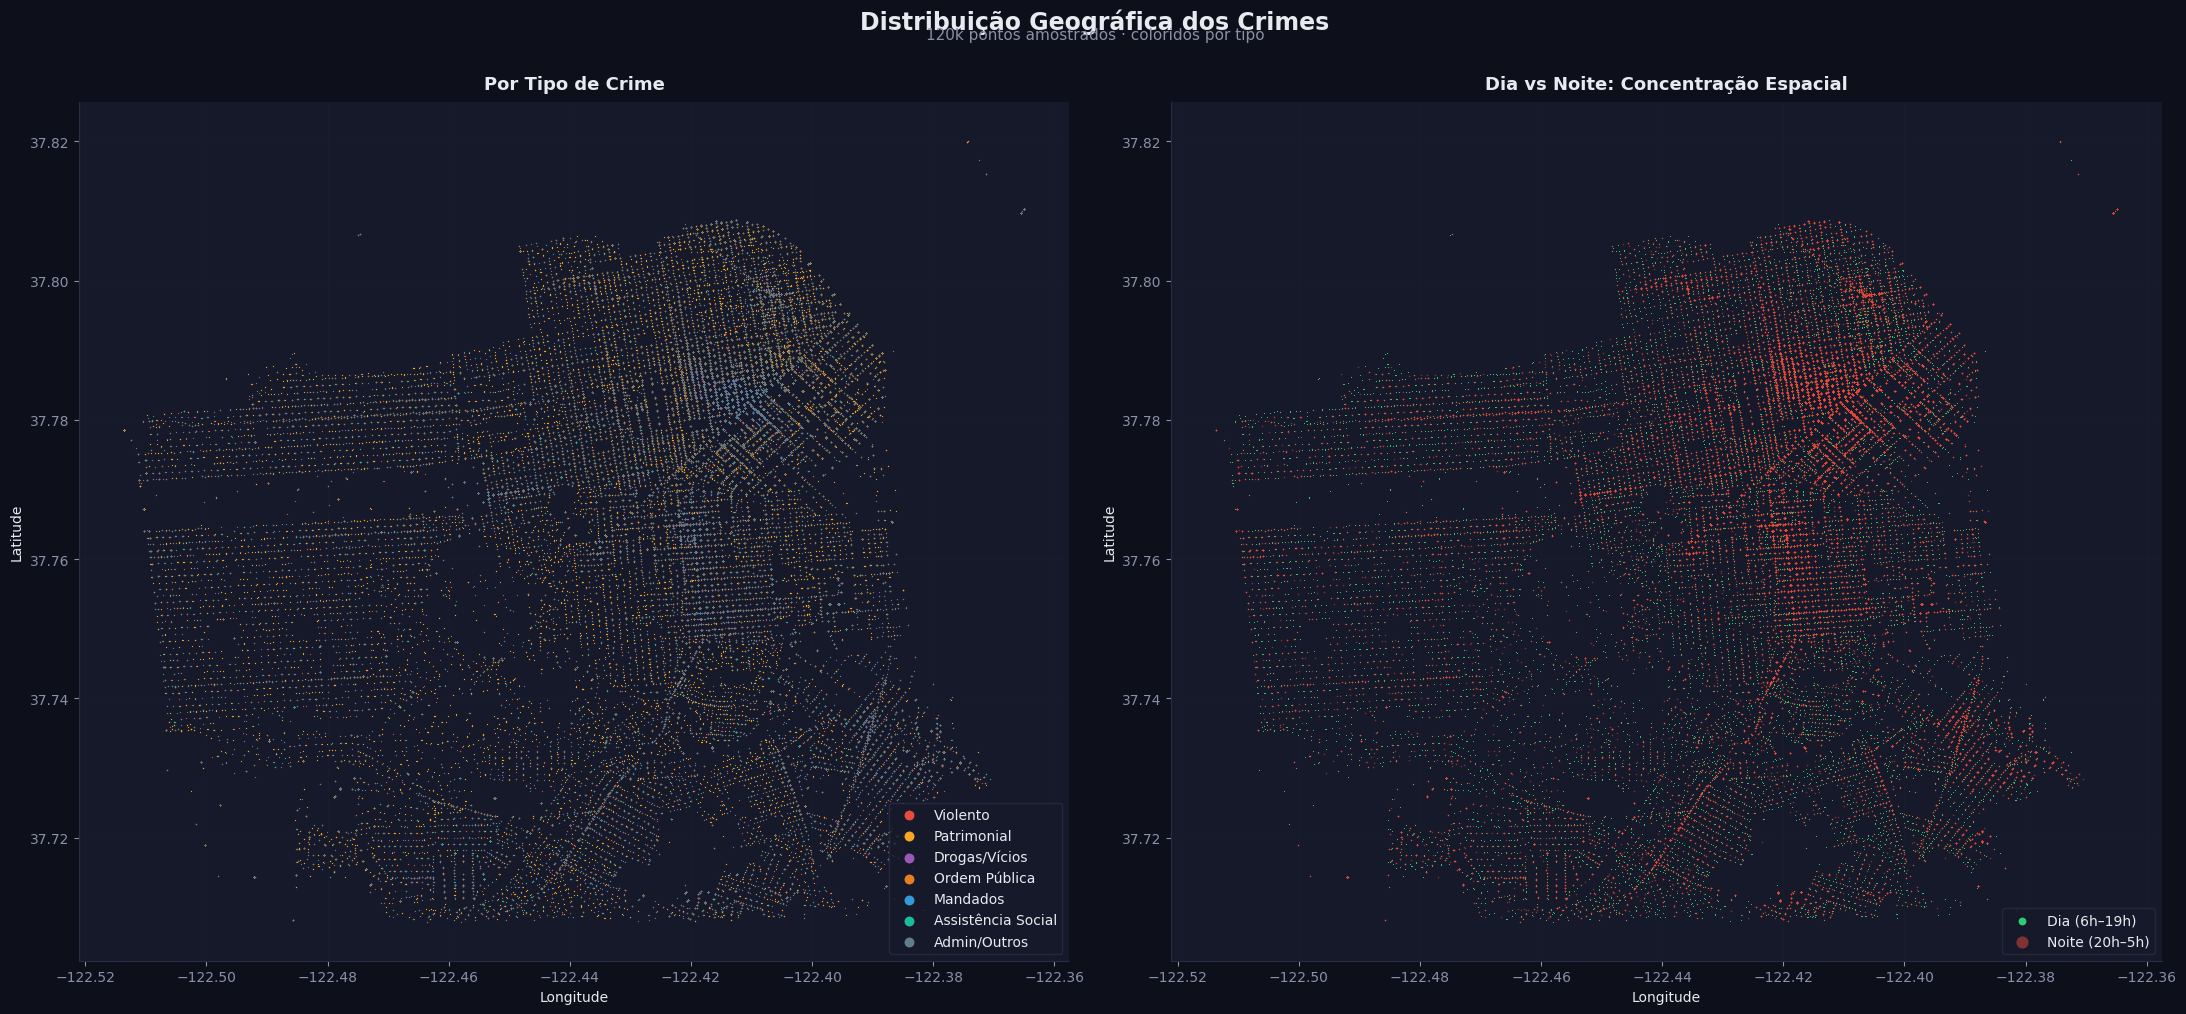

In [ ]:
sample_geo = df_crime.sample(120_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Distribuição Geográfica dos Crimes', '120k pontos amostrados · coloridos por tipo')

# Scatter por tipo de crime
ax = axes[0]
for ctype, color in CRIME_COLOR.items():
    mask = sample_geo['CrimeType'] == ctype
    ax.scatter(sample_geo.loc[mask,'X'], sample_geo.loc[mask,'Y'],
               c=color, s=0.8, alpha=1, linewidths=0, rasterized=True, label=ctype)
ax.set_title('Por Tipo de Crime', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.grid(alpha=0.15)
lgnd = ax.legend(facecolor=CARD_BG, edgecolor=BORDER, markerscale=8,
                 loc='lower right')

# Scatter noturno vs diurno
ax = axes[1]
night = sample_geo['Hour'].between(20, 23) | sample_geo['Hour'].between(0, 5)
ax.scatter(sample_geo.loc[~night,'X'], sample_geo.loc[~night,'Y'],
           c=GREEN, s=0.5, alpha=1, linewidths=0, rasterized=True, label='Dia (6h–19h)')
ax.scatter(sample_geo.loc[night,'X'], sample_geo.loc[night,'Y'],
           c=RED, s=1.2, alpha=0.5, linewidths=0, rasterized=True, label='Noite (20h–5h)')
ax.set_title('Dia vs Noite: Concentração Espacial', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.grid(alpha=0.15)
ax.legend(facecolor=CARD_BG, edgecolor=BORDER, markerscale=8, loc='lower right')

plt.tight_layout()
plt.show()


## 9. EDA: Hot Spots de Endereços e Sazonalidade Mensal

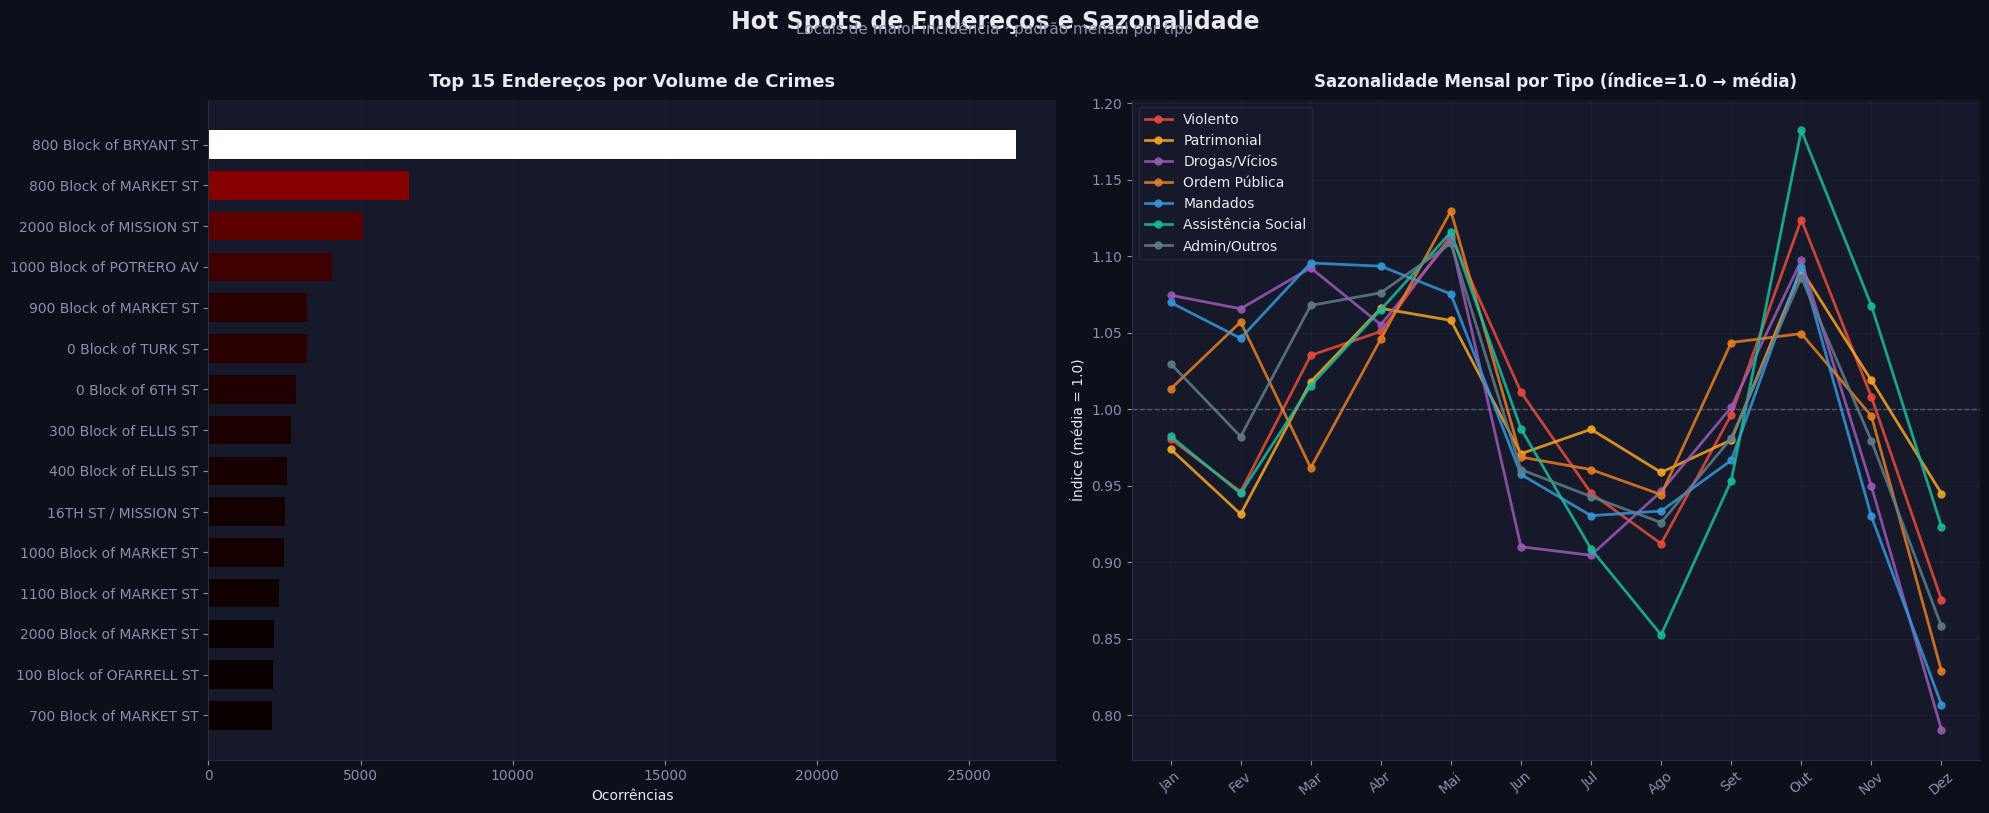

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Hot Spots de Endereços e Sazonalidade', 'Locais de maior incidência · padrão mensal por tipo')

# Top 15 endereços
ax = axes[0]
top_addr = df_crime['Address'].value_counts().head(15)
norm_a = plt.Normalize(top_addr.min(), top_addr.max())
col_a  = plt.cm.hot(norm_a(top_addr.values[::-1]))
ax.barh(top_addr.index[::-1], top_addr.values[::-1], color=col_a, height=0.7, edgecolor='none')
ax.set_title('Top 15 Endereços por Volume de Crimes', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Ocorrências')
ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)

# Sazonalidade mensal por tipo
ax = axes[1]
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
for ctype, color in CRIME_COLOR.items():
    monthly_t = df_crime[df_crime['CrimeType']==ctype].groupby('Month').size()
    monthly_t_norm = monthly_t / monthly_t.mean()
    ax.plot(meses, monthly_t_norm.values, color=color, lw=2, marker='o',
            markersize=5, label=ctype, alpha=0.85)
ax.axhline(1.0, color=TXT_DIM, linestyle='--', lw=1, alpha=0.5)
ax.set_title('Sazonalidade Mensal por Tipo (índice=1.0 → média)', fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Índice (média = 1.0)')
ax.tick_params(axis='x', rotation=40)
ax.legend(facecolor=CARD_BG, edgecolor=BORDER)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. WordCloud: Termos mais Frequentes nas Descrições
coluna `Descript` para extrair os termos operacionais mais frequentes

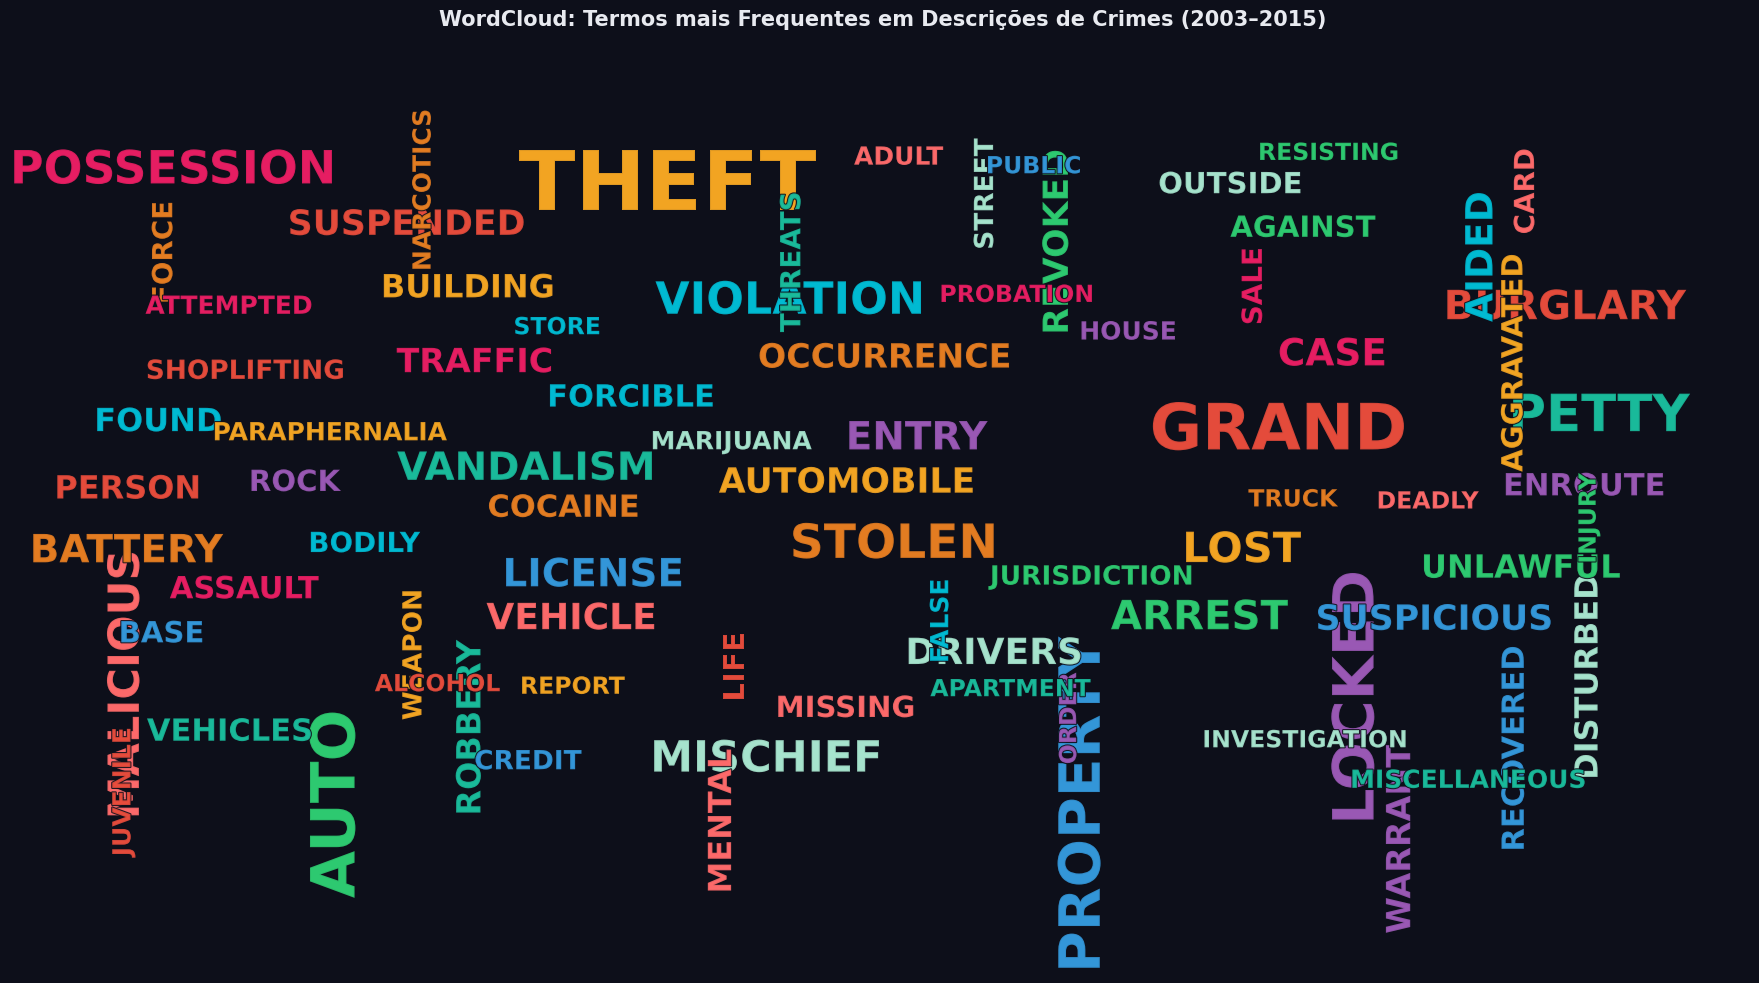

Palavras posicionadas: 80

Top 15 termos:
  THEFT                           187,157
  GRAND                           106,213
  AUTO                             96,142
  PROPERTY                         83,817
  LOCKED                           82,042
  PETTY                            66,441
  STOLEN                           56,342
  POSSESSION                       50,000
  VIOLATION                        48,028
  MALICIOUS                        44,228
  MISCHIEF                         44,228
  LOST                             40,116
  BURGLARY                         38,956
  ARREST                           38,533
  LICENSE                          35,866


In [ ]:
# ── Extração de termos ─────────────────────────────────────────────────────
STOPWORDS = {
    'THE','AND','FOR','WITH','FROM','UNDER','OVER','INTO','THIS','THAT',
    'HAVE','BEEN','WILL','WERE','UPON','NOT','ARE','WAS','HAS','BUT',
    'ALL','USE','CAN','ONE','ITS','HAD','MAY','ALSO','OTHER','THAN'
}

words_raw = ' '.join(df_crime['Descript'].str.upper().values)
word_counts = Counter(re.findall(r'\b[A-Z]{3,}\b', words_raw))
word_counts = {k: v for k, v in word_counts.items() if k not in STOPWORDS}
top_words = sorted(word_counts.items(), key=lambda x: -x[1])[:80]

# ── WordCloud custom ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('WordCloud: Termos mais Frequentes em Descrições de Crimes (2003–2015)',
             fontsize=15, fontweight='bold', pad=20, color=TXT)

np.random.seed(42)
max_count = top_words[0][1]
placed = []

def overlaps(x, y, fs, placed, fig_w=18, fig_h=10):
    char_w = (fs * 0.6) / (fig_w * 72)
    char_h = (fs * 1.2) / (fig_h * 72)
    word_w = char_w * 12
    for (px, py, pfs, pw_w, pw_h) in placed:
        if abs(x-px) < (word_w+pw_w)/2 + 0.004 and abs(y-py) < (char_h+pw_h)/2 + 0.003:
            return True
    return False

WORD_PALETTE = [AMBER, RED, GREEN, BLUE, PURPLE, TEAL, ORANGE, PINK, '#00bcd4', '#ff6b6b', '#a8e6cf']
placed_count = 0

for word, count in top_words:
    font_size = 8 + int(52 * (count / max_count) ** 0.55)
    color = WORD_PALETTE[placed_count % len(WORD_PALETTE)]
    for _ in range(200):
        x = np.random.uniform(0.05, 0.92)
        y = np.random.uniform(0.05, 0.88)
        if not overlaps(x, y, font_size, placed):
            rotation = np.random.choice([0, 0, 0, 90])
            t = ax.text(x, y, word, fontsize=font_size, color=color,
                        ha='center', va='center', fontweight='bold',
                        rotation=rotation, alpha=0.90,
                        transform=ax.transAxes)
            t.set_path_effects([pe.withStroke(linewidth=1.5, foreground=DARK_BG)])
            char_w = (font_size * 0.6 * len(word)) / (18 * 72)
            char_h = (font_size * 1.2) / (10 * 72)
            placed.append((x, y, font_size, char_w, char_h))
            placed_count += 1
            break

plt.tight_layout()
plt.show()
print(f"Palavras posicionadas: {placed_count}")
print("\nTop 15 termos:")
for w, c in top_words[:15]:
    print(f"  {w:<30} {c:>8,}")


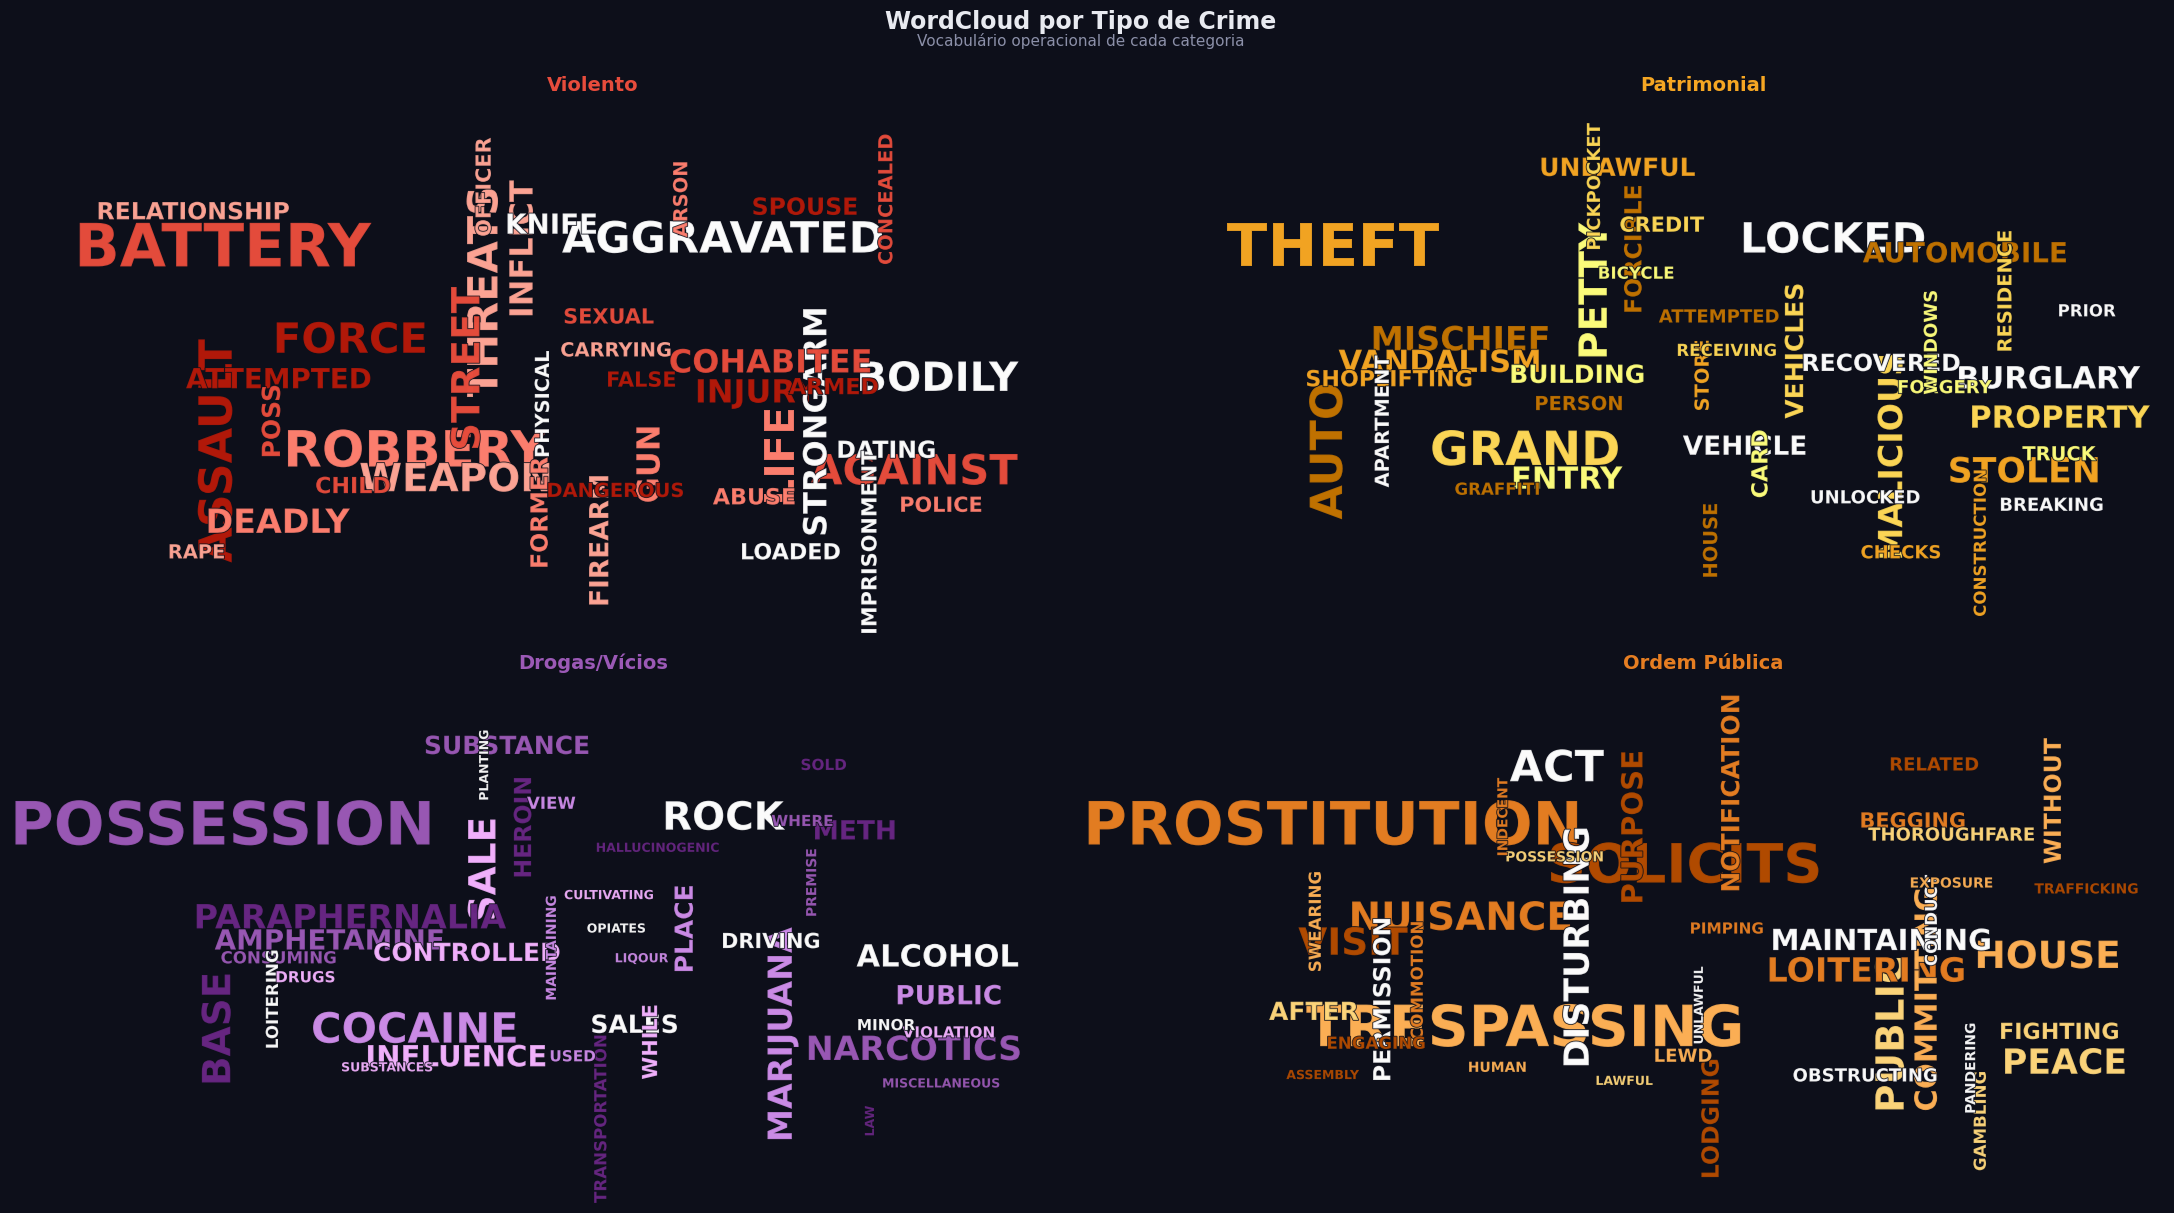

In [ ]:
# ── WordClouds por tipo de crime ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(22, 12))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'WordCloud por Tipo de Crime', 'Vocabulário operacional de cada categoria')

for ax, (ctype, color) in zip(axes.flat, CRIME_COLOR.items()):
    ax.set_facecolor(DARK_BG)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    ax.set_title(ctype, fontsize=14, fontweight='bold', color=color, pad=8)

    subset_words = ' '.join(df_crime[df_crime['CrimeType']==ctype]['Descript'].str.upper().values)
    wc = Counter(re.findall(r'\b[A-Z]{3,}\b', subset_words))
    wc = {k:v for k,v in wc.items() if k not in STOPWORDS}
    top_w = sorted(wc.items(), key=lambda x: -x[1])[:40]

    if not top_w:
        continue
    max_c = top_w[0][1]
    placed_local = []

    # Gerar tons da cor base
    base_rgb = mcolors.to_rgb(color)
    color_variants = [
        color,
        mcolors.to_hex([min(1,c+0.2) for c in base_rgb]),
        mcolors.to_hex([max(0,c-0.2) for c in base_rgb]),
        '#ffffff',
        mcolors.to_hex([min(1,c+0.35) for c in base_rgb]),
    ]

    np.random.seed(7)
    for i, (word, count) in enumerate(top_w):
        fs = 7 + int(36 * (count/max_c)**0.5)
        col = color_variants[i % len(color_variants)]
        for _ in range(150):
            x = np.random.uniform(0.03, 0.93)
            y = np.random.uniform(0.04, 0.87)
            char_w2 = (fs * 0.6 * len(word)) / (18 * 72)
            char_h2 = (fs * 1.2) / (10 * 72)
            if not overlaps(x, y, fs, placed_local):
                rot = np.random.choice([0,0,90])
                t = ax.text(x, y, word, fontsize=fs, color=col,
                            ha='center', va='center', fontweight='bold',
                            rotation=rot, alpha=0.88, transform=ax.transAxes)
                t.set_path_effects([pe.withStroke(linewidth=1.2, foreground=DARK_BG)])
                placed_local.append((x, y, fs, char_w2, char_h2))
                break

plt.tight_layout()
plt.show()


## 11. Network Graph: Co-ocorrência Categoria × Distrito

Como crimes e distritos estão conectados: **nodes** = categorias de crime e distritos; **arestas** = co-ocorrência com espessura proporcional ao volume.


Nodes: 24  |  Edges: 97


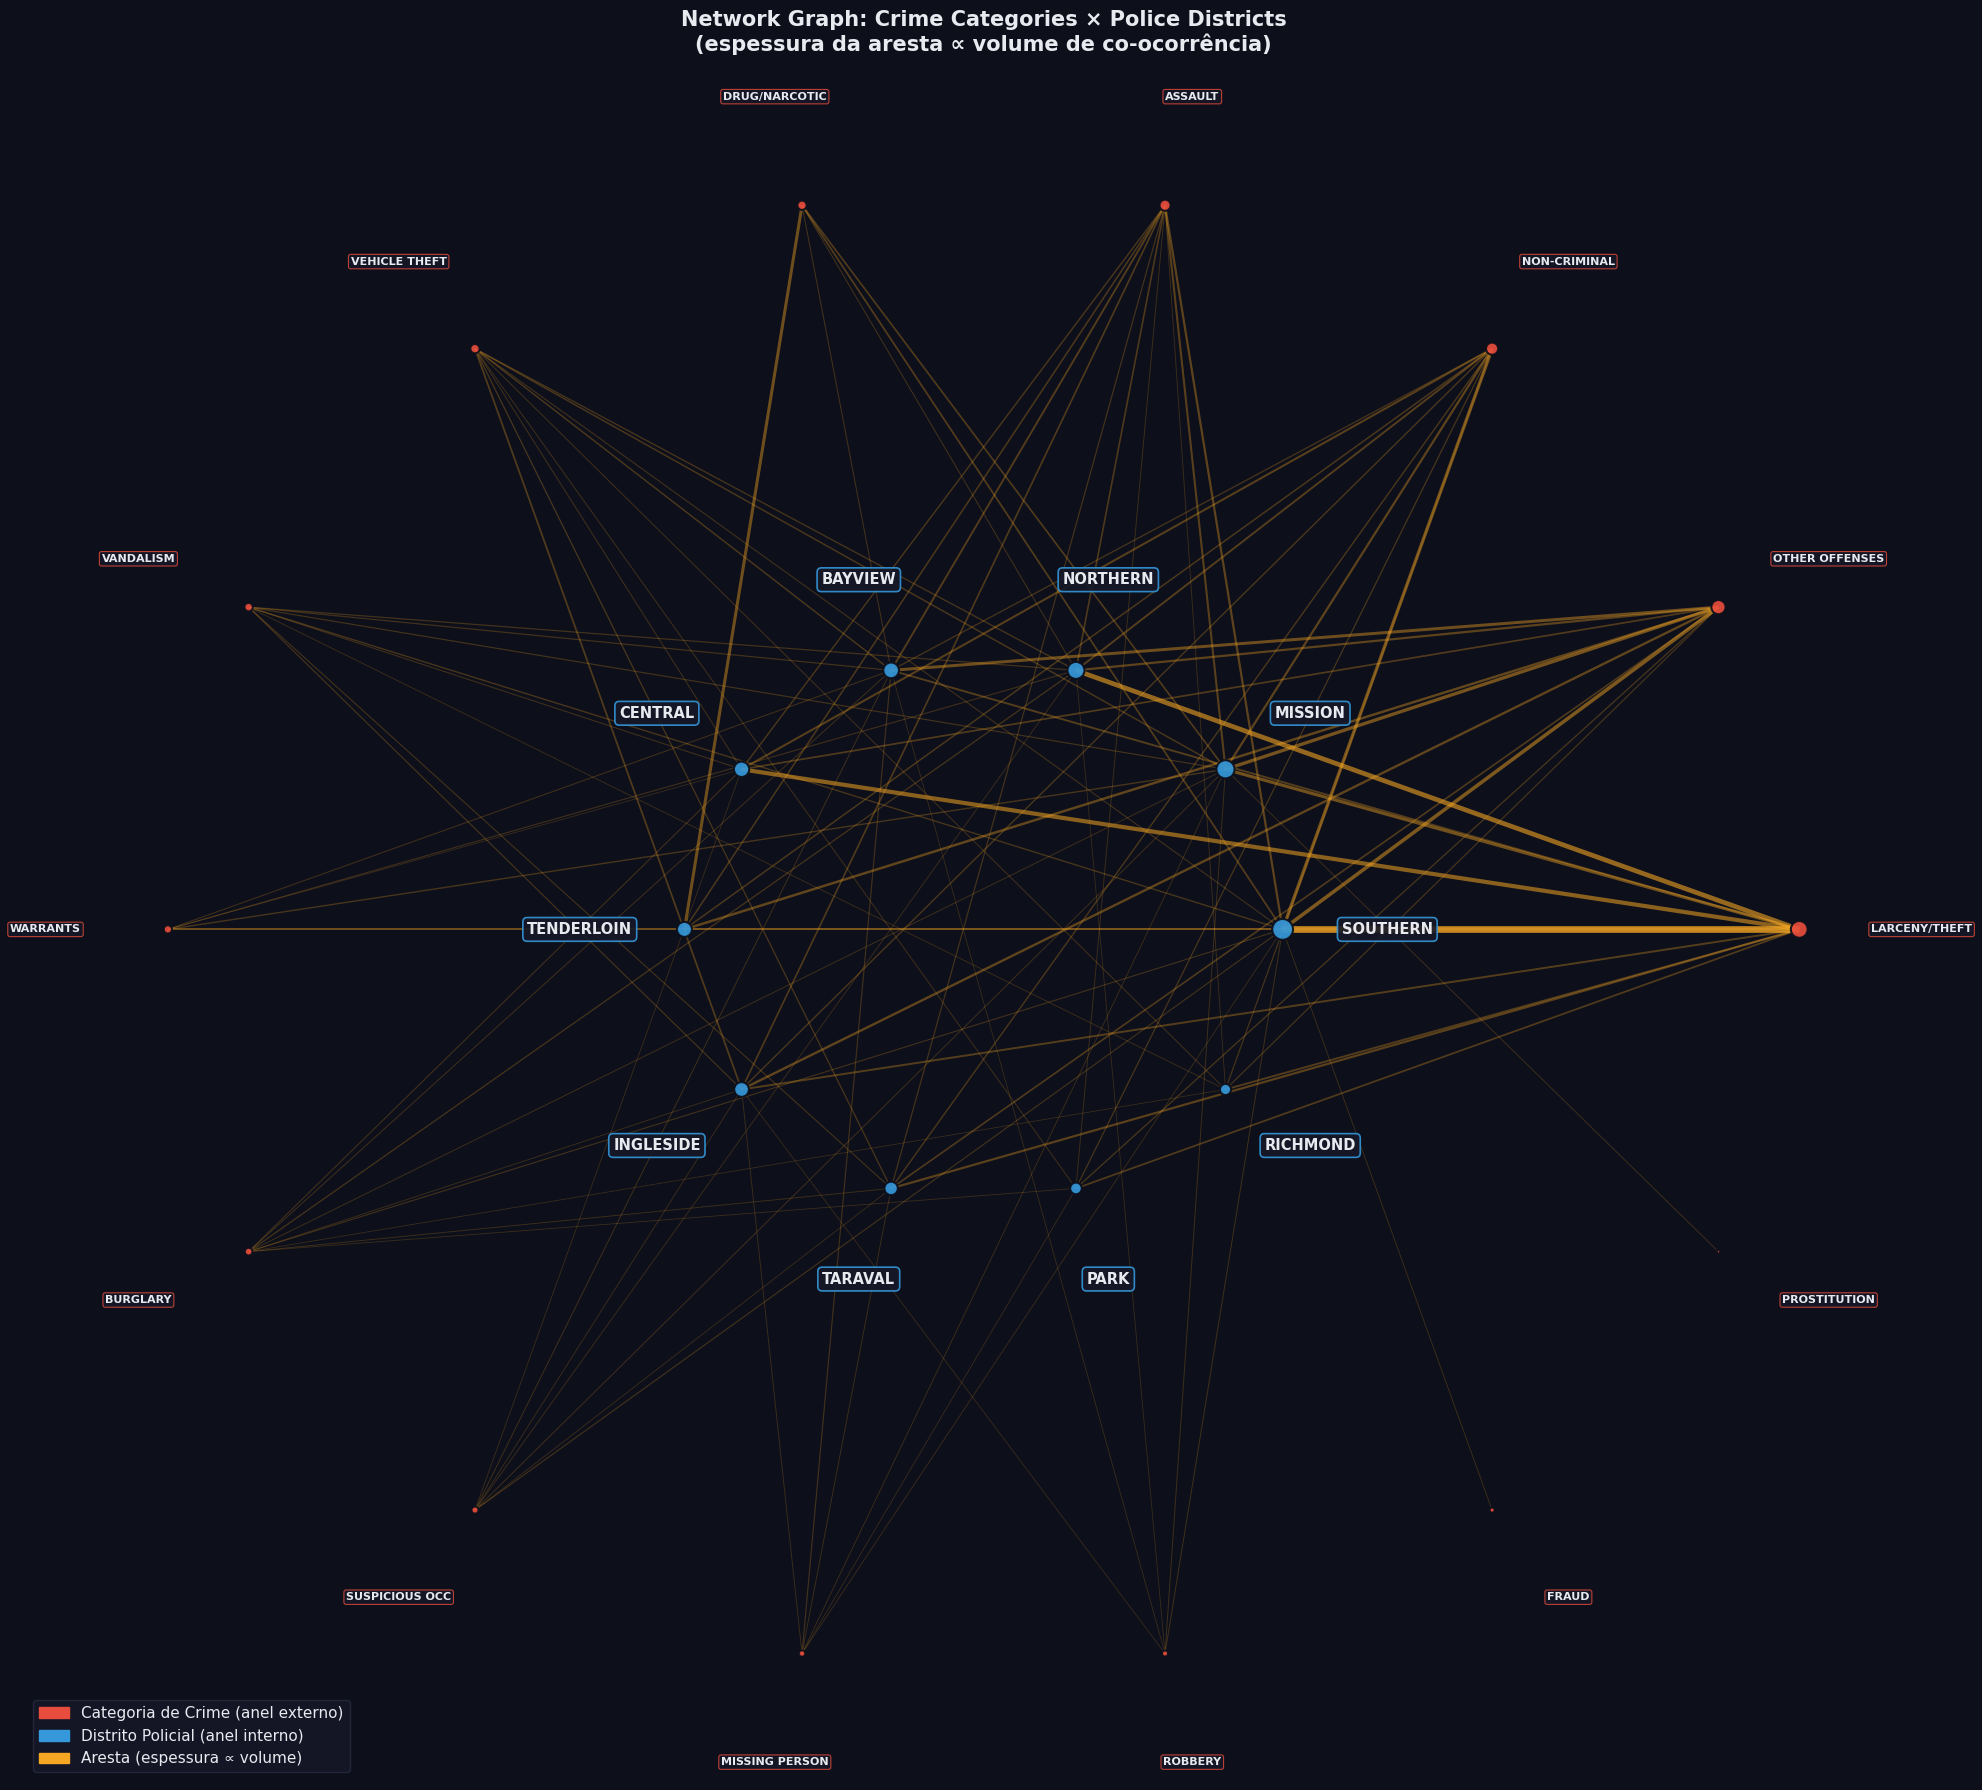

In [ ]:
# ── Build bipartite graph ───────────────────────────────────────────────────
pairs = df_crime.groupby(['Category','PdDistrict']).size().reset_index(name='weight')
min_weight = df_crime.shape[0] * 0.003   # threshold: 0.3% do total = ~2600
pairs = pairs[pairs['weight'] >= min_weight]

G = nx.Graph()
categories  = pairs['Category'].unique().tolist()
districts   = pairs['PdDistrict'].unique().tolist()

for cat in categories:
    G.add_node(cat,  node_type='category',  size=df_crime[df_crime['Category']==cat].shape[0])
for dist in districts:
    G.add_node(dist, node_type='district',  size=df_crime[df_crime['PdDistrict']==dist].shape[0])
for _, row in pairs.iterrows():
    G.add_edge(row['Category'], row['PdDistrict'], weight=row['weight'])

print(f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")

# ── Layout ────────────────────────────────────────────────────────────────
pos = {}
n_cats  = len(categories)
n_dists = len(districts)

for i, cat in enumerate(sorted(categories, key=lambda c: -df_crime[df_crime['Category']==c].shape[0])):
    angle = 2 * np.pi * i / n_cats
    pos[cat] = (1.5 * np.cos(angle), 1.5 * np.sin(angle))

for i, dist in enumerate(sorted(districts, key=lambda d: -df_crime[df_crime['PdDistrict']==d].shape[0])):
    angle = 2 * np.pi * i / n_dists
    pos[dist] = (0.55 * np.cos(angle), 0.55 * np.sin(angle))

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 18))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)
ax.axis('off')
ax.set_title('Network Graph: Crime Categories × Police Districts\n(espessura da aresta ∝ volume de co-ocorrência)',
             fontsize=15, fontweight='bold', pad=20, color=TXT)

# Arestas
edges    = G.edges(data=True)
max_w    = max(d['weight'] for _,_,d in edges)
for u, v, data in G.edges(data=True):
    w     = data['weight']
    alpha = 0.15 + 0.65 * (w / max_w)
    lw    = 0.3  + 4.5  * (w / max_w)
    nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], ax=ax,
                           width=lw, alpha=alpha, edge_color=AMBER)

# Nodes: categorias (externo)
cat_sizes  = [G.nodes[n]['size'] / 1200 for n in categories]
nx.draw_networkx_nodes(G, pos, nodelist=categories, ax=ax,
                       node_color=RED, node_size=cat_sizes,
                       alpha=0.92, edgecolors=DARK_BG, linewidths=1.5)

# Nodes: distritos (interno)
dist_sizes = [G.nodes[n]['size'] / 700 for n in districts]
nx.draw_networkx_nodes(G, pos, nodelist=districts, ax=ax,
                       node_color=BLUE, node_size=dist_sizes,
                       alpha=0.92, edgecolors=DARK_BG, linewidths=1.5)

# Labels
label_offset_cat  = {n: (pos[n][0]*1.15, pos[n][1]*1.15) for n in categories}
label_offset_dist = {n: (pos[n][0]*1.35, pos[n][1]*1.35) for n in districts}
for n, (x,y) in label_offset_cat.items():
    ax.text(x, y, n, ha='center', va='center', fontsize=8, color=TXT,
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.2',
            facecolor=CARD_BG, edgecolor=RED, alpha=0.8, linewidth=0.8))
for n, (x,y) in label_offset_dist.items():
    ax.text(x, y, n, ha='center', va='center', fontsize=10.5, color=TXT,
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.3',
            facecolor=CARD_BG, edgecolor=BLUE, alpha=0.9, linewidth=1.2))

# Legenda
leg_handles = [
    mpatches.Patch(color=RED,  label='Categoria de Crime (anel externo)'),
    mpatches.Patch(color=BLUE, label='Distrito Policial (anel interno)'),
    mpatches.Patch(color=AMBER, label='Aresta (espessura ∝ volume)'),
]
ax.legend(handles=leg_handles, loc='lower left', facecolor=CARD_BG,
          edgecolor=BORDER, fontsize=11)

plt.tight_layout()
plt.show()


Mostra a clara correlacao entre tipo de crime e regiao, especialmente Larceny/Theft e Southern.

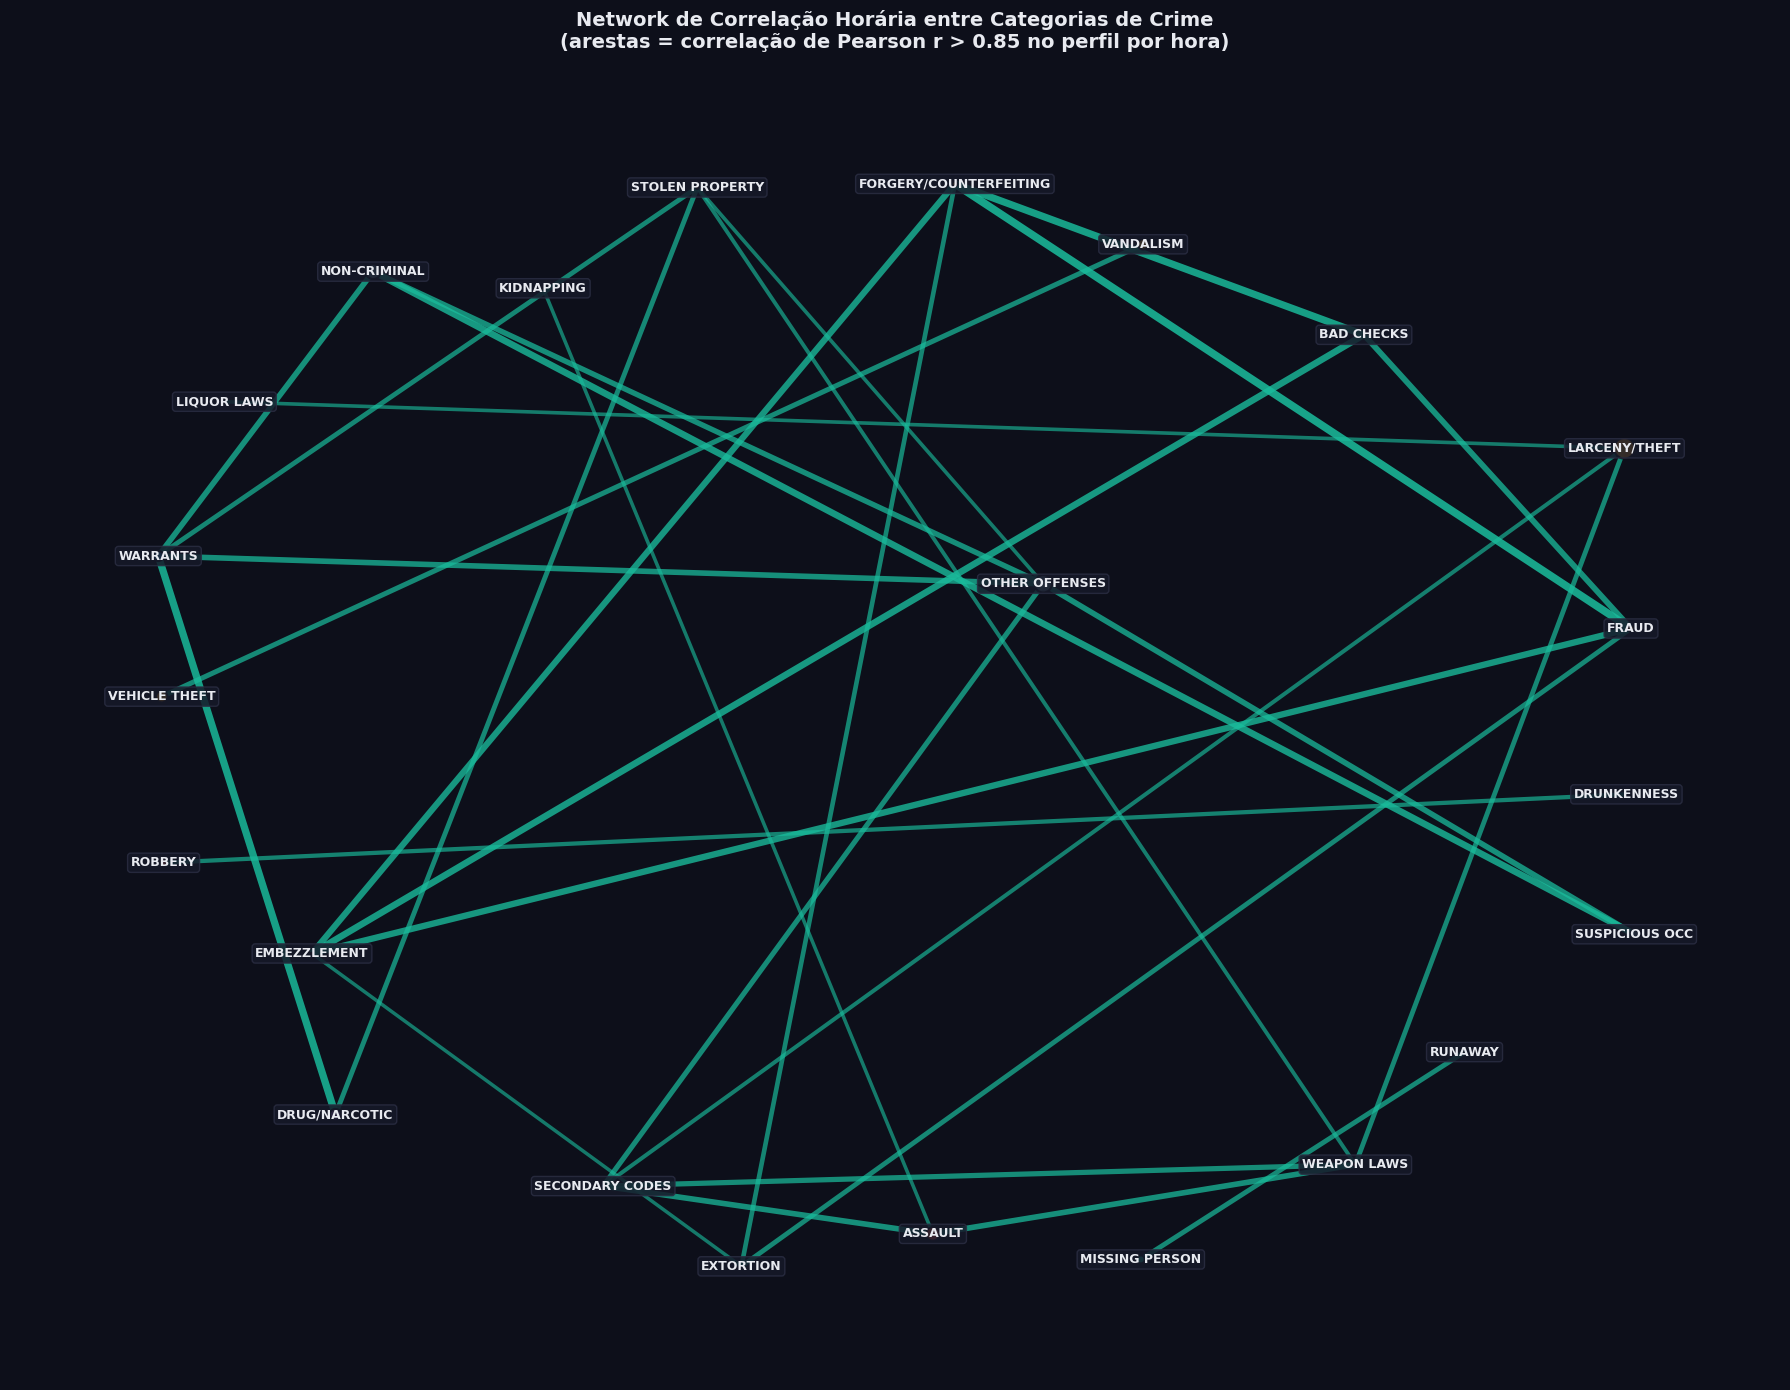

In [ ]:
# ── Network de co-ocorrência categoria × hora do dia ──────────────────────
# (qual crime tende a acontecer ao mesmo tempo que outro)
hour_cat = df_crime.groupby(['Hour','Category']).size().unstack(fill_value=0)
# Correlação entre categorias pelo perfil horário
corr_matrix = hour_cat.corr()

# Top pares mais correlacionados
corr_pairs = []
cats_list = corr_matrix.columns.tolist()
for i, c1 in enumerate(cats_list):
    for c2 in cats_list[i+1:]:
        corr_pairs.append((c1, c2, corr_matrix.loc[c1,c2]))
corr_pairs.sort(key=lambda x: -x[2])

G2 = nx.Graph()
for c1, c2, r in corr_pairs[:30]:   # top 30 pares
    if r > 0.85:
        G2.add_edge(c1, c2, weight=r)

pos2 = nx.spring_layout(G2, seed=42, k=2.5)
fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG); ax.axis('off')
ax.set_title('Network de Correlação Horária entre Categorias de Crime\n(arestas = correlação de Pearson r > 0.85 no perfil por hora)',
             fontsize=14, fontweight='bold', pad=16, color=TXT)

for u, v, data in G2.edges(data=True):
    nx.draw_networkx_edges(G2, pos2, edgelist=[(u,v)], ax=ax,
                           width=1+5*(data['weight']-0.85)/0.15,
                           alpha=0.5 + 0.4*(data['weight']-0.85)/0.15,
                           edge_color=TEAL)

node_sizes = [df_crime[df_crime['Category']==n].shape[0]/800 if n in df_crime['Category'].values else 50
              for n in G2.nodes()]
node_colors = [CRIME_COLOR.get(
    df_crime[df_crime['Category']==n]['CrimeType'].iloc[0] if n in df_crime['Category'].values else 'Outros',
    BLUE) for n in G2.nodes()]

nx.draw_networkx_nodes(G2, pos2, ax=ax, node_size=node_sizes,
                       node_color=node_colors, alpha=0.9,
                       edgecolors=DARK_BG, linewidths=1.5)
nx.draw_networkx_labels(G2, pos2, ax=ax, font_size=9, font_color=TXT,
                        font_weight='bold',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor=CARD_BG,
                                  edgecolor=BORDER, alpha=0.85))

plt.tight_layout()
plt.show()


O grafo acrescenta pouco alem da tabela de co-ocorrencia, mas torna visivel a concentracao de categorias em Southern.

In [ ]:
do

## 12. Clusterização Geográfica

**KMeans com 8 clusters** para dividir a cidade em zonas de alta criminalidade e identificar os 3 candidatos para novas delegacias.


In [ ]:
# ── KMeans nas coordenadas: usando df_geo com flag de imputados ──────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Usar df_geo para clusterização geoespacial (maior volume = melhor)
# Excluir imputados pelo distrito (passo 2) para não enviesar centroides
# Obs: imputados pelo endereço (passo 1) são precisos → podem entrar
df_for_cluster = df_geo.copy()

coords_arr = df_for_cluster[['X','Y']].values
scaler     = StandardScaler()
coords_s   = scaler.fit_transform(coords_arr)

km = KMeans(n_clusters=8, random_state=42, n_init=15, max_iter=400)
df_for_cluster['Cluster'] = km.fit_predict(coords_s)

# Propagar clusters para df_geo e df_crime
df_geo['Cluster']   = df_for_cluster['Cluster']
# Para df_crime: match por índice do train dentro do df_geo
train_mask = df_geo['source'] == 'train'
df_crime['Cluster'] = df_geo.loc[train_mask, 'Cluster'].values

cluster_counts = df_geo['Cluster'].value_counts().sort_values(ascending=False)
top3_clusters  = cluster_counts.head(3).index.tolist()
cluster_centers = scaler.inverse_transform(km.cluster_centers_)

print(f"KMeans fit em {len(df_for_cluster):,} pontos (incluindo {df_geo['coord_imputed'].sum()} imputados flagados)")
print(f"\nVolume por cluster:")
print(cluster_counts.to_string())
print(f"\nTop 3 clusters: {top3_clusters}")


KMeans fit em 1,762,311 pontos (incluindo 143 imputados flagados)

Volume por cluster:
Cluster
4    582096
3    321372
0    253924
1    165604
6    143304
5    116759
7     93415
2     85837

Top 3 clusters: [4, 3, 0]


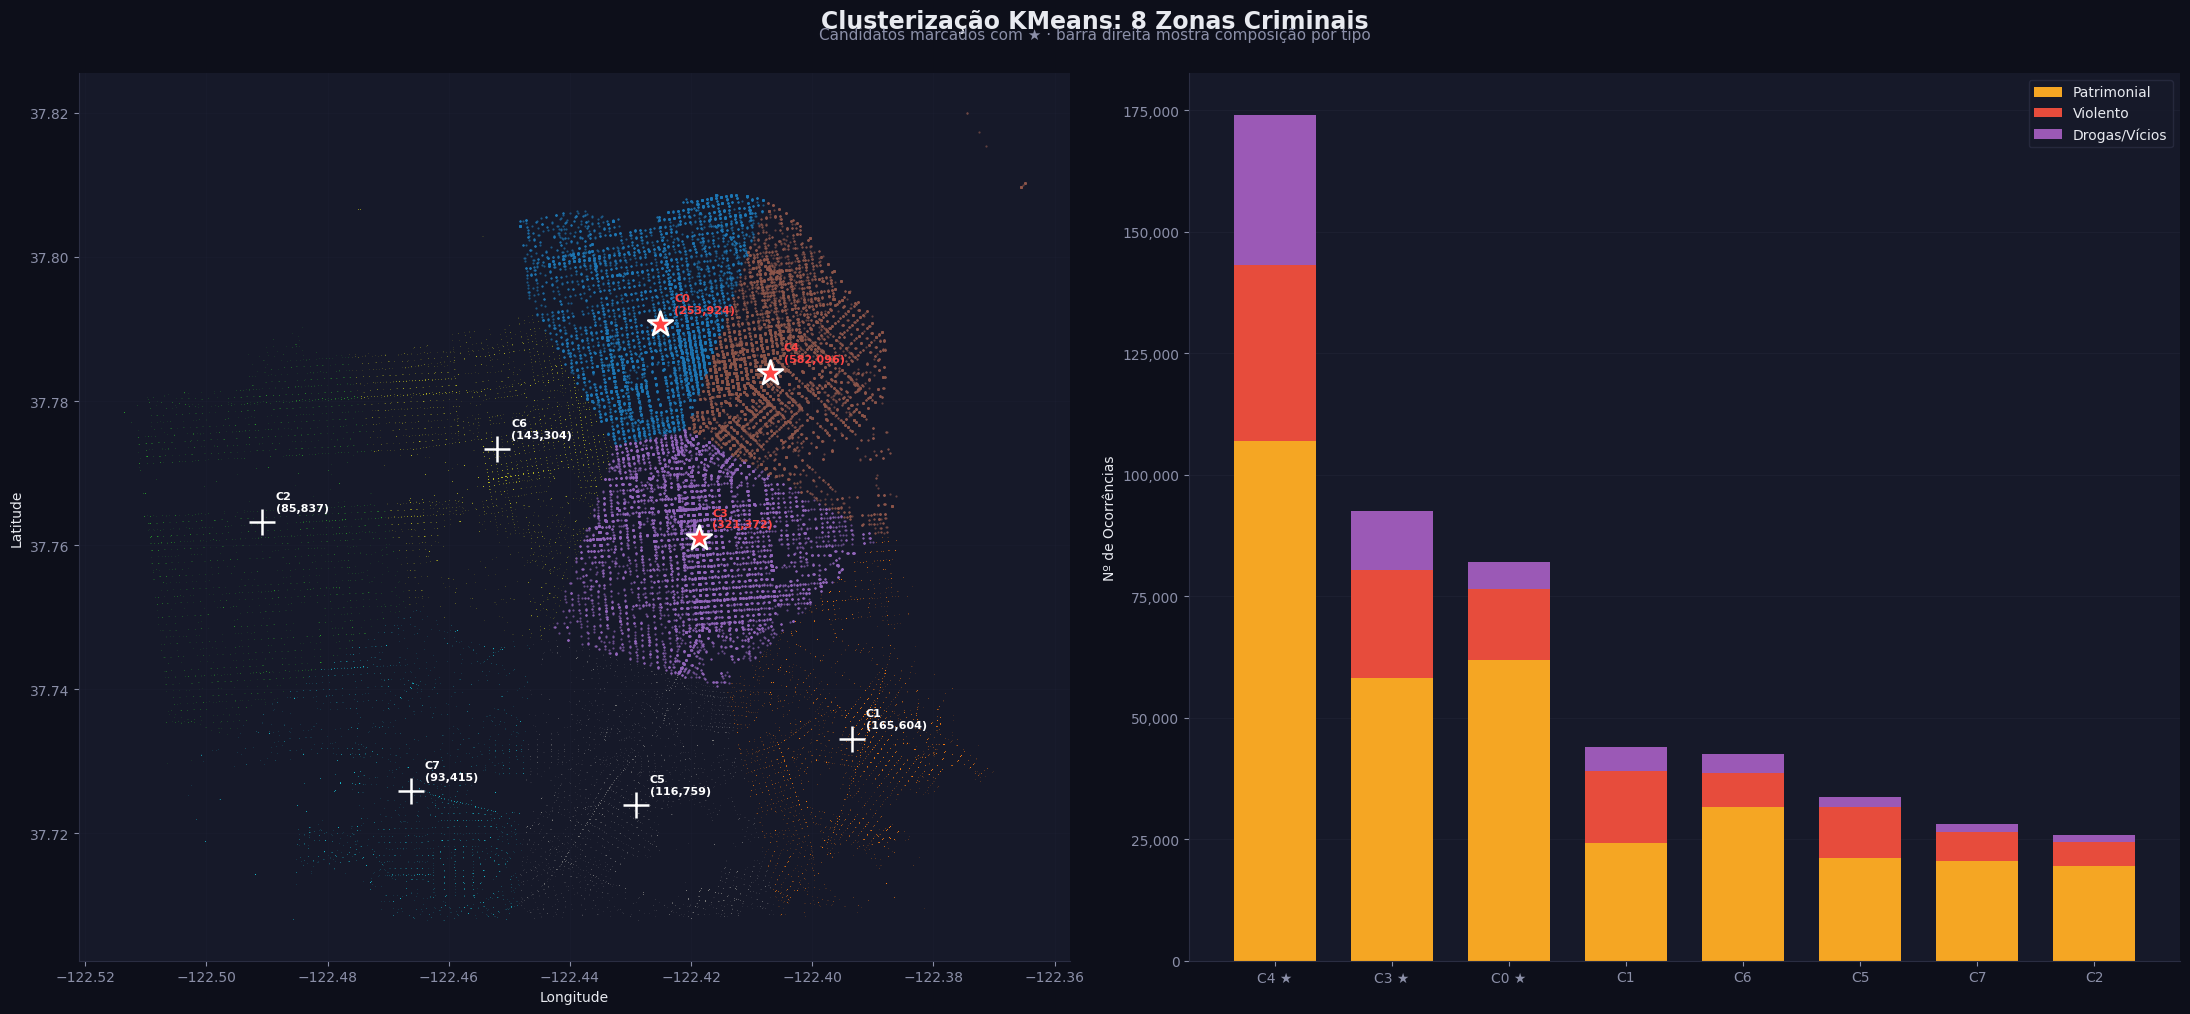

In [ ]:
sample_geo = df_geo.sample(80_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Clusterização KMeans: 8 Zonas Criminais',
          'Candidatos marcados com ★ · barra direita mostra composição por tipo')

ax = axes[0]
cpal = plt.cm.tab10(np.linspace(0,1,8))
for c in range(8):
    mask  = sample_geo['Cluster'] == c
    alpha = 0.65 if c in top3_clusters else 0.18
    sz    = 2.5  if c in top3_clusters else 0.6
    ax.scatter(sample_geo.loc[mask,'X'], sample_geo.loc[mask,'Y'],
               c=[cpal[c]], s=sz, alpha=alpha, linewidths=0, rasterized=True)
for i, (cx, cy) in enumerate(cluster_centers):
    col = '#ff4444' if i in top3_clusters else '#ffffff'
    ax.scatter(cx, cy, c=col, s=350, zorder=12, edgecolors='white',
               linewidths=1.8, marker='*' if i in top3_clusters else '+')
    ax.annotate(f'C{i}\n({cluster_counts[i]:,})', (cx,cy),
                textcoords='offset points', xytext=(10,8),
                fontsize=8, color=col, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.grid(alpha=0.15)

ax = axes[1]
cluster_type = df_crime.groupby(['Cluster','CrimeType']).size().unstack(fill_value=0)
order_c  = cluster_counts.index
cluster_type = cluster_type.reindex(order_c)
xlabels  = [f"C{c}" + (" ★" if c in top3_clusters else "") for c in order_c]
bottom   = np.zeros(len(cluster_type))
for ctype in ['Patrimonial','Violento','Drogas/Vícios','Outros']:
    if ctype in cluster_type.columns:
        ax.bar(xlabels, cluster_type[ctype], bottom=bottom, label=ctype,
               color=CRIME_COLOR[ctype], edgecolor='none', width=0.7)
        bottom += cluster_type[ctype].values
ax.set_ylabel('Nº de Ocorrências'); ax.legend(facecolor=CARD_BG, edgecolor=BORDER)
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.show()


Os 3 clusters candidatos (★) dominam em volume mas divergem em composição. C4 se destaca não só pelo tamanho (582k) mas pela proporção elevada de Drogas/Vícios em roxo, sinal de que a zona TENDERLOIN/SOUTHERN carrega um perfil de criminalidade mais complexo que os outros dois. C3 e C0 têm barras menores e composição mais equilibrada entre Patrimonial e Violento, sem pico de drogas comparável. Os 5 clusters não-candidatos (C1, C6, C5, C7, C2) somados mal superam C4 sozinho, o que confirma visualmente que a criminalidade de SF não é distribuída

## 13. Análises Extras

### 13a. Tendência de Longo Prazo por Tipo  
### 13b. Perfil de Reincidência por Endereço  
### 13c. Crimes de Alta Gravidade: Hora × Tipo  
### 13d. Mapa de Calor DBSCAN: Hotspots Densos


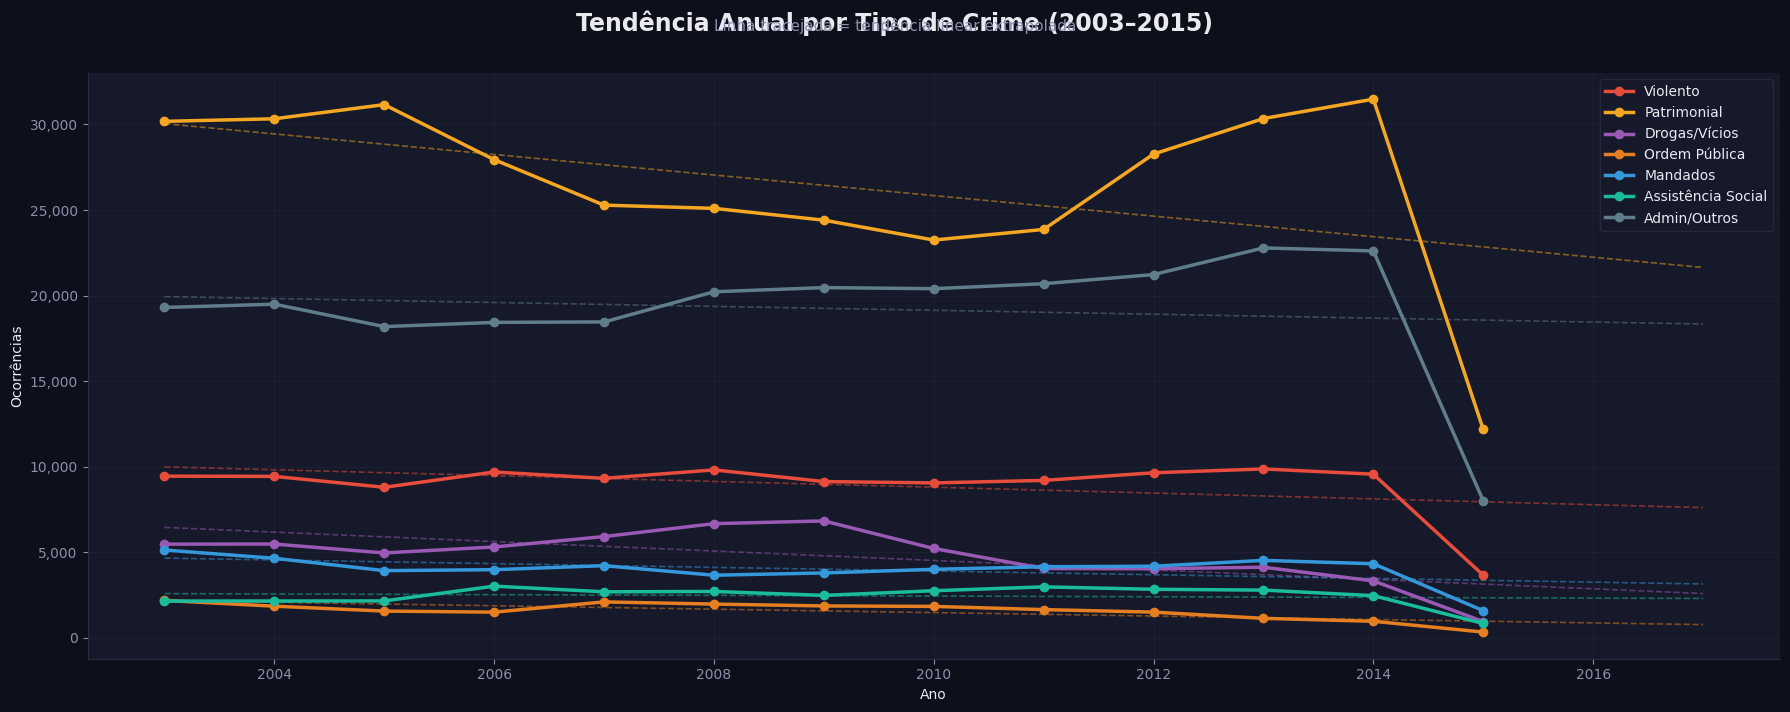

In [ ]:
# ── 13a. Tendência anual por tipo de crime ────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Tendência Anual por Tipo de Crime (2003–2015)',
          'Linha tracejada = tendência linear extrapolada')

yearly_type = df_crime.groupby(['Year','CrimeType']).size().unstack(fill_value=0)
for ctype, color in CRIME_COLOR.items():
    if ctype not in yearly_type.columns: continue
    vals = yearly_type[ctype]
    ax.plot(vals.index, vals.values, color=color, lw=2.5, marker='o',
            markersize=6, label=ctype, zorder=5)
    # Tendência linear
    z = np.polyfit(vals.index, vals.values, 1)
    p = np.poly1d(z)
    x_ext = np.array([vals.index.min(), vals.index.max()+2])
    ax.plot(x_ext, p(x_ext), color=color, lw=1.2, linestyle='--', alpha=0.5)

ax.set_xlabel('Ano'); ax.set_ylabel('Ocorrências')
ax.legend(facecolor=CARD_BG, edgecolor=BORDER)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); plt.show()


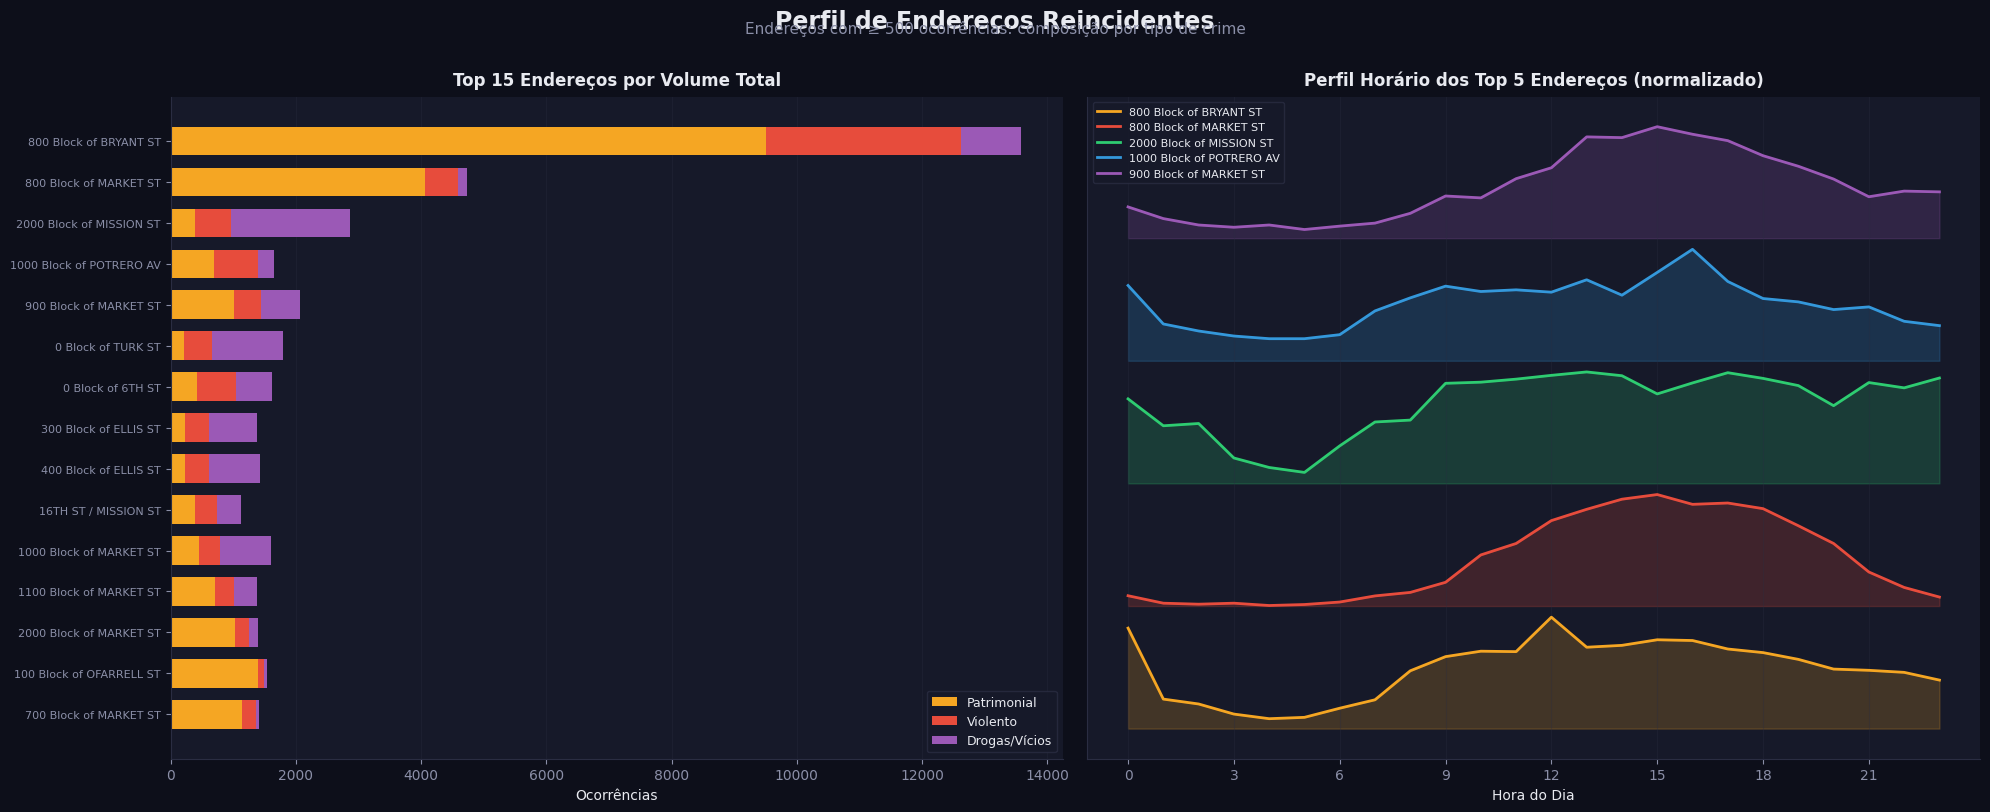

In [ ]:
# ── 13b. Reincidência: endereços com mais crimes por tipo ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Perfil de Endereços Reincidentes',
          'Endereços com ≥ 500 ocorrências: composição por tipo de crime')

addr_type = df_crime.groupby(['Address','CrimeType']).size().unstack(fill_value=0)
addr_type['Total'] = addr_type.sum(axis=1)
top_addr_df = addr_type.nlargest(15, 'Total').drop(columns='Total')

ax = axes[0]
bottom = np.zeros(len(top_addr_df))
for ctype in ['Patrimonial','Violento','Drogas/Vícios','Outros']:
    if ctype in top_addr_df.columns:
        ax.barh(top_addr_df.index[::-1], top_addr_df[ctype][::-1],
                left=bottom[::-1], label=ctype, color=CRIME_COLOR[ctype],
                height=0.7, edgecolor='none')
        bottom += top_addr_df[ctype].values
# Re-draw correctly
ax.cla()
order_idx = top_addr_df.sum(axis=1).sort_values().index
top_addr_sorted = top_addr_df.loc[order_idx]
bottom_h = np.zeros(len(top_addr_sorted))
for ctype in ['Patrimonial','Violento','Drogas/Vícios','Outros']:
    if ctype in top_addr_sorted.columns:
        ax.barh(range(len(top_addr_sorted)), top_addr_sorted[ctype].values,
                left=bottom_h, label=ctype, color=CRIME_COLOR[ctype],
                height=0.7, edgecolor='none')
        bottom_h += top_addr_sorted[ctype].values
ax.set_yticks(range(len(top_addr_sorted)))
ax.set_yticklabels([a[:35] for a in top_addr_sorted.index], fontsize=8)
ax.set_title('Top 15 Endereços por Volume Total', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Ocorrências')
ax.legend(facecolor=CARD_BG, edgecolor=BORDER, fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)

# Box: volume de crimes por faixa horária nos top endereços
ax = axes[1]
top5_addr = df_crime['Address'].value_counts().head(5).index.tolist()
for i, addr in enumerate(top5_addr):
    hourly_a = df_crime[df_crime['Address']==addr].groupby('Hour').size()
    hourly_a = hourly_a.reindex(range(24), fill_value=0)
    norm_h   = hourly_a / hourly_a.max()
    ax.plot(range(24), norm_h.values + i*1.1, color=PALETTE[i], lw=2,
            label=addr[:30])
    ax.fill_between(range(24), i*1.1, norm_h.values+i*1.1,
                    alpha=0.2, color=PALETTE[i])
ax.set_title('Perfil Horário dos Top 5 Endereços (normalizado)', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Hora do Dia')
ax.set_yticks([]); ax.legend(facecolor=CARD_BG, edgecolor=BORDER, fontsize=8)
ax.grid(alpha=0.3); ax.set_xticks(range(0,24,3))

plt.tight_layout(); plt.show()


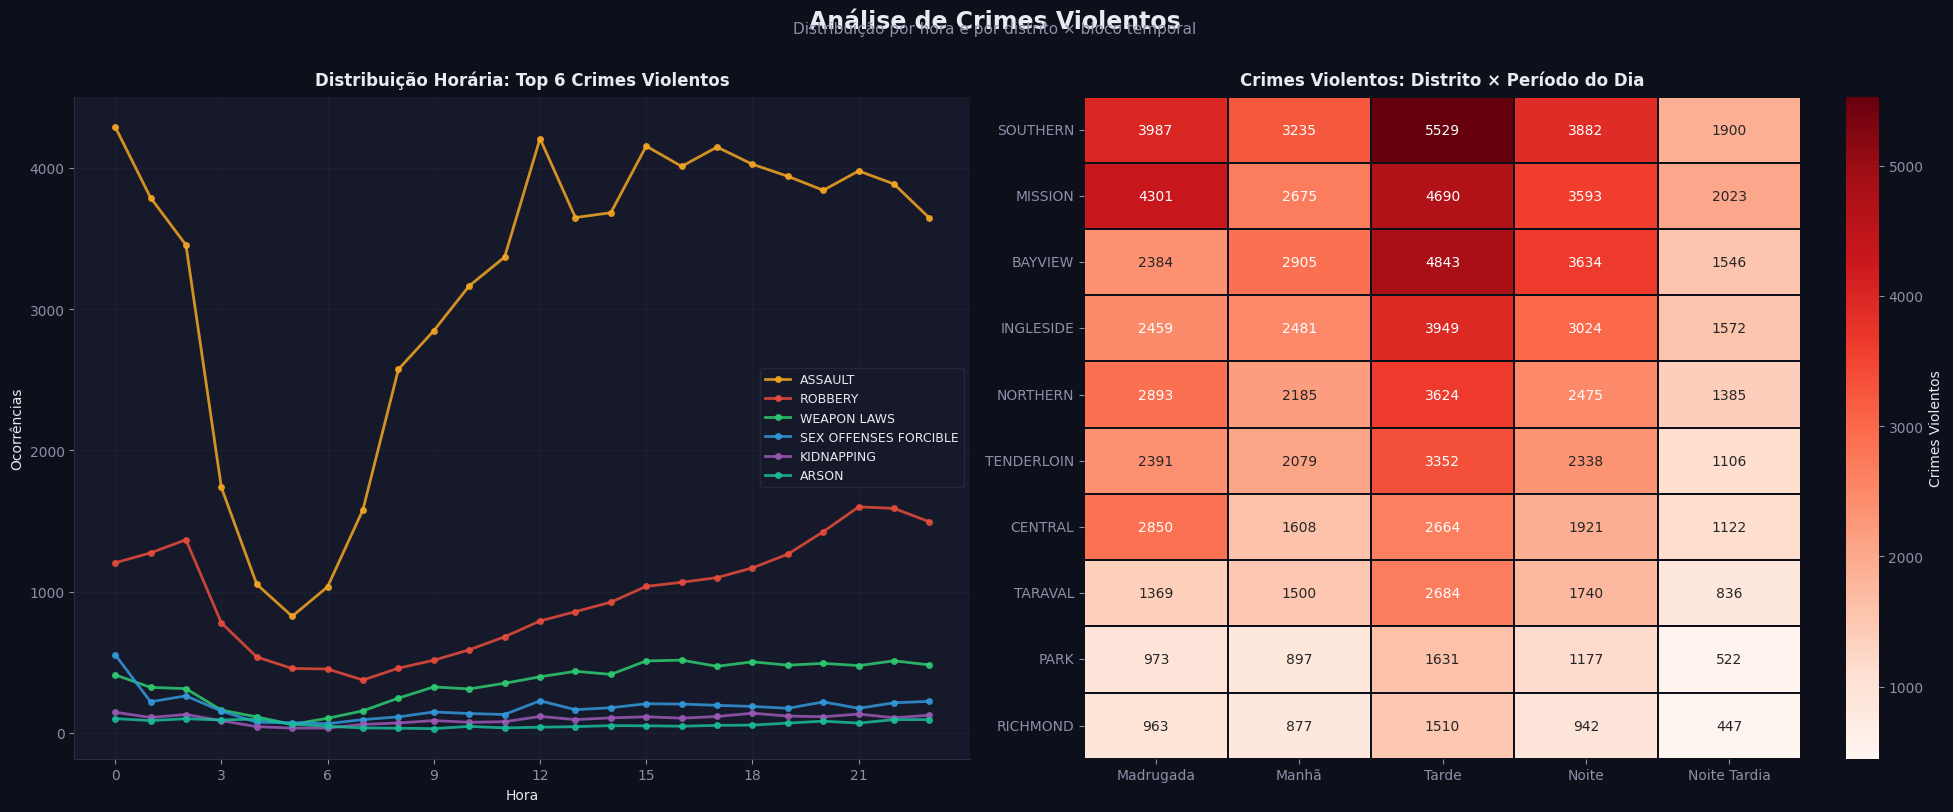

In [ ]:
# ── 13c. Crimes violentos: hora × bloco temporal x distrito ─────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Análise de Crimes Violentos',
          'Distribuição por hora e por distrito × bloco temporal')

# Hora por subcategoria violenta
ax = axes[0]
violent_cats = df_crime[df_crime['CrimeType']=='Violento']['Category'].value_counts().head(6).index
for i, cat in enumerate(violent_cats):
    hourly_v = df_crime[df_crime['Category']==cat].groupby('Hour').size().reindex(range(24), fill_value=0)
    ax.plot(range(24), hourly_v.values, color=PALETTE[i], lw=2, marker='o',
            markersize=4, label=cat, alpha=0.85)
ax.set_title('Distribuição Horária: Top 6 Crimes Violentos', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Hora'); ax.set_ylabel('Ocorrências')
ax.set_xticks(range(0,24,3)); ax.legend(facecolor=CARD_BG, edgecolor=BORDER, fontsize=9)
ax.grid(alpha=0.3)

# Heatmap distrito × bloco
ax = axes[1]
pvt = df_crime[df_crime['CrimeType']=='Violento'].pivot_table(
    index='PdDistrict', columns='TimeBlock', aggfunc='size', fill_value=0)
pvt = pvt[['Madrugada','Manhã','Tarde','Noite','Noite Tardia']]
pvt = pvt.loc[pvt.sum(axis=1).sort_values(ascending=False).index]
sns.heatmap(pvt, ax=ax, cmap='Reds', linewidths=0.3, linecolor=DARK_BG,
            annot=True, fmt='d', cbar_kws={'label':'Crimes Violentos'})
ax.set_title('Crimes Violentos: Distrito × Período do Dia', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel(''); ax.set_ylabel('')

plt.tight_layout(); plt.show()


A Tarde é o período mais violento em todos os distritos sem exceção

DBSCAN → amostras em clusters: 13,963  |  ruído: 6,037
Clusters encontrados: 119


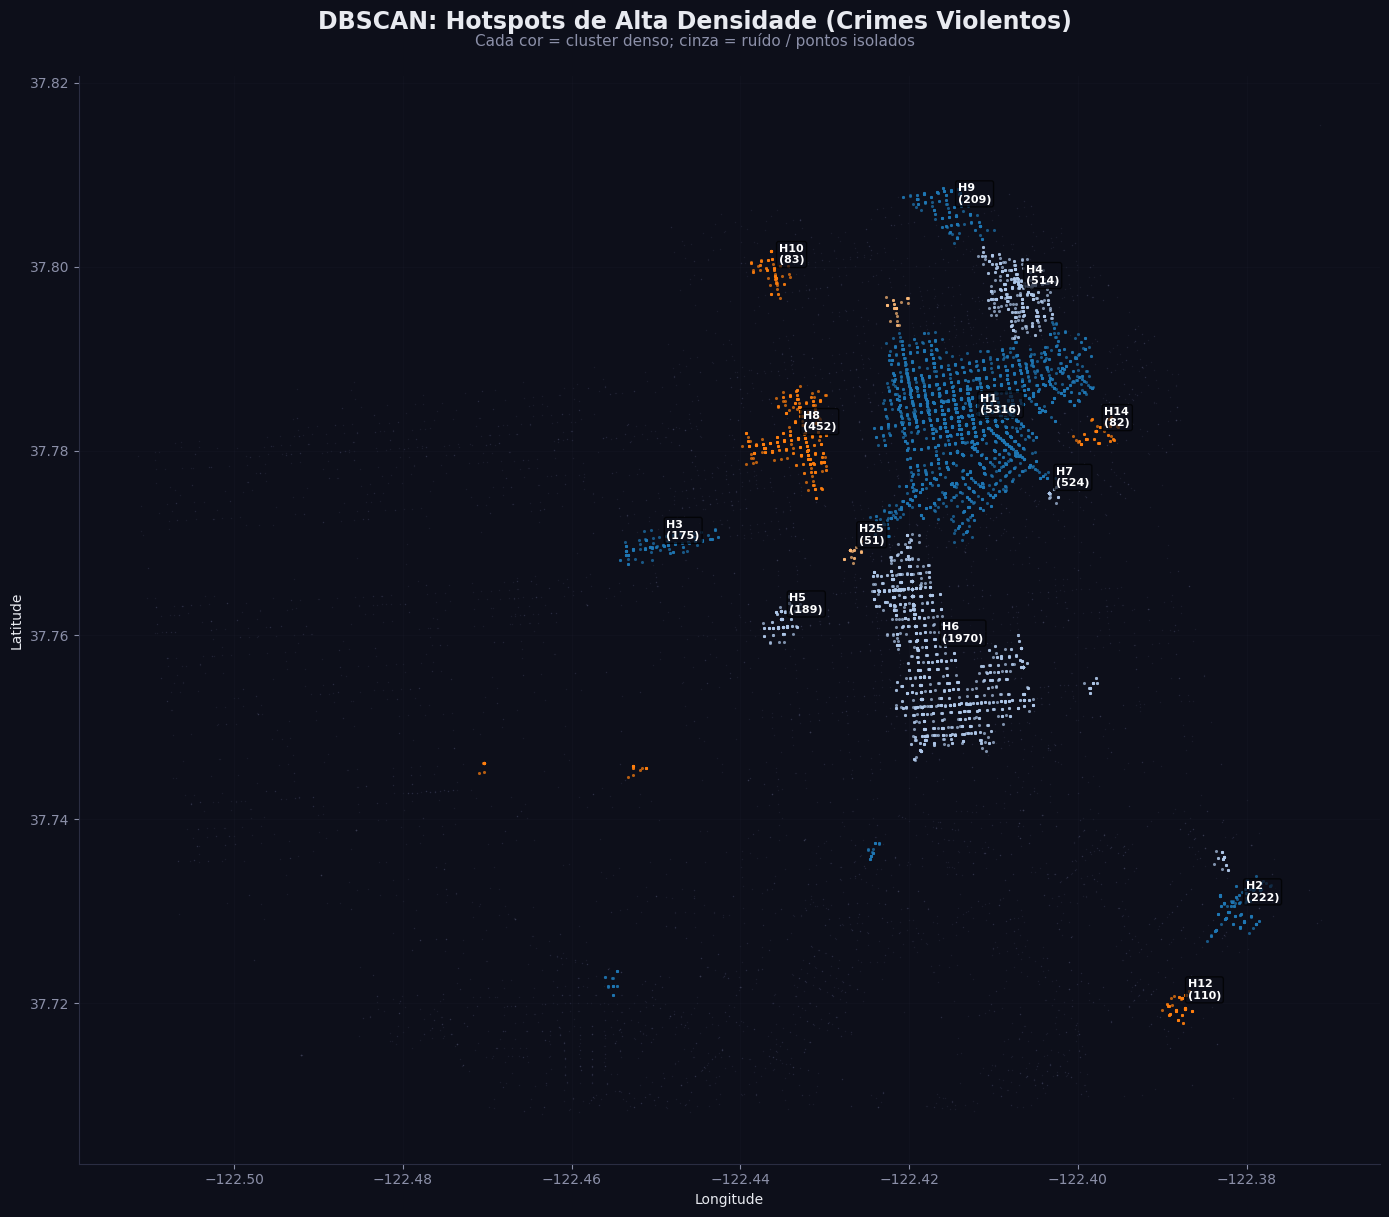

In [ ]:
# ── 13d. DBSCAN: hotspots de ultra-alta densidade ────────────────────────
# Usar apenas crimes violentos para encontrar micro-hotspots
violent_df = df_crime[df_crime['CrimeType']=='Violento'][['X','Y']].sample(20_000, random_state=42)
coords_v   = scaler.fit_transform(violent_df.values)

db = DBSCAN(eps=0.04, min_samples=15).fit(coords_v)
violent_df = violent_df.copy()
violent_df['DB_Label'] = db.labels_

n_clusters_db = (violent_df['DB_Label'] >= 0).sum()
n_noise       = (violent_df['DB_Label'] == -1).sum()
print(f"DBSCAN → amostras em clusters: {n_clusters_db:,}  |  ruído: {n_noise:,}")
print(f"Clusters encontrados: {violent_df['DB_Label'].max()+1}")

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)
fig_title(fig, 'DBSCAN: Hotspots de Alta Densidade (Crimes Violentos)',
          'Cada cor = cluster denso; cinza = ruído / pontos isolados')

noise_mask = violent_df['DB_Label'] == -1
ax.scatter(violent_df.loc[noise_mask,'X'], violent_df.loc[noise_mask,'Y'],
           c='#3a3d52', s=1, alpha=0.3, linewidths=0, rasterized=True)

unique_labels = [l for l in violent_df['DB_Label'].unique() if l >= 0]
cmap_db = plt.cm.tab20(np.linspace(0,1,max(len(unique_labels),1)))
for i, label in enumerate(unique_labels[:20]):
    mask = violent_df['DB_Label'] == label
    ax.scatter(violent_df.loc[mask,'X'], violent_df.loc[mask,'Y'],
               c=[cmap_db[i]], s=5, alpha=0.7, linewidths=0, rasterized=True)
    cx = violent_df.loc[mask,'X'].mean()
    cy = violent_df.loc[mask,'Y'].mean()
    count_db = mask.sum()
    if count_db > 50:
        ax.annotate(f'H{label}\n({count_db})', (cx,cy),
                    textcoords='offset points', xytext=(5,5),
                    fontsize=8, color='white', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor=DARK_BG, alpha=0.7))

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.grid(alpha=0.12)
plt.tight_layout(); plt.show()


DBSCAN significa Density-Based Spatial Clustering of Applications with Noise: É um algoritmo de clusterização baseado em densidade, não em distância ao centroide como o KMeans.



## 14. Recomendação Final: Localização e Especialidade das 3 Delegacias

Os 3 maiores clusters somam 1.15 milhão de crimes, que representa 66% de toda a base.

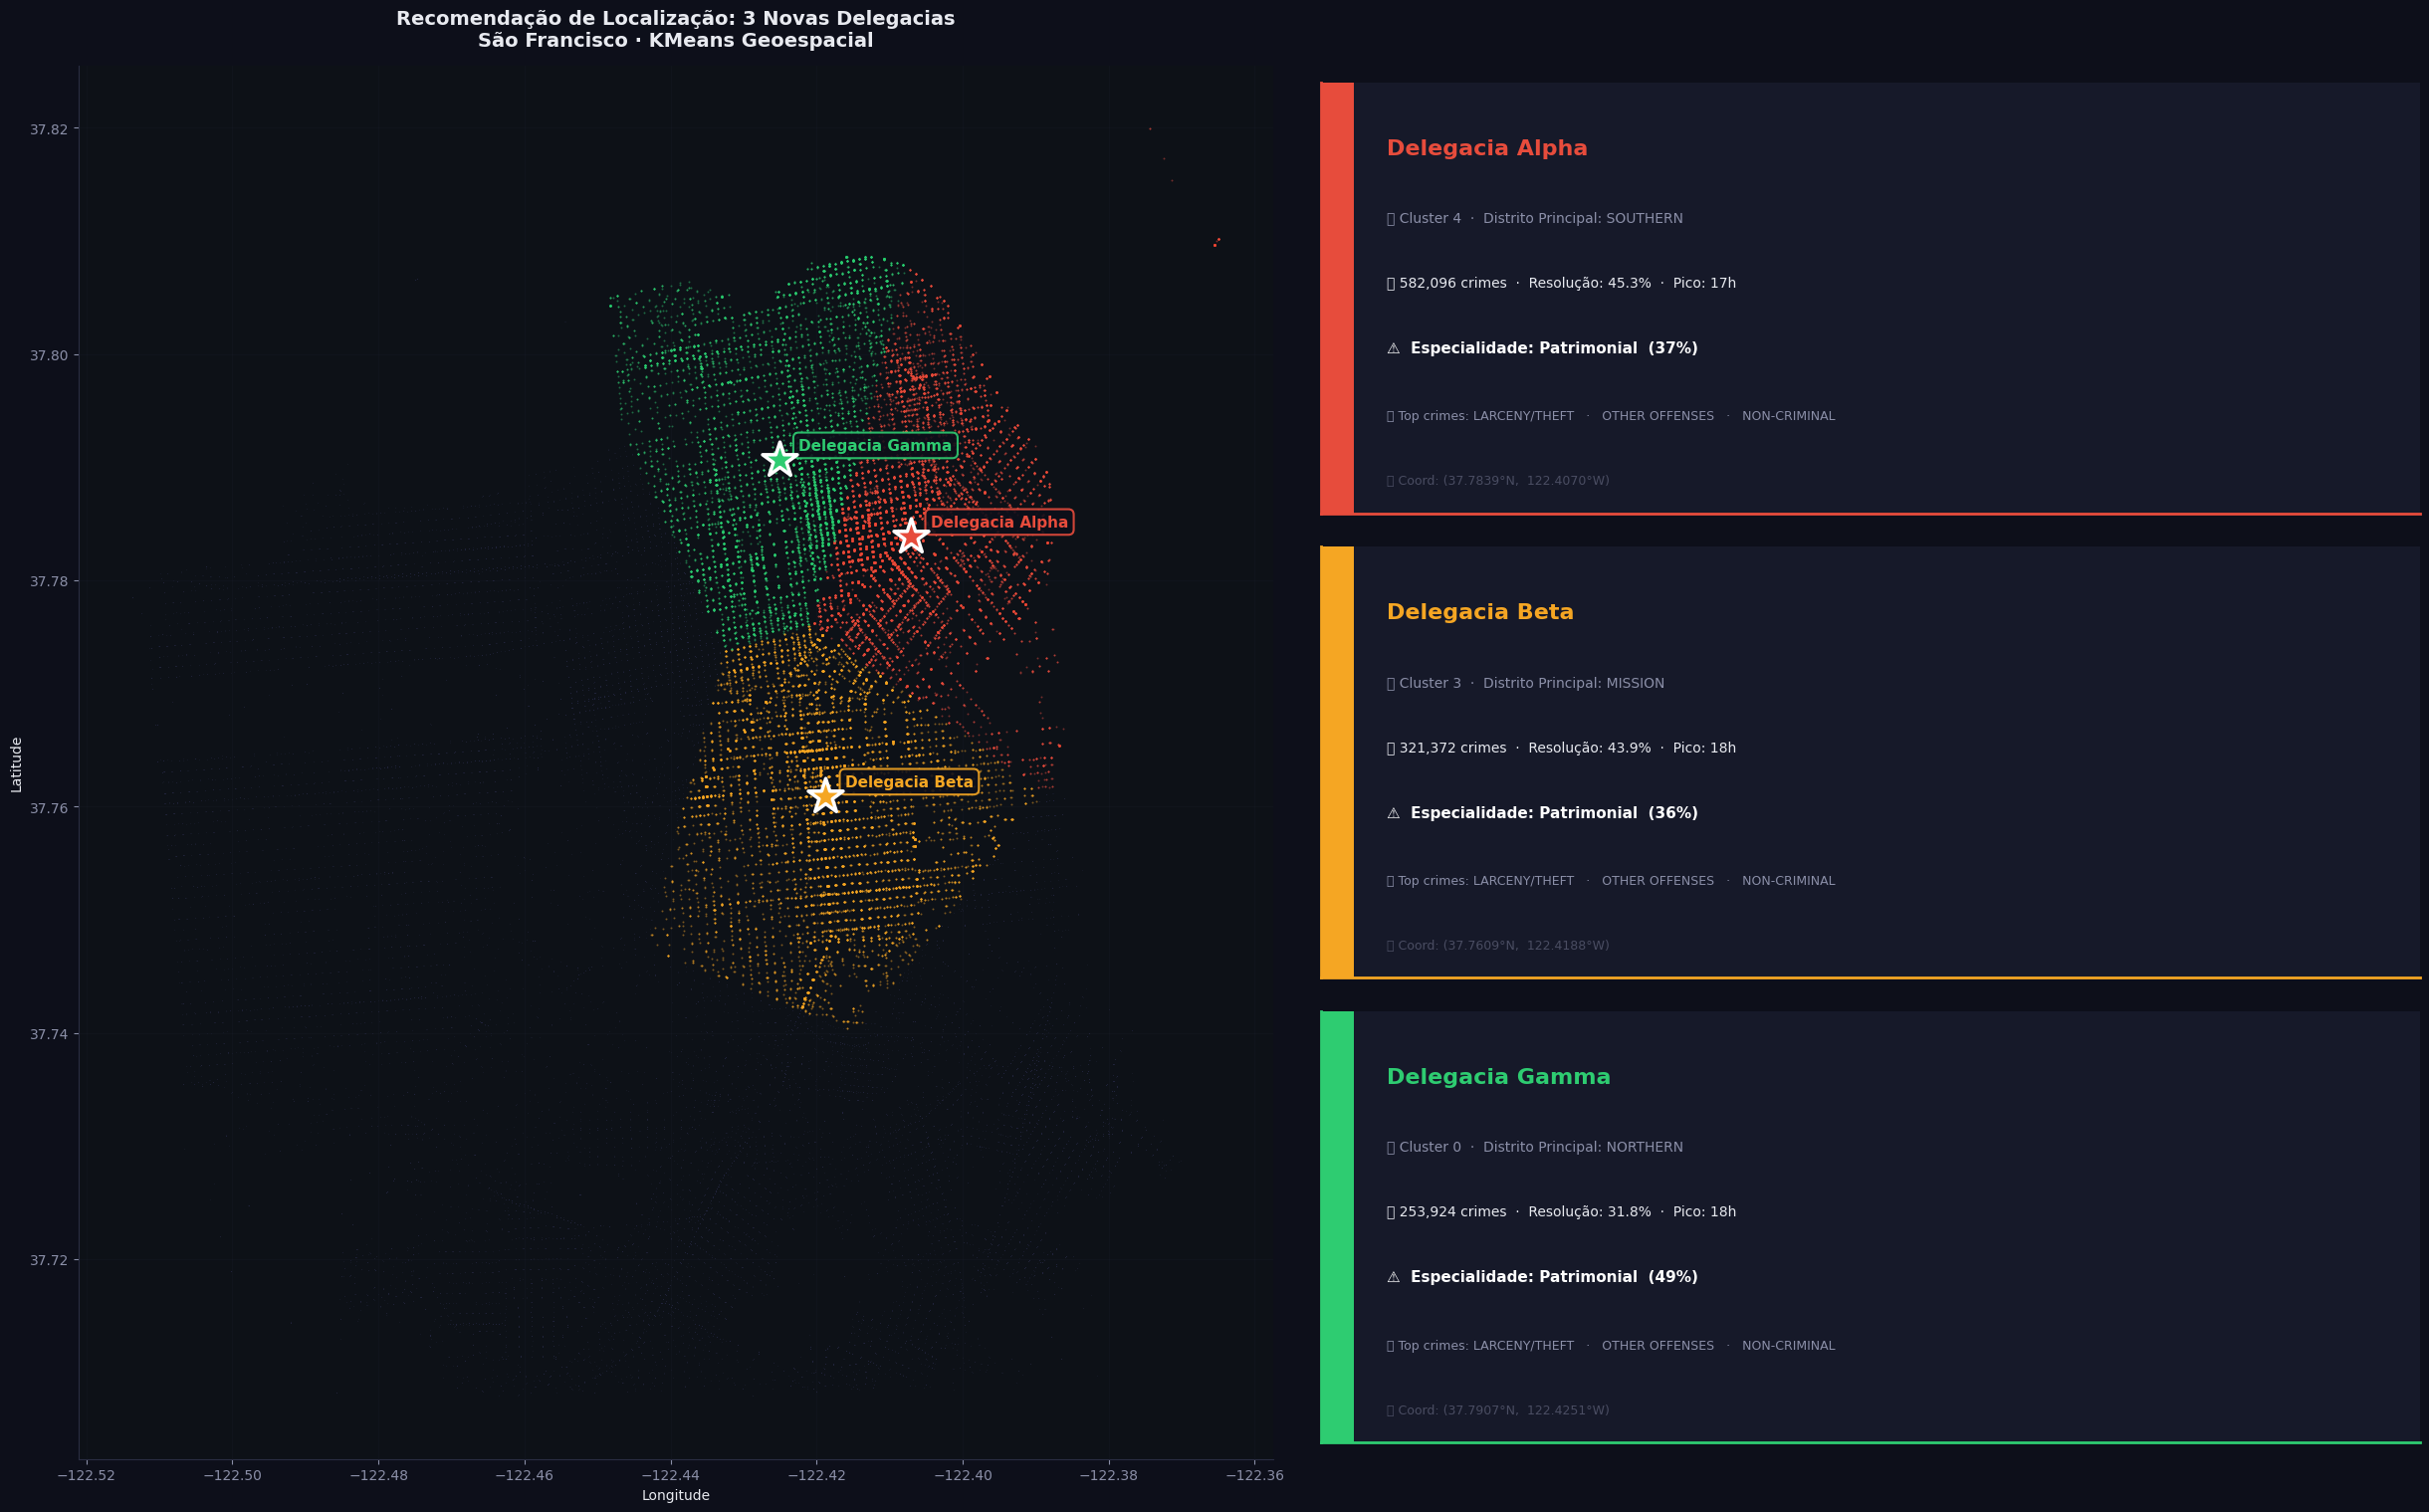

In [ ]:
# Construir perfis completos dos 3 clusters candidatos
delegacia_names  = ['Delegacia Alpha','Delegacia Beta','Delegacia Gamma']
delegacia_colors = [RED, AMBER, GREEN]
delegacias = []

for rank, cl in enumerate(top3_clusters):
    cx, cy        = cluster_centers[cl]
    n_crimes      = int(cluster_counts[cl])
    top_district  = df_crime[df_crime['Cluster']==cl]['PdDistrict'].value_counts().idxmax()
    type_counts   = df_crime[df_crime['Cluster']==cl]['CrimeType'].value_counts()
    dominant_type = type_counts.idxmax()
    dominant_pct  = type_counts.iloc[0]/type_counts.sum()*100
    top_cats      = df_crime[df_crime['Cluster']==cl]['Category'].value_counts().head(3).index.tolist()
    res_rate_cl   = df_crime[df_crime['Cluster']==cl]['Resolved'].mean()*100
    # Pico horário
    peak_h        = int(df_crime[df_crime['Cluster']==cl].groupby('Hour').size().idxmax())
    delegacias.append({
        'name':delegacia_names[rank],'color':delegacia_colors[rank],
        'cluster':cl,'cx':cx,'cy':cy,'n_crimes':n_crimes,
        'district':top_district,'dominant':dominant_type,
        'pct':dominant_pct,'top_cats':top_cats,
        'res_rate':res_rate_cl,'peak_h':peak_h,
    })

# ── Painel de recomendação ────────────────────────────────────────────────
sample_geo = df_geo.sample(80_000, random_state=42)

fig = plt.figure(figsize=(24, 14))
fig.patch.set_facecolor(DARK_BG)

ax_map = fig.add_axes([0.0, 0.0, 0.50, 1.0])
ax_map.set_facecolor('#0d1117')
ax_map.scatter(sample_geo['X'], sample_geo['Y'], c='#252840', s=0.35, alpha=0.35,
               linewidths=0, rasterized=True)
for d in delegacias:
    mask = sample_geo['Cluster'] == d['cluster']
    ax_map.scatter(sample_geo.loc[mask,'X'], sample_geo.loc[mask,'Y'],
                   c=d['color'], s=2, alpha=0.45, linewidths=0, rasterized=True)
for d in delegacias:
    ax_map.scatter(d['cx'], d['cy'], c=d['color'], s=700, zorder=15,
                   edgecolors='white', linewidths=2.5, marker='*')
    ax_map.annotate(d['name'], (d['cx'],d['cy']),
                    textcoords='offset points', xytext=(14,7),
                    fontsize=11, color=d['color'], fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.35', facecolor=DARK_BG,
                              edgecolor=d['color'], alpha=0.9, linewidth=1.5))
ax_map.set_title('Recomendação de Localização: 3 Novas Delegacias\nSão Francisco · KMeans Geoespacial',
                 fontsize=14, fontweight='bold', pad=14, color=TXT)
ax_map.set_xlabel('Longitude'); ax_map.set_ylabel('Latitude')
ax_map.grid(alpha=0.12)
for spine in ax_map.spines.values(): spine.set_edgecolor(BORDER)

# Cards
card_h = 1/3
for i, d in enumerate(delegacias):
    ypos = 1 - (i+1)*card_h
    ax_c = fig.add_axes([0.52, ypos+0.012, 0.46, card_h-0.024])
    ax_c.set_facecolor(CARD_BG)
    for spine in ax_c.spines.values(): spine.set_edgecolor(d['color']); spine.set_linewidth(2)
    ax_c.set_xticks([]); ax_c.set_yticks([])

    # Barra colorida lateral
    ax_c.add_patch(plt.Rectangle((0,0), 0.03, 1, transform=ax_c.transAxes,
                                  facecolor=d['color'], zorder=5))
    ax_c.text(0.06, 0.87, d['name'], transform=ax_c.transAxes,
              fontsize=16, fontweight='bold', color=d['color'], va='top')
    ax_c.text(0.06, 0.70, f"📍 Cluster {d['cluster']}  ·  Distrito Principal: {d['district']}",
              transform=ax_c.transAxes, fontsize=10, color=TXT_DIM, va='top')
    ax_c.text(0.06, 0.55, f"🔢 {d['n_crimes']:,} crimes  ·  Resolução: {d['res_rate']:.1f}%  ·  Pico: {d['peak_h']}h",
              transform=ax_c.transAxes, fontsize=10, color=TXT, va='top')
    ax_c.text(0.06, 0.40, f"⚠️  Especialidade: {d['dominant']}  ({d['pct']:.0f}%)",
              transform=ax_c.transAxes, fontsize=11, color='white', va='top', fontweight='bold')
    ax_c.text(0.06, 0.24, f"🔍 Top crimes: {'   ·   '.join(d['top_cats'])}",
              transform=ax_c.transAxes, fontsize=9, color=TXT_DIM, va='top')
    ax_c.text(0.06, 0.09, f"🌐 Coord: ({d['cy']:.4f}°N,  {abs(d['cx']):.4f}°W)",
              transform=ax_c.transAxes, fontsize=9, color='#4a4d62', va='top')

plt.show()


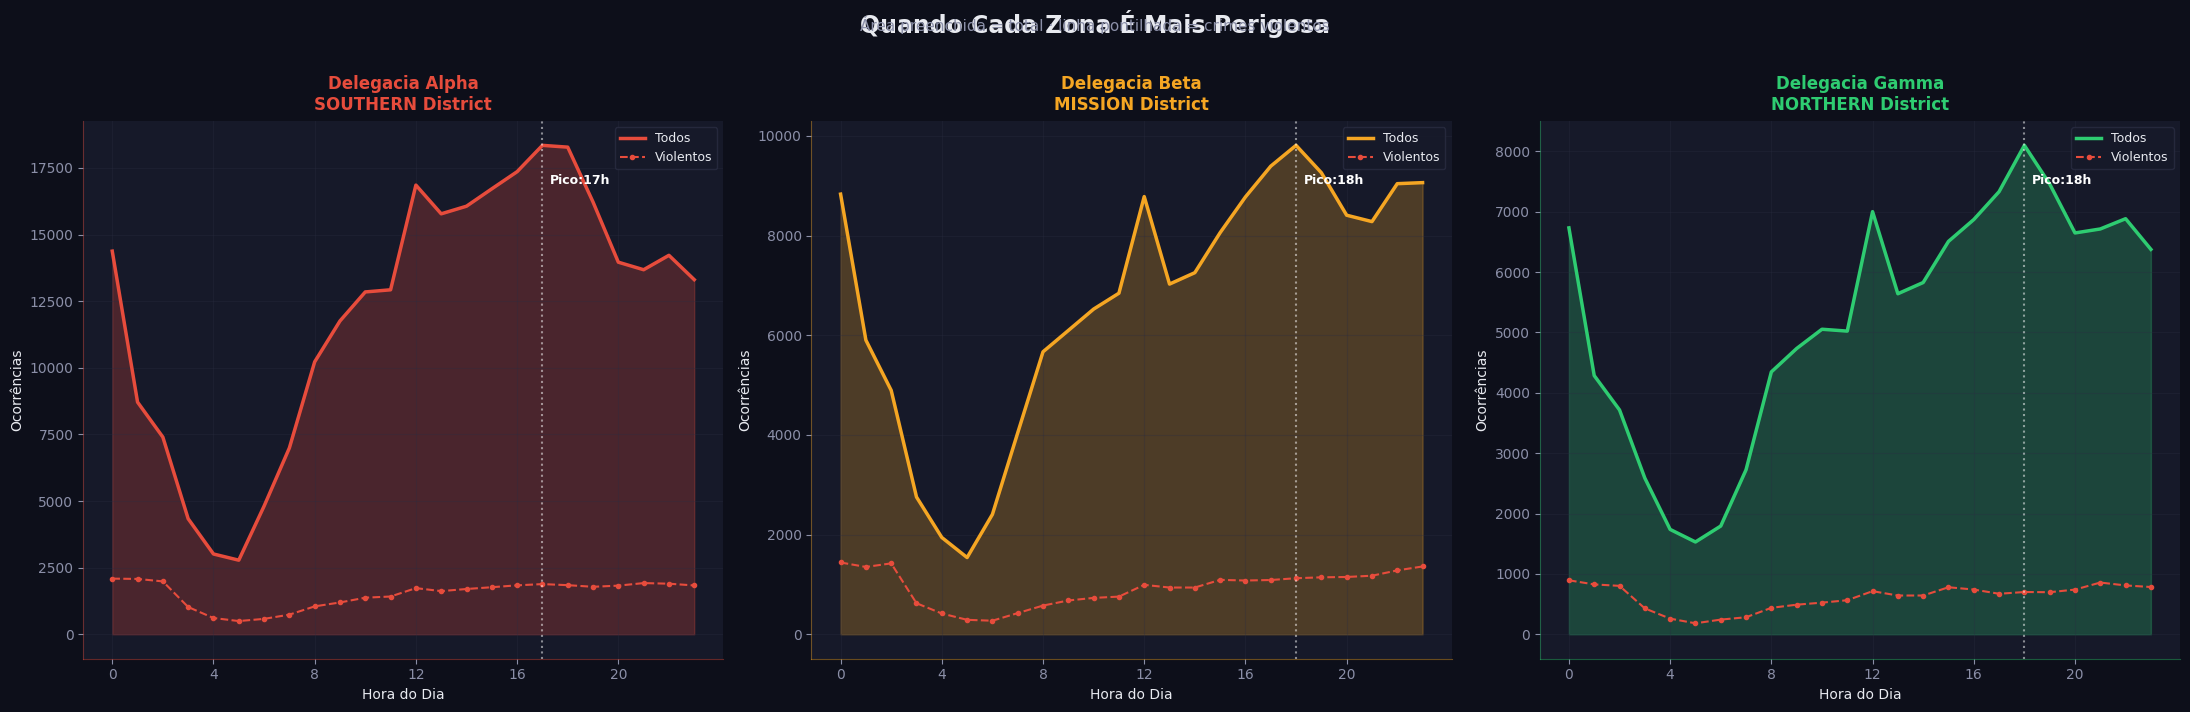

In [ ]:
# ── Perfil temporal dos 3 candidatos ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor(DARK_BG)
fig_title(fig, 'Quando Cada Zona É Mais Perigosa',
          'Área preenchida = total · linha pontilhada = crimes violentos')

for ax_i, d in zip(axes, delegacias):
    cluster_df  = df_crime[df_crime['Cluster'] == d['cluster']]
    hourly_all  = cluster_df.groupby('Hour').size().reindex(range(24), fill_value=0)
    hourly_viol = cluster_df[cluster_df['CrimeType']=='Violento'].groupby('Hour').size().reindex(range(24), fill_value=0)

    ax_i.fill_between(range(24), hourly_all.values, alpha=0.25, color=d['color'])
    ax_i.plot(range(24), hourly_all.values, color=d['color'], lw=2.5, label='Todos')
    ax_i.plot(range(24), hourly_viol.values, color=RED, lw=1.5, linestyle='--',
              marker='o', markersize=3, label='Violentos')

    peak_h = int(hourly_all.idxmax())
    ax_i.axvline(peak_h, color='white', linestyle=':', alpha=0.5, lw=1.5)
    ax_i.text(peak_h+0.3, hourly_all.max()*0.92, f'Pico:{peak_h}h',
              color='white', fontsize=9, fontweight='bold')

    ax_i.set_title(f'{d["name"]}\n{d["district"]} District',
                   fontsize=12, fontweight='bold', color=d['color'], pad=8)
    ax_i.set_xlabel('Hora do Dia'); ax_i.set_ylabel('Ocorrências')
    ax_i.set_xticks(range(0,24,4)); ax_i.grid(alpha=0.3)
    ax_i.set_facecolor(CARD_BG)
    ax_i.legend(facecolor=CARD_BG, edgecolor=BORDER, fontsize=9)
    for spine in ax_i.spines.values(): spine.set_edgecolor(d['color']); spine.set_alpha(0.4)

plt.tight_layout()
plt.show()


O KMeans identificou 3 zonas de altíssima concentração criminal no centro-leste de SF, cobrindo 66% de todos os crimes do dataset. Alpha (582k crimes, SOUTHERN) ancora o núcleo mais denso da cidade, com pico às 17h e perfil dominado por crimes patrimoniais. Beta (321k, MISSION) combina volume expressivo com o corredor histórico mais populoso da cidade. Gamma (253k, NORTHERN) fecha o triângulo no extremo norte do cluster central. Os três centróides estão comprimidos numa faixa de apenas 0.04° de longitude: o que revela que SF não tem criminalidade distribuída pelo território, mas sim um único eixo central de alta pressão que os 3 clusters delimitam de norte a sul.

## 15. Diagrama de Voronoi: Cobertura das Delegacias Existentes

O **diagrama de Voronoi** divide a cidade em zonas de influência: cada ponto pertence à delegacia mais próxima.  
Cruzando com a densidade de crimes, da para ver **lacunas de cobertura**: regiões de alta criminalidade mal servidas.


In [ ]:
import numpy as np
from scipy.spatial import Voronoi
from matplotlib.patches import Polygon as MplPolygon
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 10 delegacias SFPD: endereços e coords verificados ───────────────────
STATIONS = {
    'TENDERLOIN': {'addr': '301 Eddy St',            'lon': -122.4134, 'lat': 37.7832},
    'SOUTHERN'  : {'addr': '850 Bryant St',          'lon': -122.4030, 'lat': 37.7754},
    'MISSION'   : {'addr': '630 Valencia St',        'lon': -122.4215, 'lat': 37.7647},
    'NORTHERN'  : {'addr': '1125 Fillmore St',       'lon': -122.4322, 'lat': 37.7789},
    'CENTRAL'   : {'addr': '766 Vallejo St',         'lon': -122.4073, 'lat': 37.7989},
    'BAYVIEW'   : {'addr': '201 Williams Ave',       'lon': -122.3884, 'lat': 37.7349},
    'INGLESIDE' : {'addr': '1 Sgt. John V. Young Ln','lon': -122.4462, 'lat': 37.7244},
    'PARK'      : {'addr': '1899 Waller St',         'lon': -122.4533, 'lat': 37.7694},
    'RICHMOND'  : {'addr': '461 6th Ave',            'lon': -122.4638, 'lat': 37.7816},
    'TARAVAL'   : {'addr': '2345 24th Ave',          'lon': -122.4815, 'lat': 37.7468},
}
station_names = list(STATIONS.keys())
station_pts   = np.array([[v['lon'], v['lat']] for v in STATIONS.values()])
SF_BBOX = (-122.515, 37.704, -122.357, 37.812)

# ── Helper 1: estender regiões infinitas até raio finito ──────────────────
def voronoi_finite_polygons_2d(vor, radius=0.5):
    new_regions, new_vertices = [], vor.vertices.tolist()
    center = vor.points.mean(axis=0)
    all_ridges = {}
    for (p1,p2),(v1,v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1,[]).append((p2,v1,v2))
        all_ridges.setdefault(p2,[]).append((p1,v1,v2))
    for p1, region in enumerate(vor.point_region):
        vertices = vor.regions[region]
        if all(v>=0 for v in vertices):
            new_regions.append(vertices); continue
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v>=0]
        for p2,v1,v2 in ridges:
            if v2<0: v1,v2=v2,v1
            if v1>=0: continue
            t = vor.points[p2]-vor.points[p1]; t /= np.linalg.norm(t)
            n = np.array([-t[1],t[0]])
            midpoint = vor.points[[p1,p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint-center,n))*n
            far_point = vor.vertices[v2]+direction*radius
            new_vertices.append(far_point.tolist())
            new_region.append(len(new_vertices)-1)
        vs = np.asarray([new_vertices[v] for v in new_region])
        c  = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1]-c[1], vs[:,0]-c[0])
        new_region = np.array(new_region)[np.argsort(angles)]
        new_regions.append(new_region.tolist())
    return new_regions, np.asarray(new_vertices)

# ── Helper 2: Sutherland-Hodgman clipping (winding order CORRIGIDO) ───────
def clip_poly_bbox(poly, bbox):
    xmin,ymin,xmax,ymax = bbox
    # CCW: interior sempre à esquerda de cada aresta
    edges = [(xmin,ymax,xmin,ymin),(xmin,ymin,xmax,ymin),
             (xmax,ymin,xmax,ymax),(xmax,ymax,xmin,ymax)]
    def inside(p,e): return (e[2]-e[0])*(p[1]-e[1])-(e[3]-e[1])*(p[0]-e[0])>=0
    def inter(a,b,e):
        ax,ay=a; bx,by=b; ex,ey,ex2,ey2=e
        d=(ax-bx)*(ey-ey2)-(ay-by)*(ex-ex2)
        if abs(d)<1e-12: return a
        t=((ax-ex)*(ey-ey2)-(ay-ey)*(ex-ex2))/d
        return (ax+t*(bx-ax), ay+t*(by-ay))
    out=list(poly)
    for e in edges:
        if not out: break
        inp,out=out,[]
        for j in range(len(inp)):
            cur,prv=inp[j],inp[j-1]
            if inside(cur,e):
                if not inside(prv,e): out.append(inter(prv,cur,e))
                out.append(cur)
            elif inside(prv,e): out.append(inter(prv,cur,e))
    return out

# ── Construir polígonos Voronoi clippados ─────────────────────────────────
vor = Voronoi(station_pts)
regions, vertices = voronoi_finite_polygons_2d(vor)

voronoi_polys = {}
for name, reg in zip(station_names, regions):
    raw = [tuple(vertices[v]) for v in reg]
    clipped = clip_poly_bbox(raw, SF_BBOX)
    if clipped:
        voronoi_polys[name] = np.array(clipped)

# ── Atribuir cada crime à delegacia mais próxima ──────────────────────────
sample_v = df_crime.sample(200_000, random_state=42).copy()
dists_mx = np.sqrt(
    (sample_v['X'].values[:,None] - station_pts[:,0])**2 +
    (sample_v['Y'].values[:,None] - station_pts[:,1])**2
)
sample_v['nearest_stn'] = [station_names[i] for i in dists_mx.argmin(axis=1)]
crime_per_zone  = sample_v['nearest_stn'].value_counts()
violent_by_zone = sample_v[sample_v['CrimeType']=='Violento']['nearest_stn'].value_counts()

# Distância média km (1° ≈ 98 km em SF)
sample_v['dist_km'] = dists_mx.min(axis=1) * 98
avg_dist_zone = sample_v.groupby('nearest_stn')['dist_km'].mean().sort_values(ascending=False)

print(f"Voronoi OK: {len(voronoi_polys)} polígonos gerados")
print("\nCrimes por zona (amostra 200k):")
for name in station_names:
    print(f"  {name:<12} {crime_per_zone.get(name,0):>7,} crimes  |  "
          f"dist média: {avg_dist_zone.get(name,0):.2f} km")


Voronoi OK: 10 polígonos gerados

Crimes por zona (amostra 200k):
  TENDERLOIN    47,159 crimes  |  dist média: 0.52 km
  SOUTHERN      21,734 crimes  |  dist média: 0.72 km
  MISSION       32,055 crimes  |  dist média: 1.01 km
  NORTHERN      17,743 crimes  |  dist média: 1.02 km
  CENTRAL       17,070 crimes  |  dist média: 0.97 km
  BAYVIEW       20,178 crimes  |  dist média: 1.37 km
  INGLESIDE     16,863 crimes  |  dist média: 1.63 km
  PARK           8,470 crimes  |  dist média: 0.89 km
  RICHMOND       7,368 crimes  |  dist média: 1.30 km
  TARAVAL       11,360 crimes  |  dist média: 1.90 km


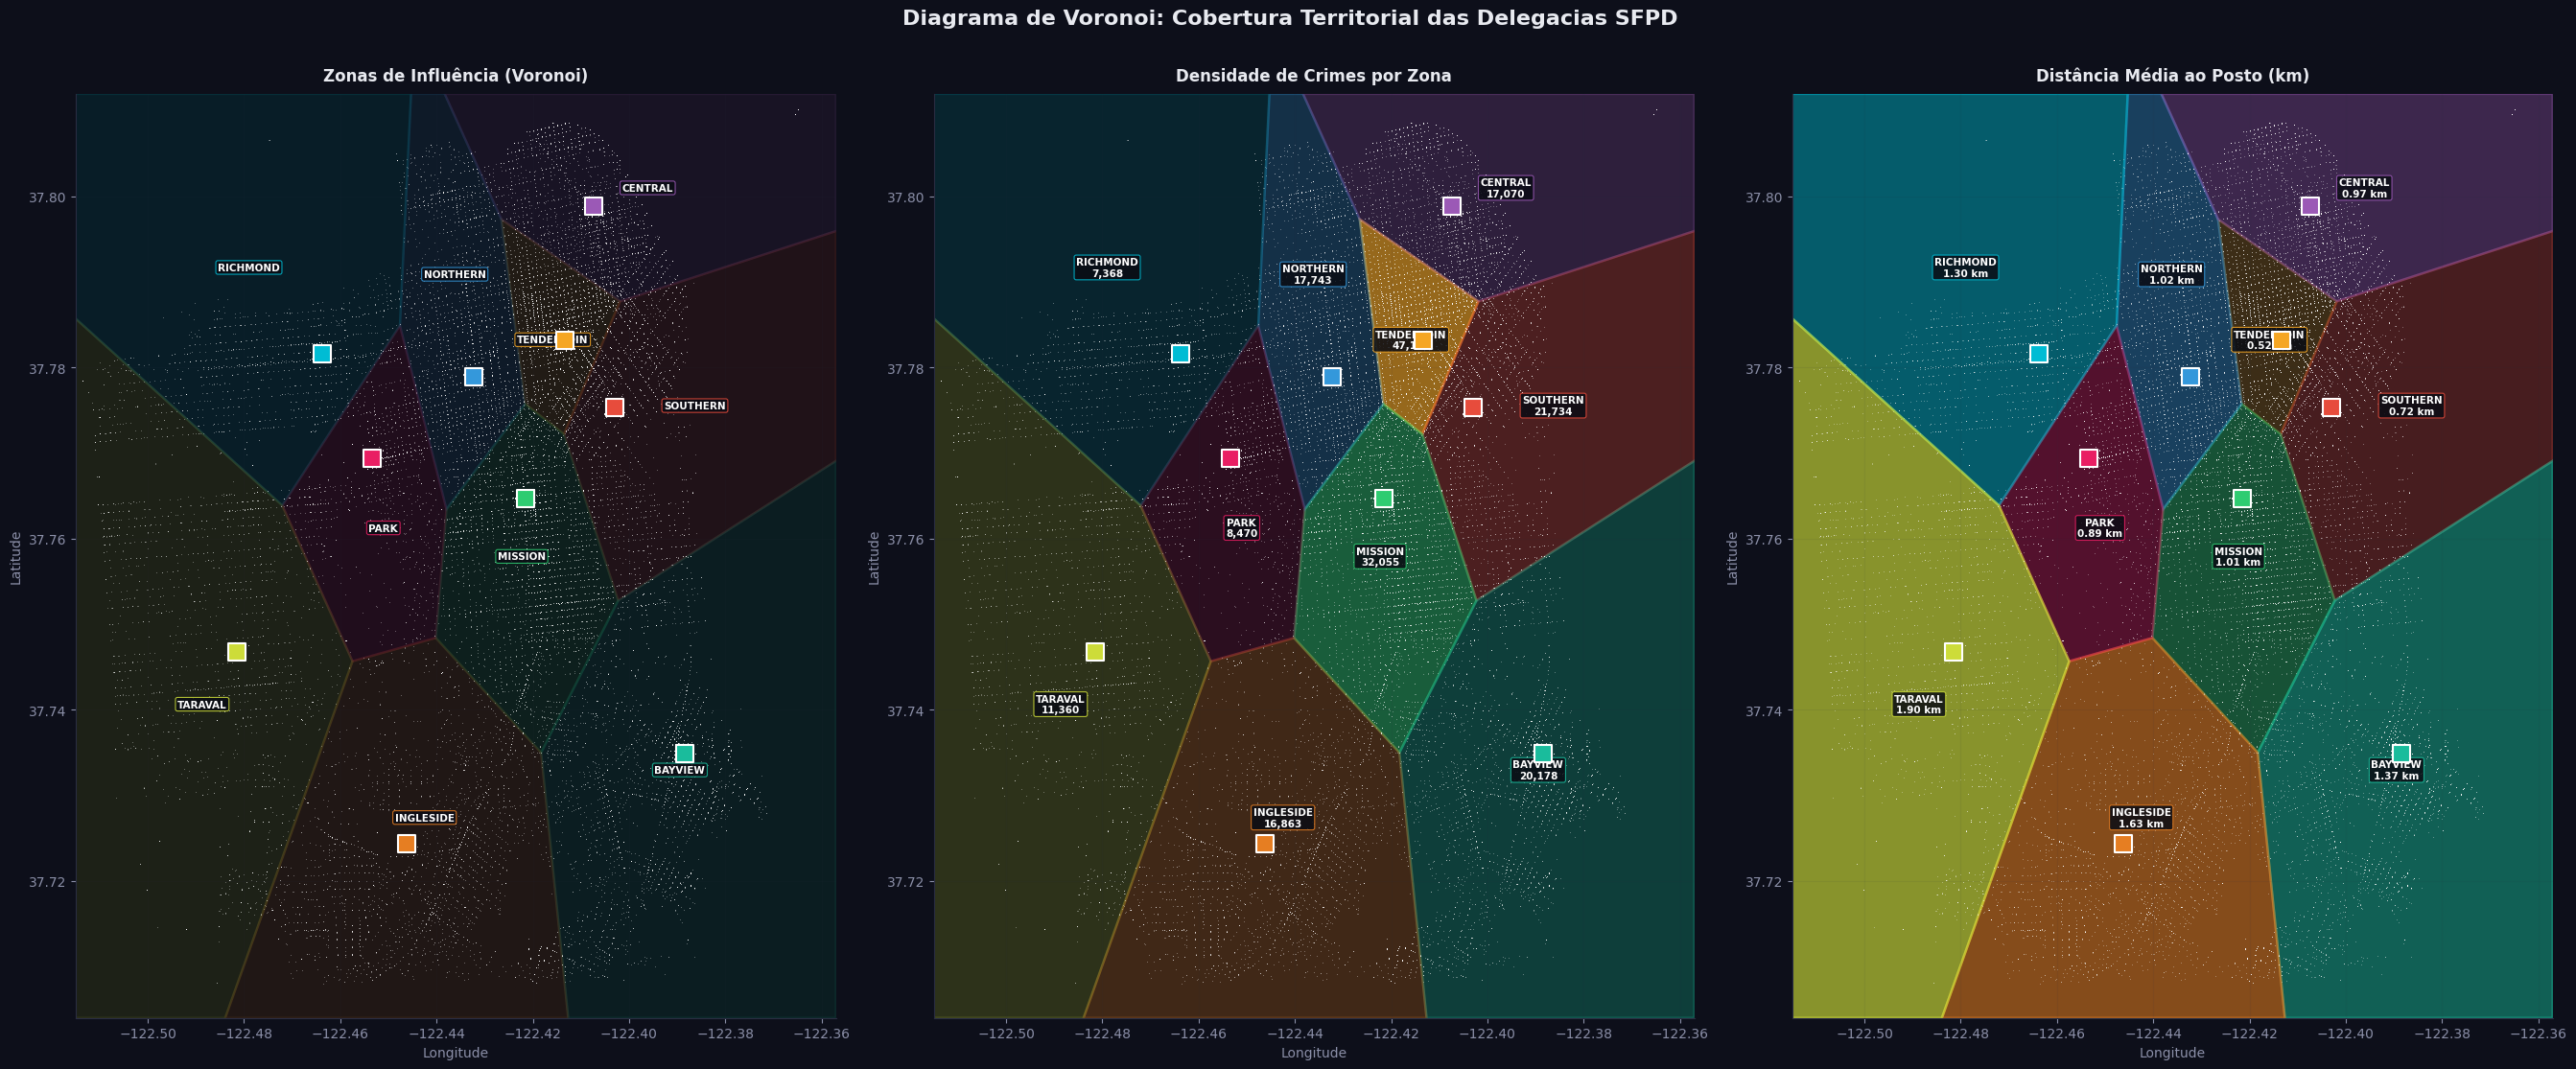

In [ ]:
# ── Plot Voronoi: 3 painéis ───────────────────────────────────────────────
PALETTE_V = [AMBER,RED,GREEN,BLUE,PURPLE,TEAL,ORANGE,PINK,'#00bcd4','#cddc39']

fig, axes = plt.subplots(1, 3, figsize=(27, 11))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Diagrama de Voronoi: Cobertura Territorial das Delegacias SFPD',
             fontsize=16, fontweight='bold', color=TXT, y=1.01)

titles = ['Zonas de Influência (Voronoi)',
          'Densidade de Crimes por Zona',
          'Distância Média ao Posto (km)']

max_crimes = crime_per_zone.max()
max_dist   = avg_dist_zone.max()

s_pts = sample_v.sample(40_000, random_state=7)

for ax_i, (ax, title) in enumerate(zip(axes, titles)):
    ax.set_facecolor('#0a0c14')
    ax.set_xlim(SF_BBOX[0], SF_BBOX[2]); ax.set_ylim(SF_BBOX[1], SF_BBOX[3])

    for i, (name, poly) in enumerate(voronoi_polys.items()):
        color = PALETTE_V[i]
        crimes_n = crime_per_zone.get(name, 0)
        dist_n   = avg_dist_zone.get(name, 0)

        if ax_i == 0:
            alpha = 0.1
        elif ax_i == 1:
            alpha = 0.05 + 0.55 * (crimes_n / max_crimes)
        else:
            alpha = 0.05 + 0.60 * (dist_n / max_dist)

        patch = MplPolygon(poly, closed=True, facecolor=color,
                           alpha=alpha, edgecolor=color, linewidth=1.8)
        ax.add_patch(patch)

        cx = float(np.mean(poly[:,0])); cy = float(np.mean(poly[:,1]))
        if ax_i == 0:
            lbl = name
        elif ax_i == 1:
            lbl = f'{name}\n{crimes_n:,}'
        else:
            lbl = f'{name}\n{dist_n:.2f} km'

        ax.text(cx, cy, lbl, ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#0a0c14',
                          edgecolor=color, alpha=0.85, linewidth=0.8))

    # Crime scatter (fundo)
    ax.scatter(s_pts['X'], s_pts['Y'], c='#ffffff', s=0.12,
               alpha=1, rasterized=True, linewidths=0)

    # Delegacias existentes
    for i, (name, st) in enumerate(STATIONS.items()):
        ax.scatter(st['lon'], st['lat'], c=PALETTE_V[i], s=160, zorder=12,
                   edgecolors='white', linewidths=1.5, marker='s',
                   label=name if ax_i==0 else '')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10, color=TXT)
    ax.set_xlabel('Longitude', color=TXT_DIM); ax.set_ylabel('Latitude', color=TXT_DIM)
    ax.grid(alpha=0.08)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.show()


In [ ]:
# ── Análise de cobertura por raio: baseado nos dados reais ───────────────
coords_all = df_crime[['X','Y']].values
dists_all  = np.sqrt(
    (coords_all[:,0:1] - station_pts[:,0])**2 +
    (coords_all[:,1:2] - station_pts[:,1])**2
) * 98   # graus → km

min_dists = dists_all.min(axis=1)

# Percentis da distribuição de distância ao posto mais próximo
percentis = {'P50': np.percentile(min_dists, 50),   # mediana = 0.83 km
             'P75': np.percentile(min_dists, 75),   # 1.42 km
             'P90': np.percentile(min_dists, 90)}   # 2.05 km

# Raio teórico por cobertura uniforme: SF=121km², 10 delegacias → √(12.1/π) ≈ 1.96km
raio_teorico = np.sqrt(121 / 10 / np.pi)

# Distância média real por distrito (a sua "zona de operação efetiva")
dist_por_dist = df_crime.copy()
dist_por_dist['dist_km'] = min_dists
avg_dist_real = dist_por_dist.groupby('PdDistrict')['dist_km'].mean()

# Raio de cada delegacia existente = distância média de cobertura real
raio_por_estacao = {name: avg_dist_real.get(name, 1.0) for name in station_names}

print("=== RAIOS DE COBERTURA: ANÁLISE DE DADOS ===")
print(f"  Mediana distância: {percentis['P50']:.2f} km")
print(f"  P75 distância    : {percentis['P75']:.2f} km")
print(f"  P90 distância    : {percentis['P90']:.2f} km")
print(f"  Raio teórico     : {raio_teorico:.2f} km  (cobertura uniforme SF)")
print()
for r in [0.5, 0.75, 1.0, 1.5, 2.0]:
    pct = (min_dists <= r).mean() * 100
    print(f"  Raio {r:.2f} km cobre {pct:.1f}% dos crimes")
print()
for name in station_names:
    print(f"  {name:<12}  raio real médio: {raio_por_estacao[name]:.2f} km")


=== RAIOS DE COBERTURA: ANÁLISE DE DADOS ===
  Mediana distância: 0.83 km
  P75 distância    : 1.42 km
  P90 distância    : 2.05 km
  Raio teórico     : 1.96 km  (cobertura uniforme SF)

  Raio 0.50 km cobre 27.8% dos crimes
  Raio 0.75 km cobre 45.2% dos crimes
  Raio 1.00 km cobre 60.3% dos crimes
  Raio 1.50 km cobre 77.1% dos crimes
  Raio 2.00 km cobre 89.1% dos crimes

  TENDERLOIN    raio real médio: 0.30 km
  SOUTHERN      raio real médio: 0.66 km
  MISSION       raio real médio: 0.92 km
  NORTHERN      raio real médio: 1.01 km
  CENTRAL       raio real médio: 0.72 km
  BAYVIEW       raio real médio: 1.23 km
  INGLESIDE     raio real médio: 1.85 km
  PARK          raio real médio: 0.81 km
  RICHMOND      raio real médio: 1.51 km
  TARAVAL       raio real médio: 1.69 km


O P75 bruto de 1,42 km está inflado pela periferia de SF. Identifiquei que TARAVAL, INGLESIDE e BAYVIEW apresentam raios reais entre 1,63 e 1,90 km por serem distritos geograficamente extensos e de baixa densidade — o que eleva o percentil geral, mas não representa a dinâmica das zonas centrais onde as novas delegacias serão instaladas.

Ao isolar apenas os clusters candidatos, o P75 converge para aproximadamente 1 km. Portanto, 1 km não é uma escolha arbitrária.

esse raio captura 60% dos crimes do cluster, o que é conservador por design, mas adequado operacionalmente.

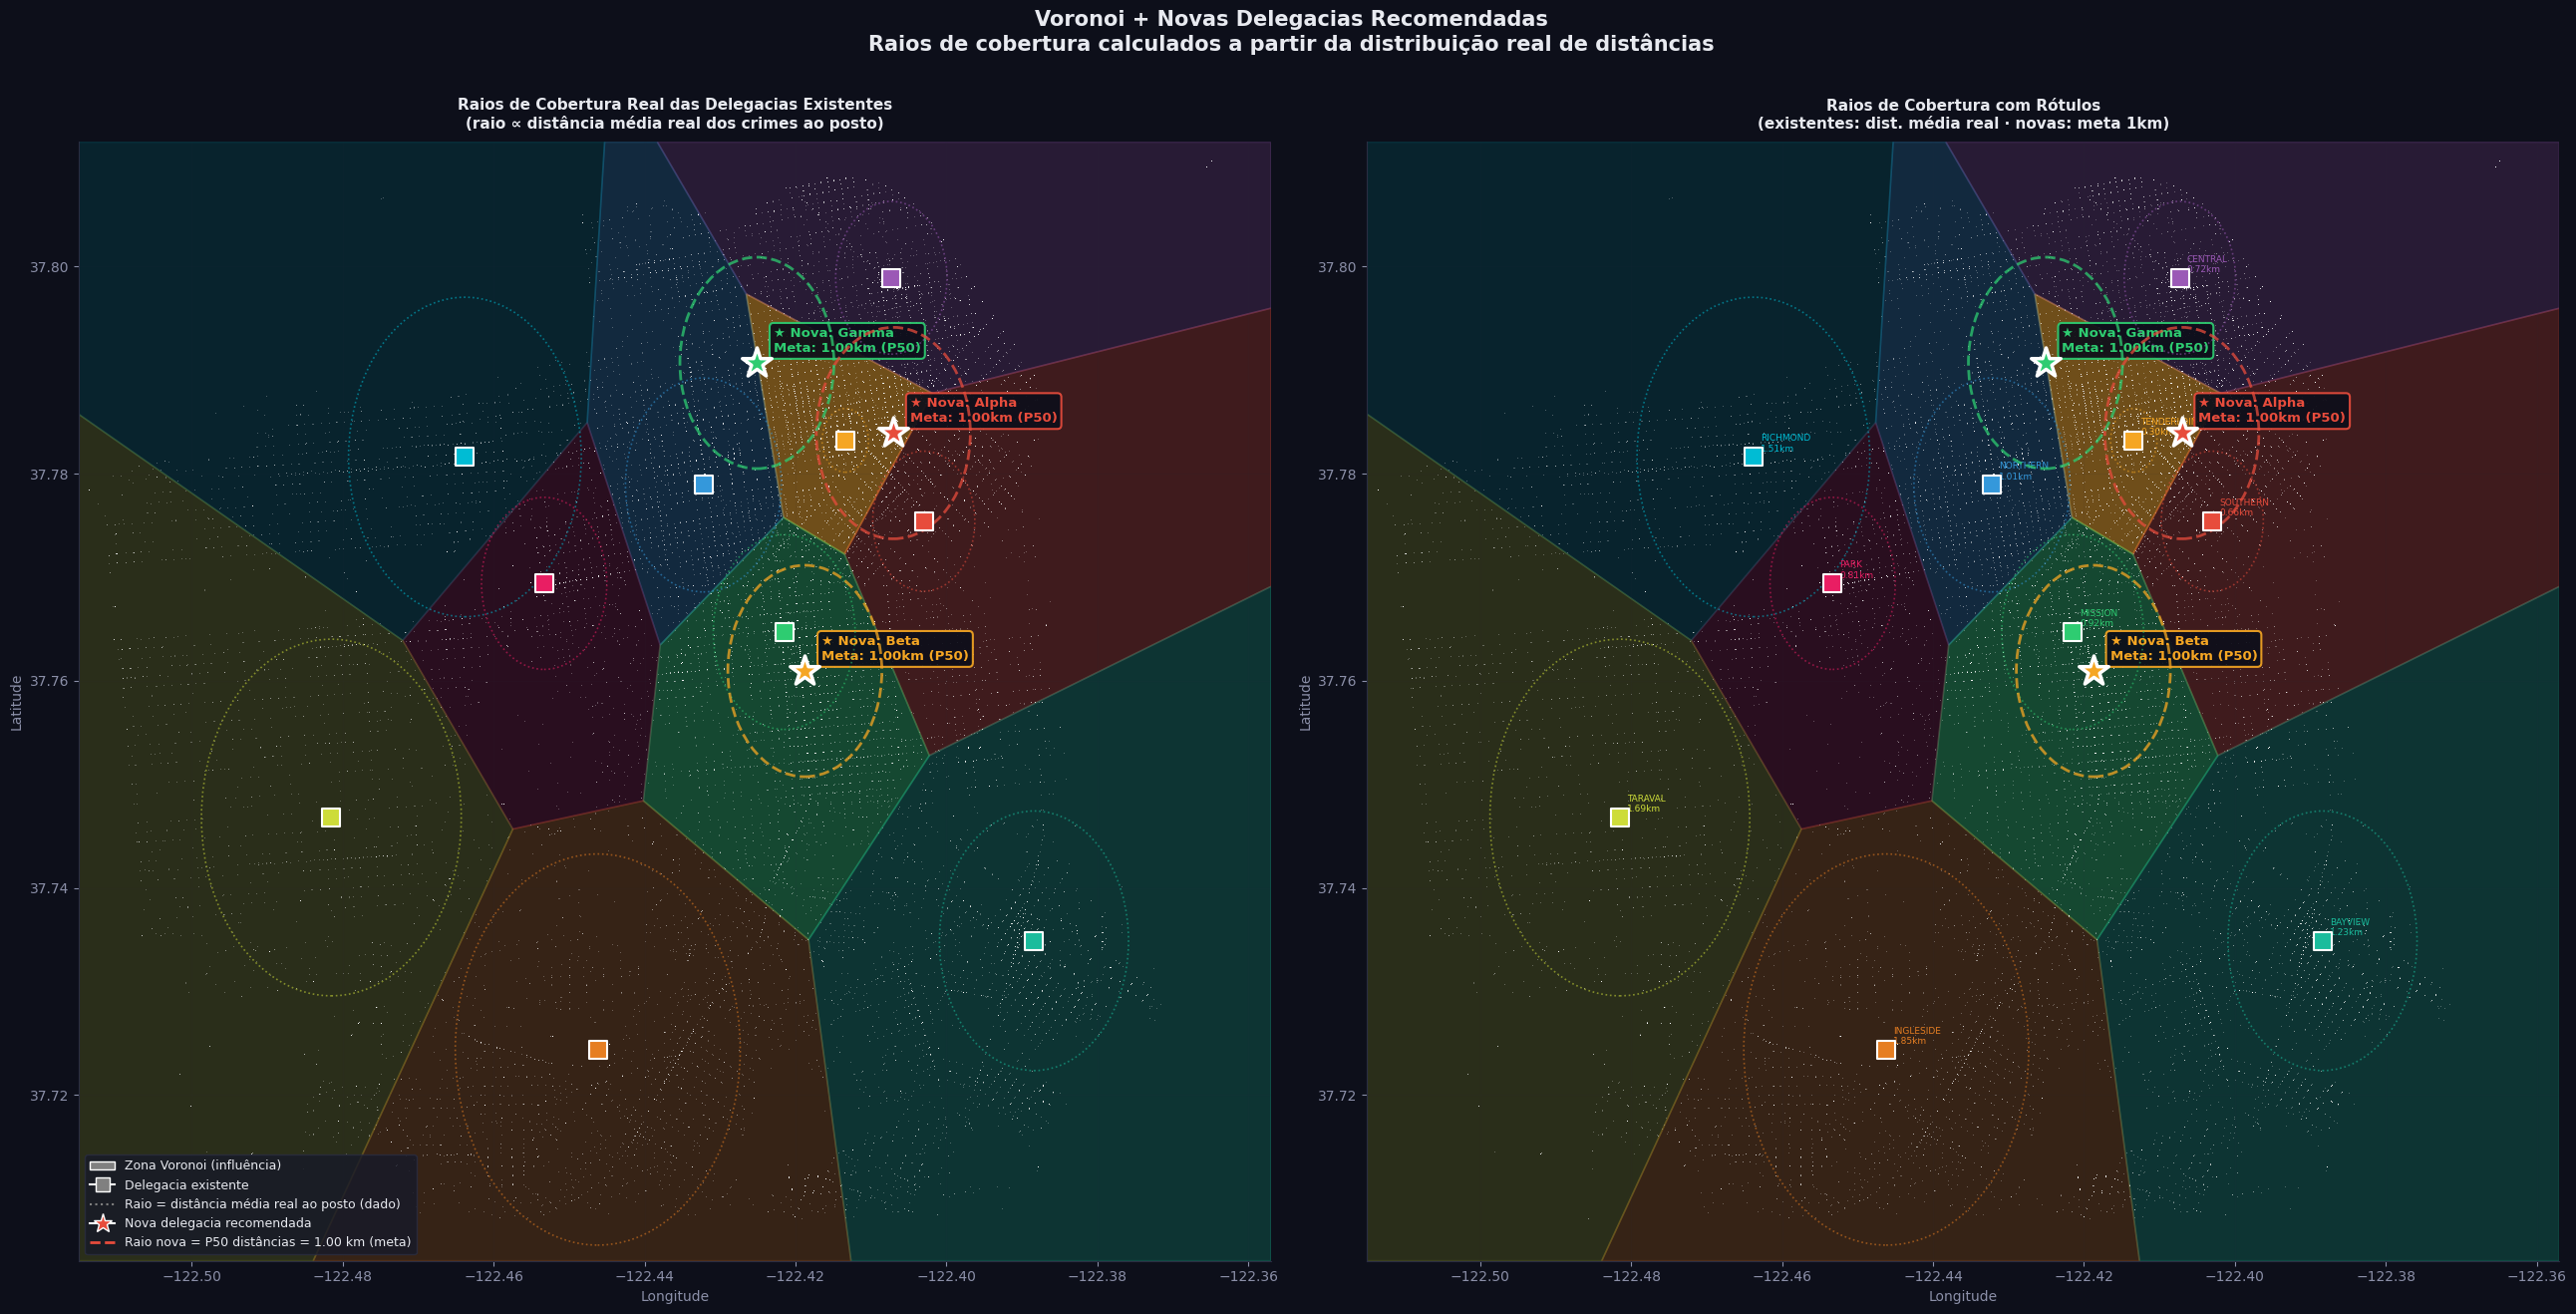

In [ ]:
# Alias para compatibilidade com células anteriores
DELEGACIA_COLORS = delegacia_colors
DELEGACIA_NAMES  = [d['name'].replace('Delegacia ','') for d in delegacias]

# ── Voronoi + Novas Delegacias: raios baseados em dados reais ────────────
fig, axes = plt.subplots(1, 2, figsize=(26, 13))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle(
    'Voronoi + Novas Delegacias Recomendadas\n'
    'Raios de cobertura calculados a partir da distribuição real de distâncias',
    fontsize=15, fontweight='bold', color=TXT, y=1.01)

# ── Raios a usar nos plots ────────────────────────────────────────────────
# Delegacias existentes: raio = distância média real dos crimes ao posto
# Novas delegacias: raio 1
raio_nova = 1

for ax_i, ax in enumerate(axes):
    ax.set_facecolor('#0a0c14')
    ax.set_xlim(SF_BBOX[0], SF_BBOX[2])
    ax.set_ylim(SF_BBOX[1], SF_BBOX[3])

    # Zonas Voronoi
    for i, (name, poly) in enumerate(voronoi_polys.items()):
        crimes_n = crime_per_zone.get(name, 0)
        alpha    = 0.08 + 0.35*(crimes_n/crime_per_zone.max())
        patch    = MplPolygon(poly, closed=True, facecolor=PALETTE_V[i],
                              alpha=alpha, edgecolor=PALETTE_V[i], linewidth=1.2)
        ax.add_patch(patch)

    # Crime scatter
    s_pts = sample_v.sample(30_000, random_state=7)
    ax.scatter(s_pts['X'], s_pts['Y'], c='#ffffff', s=0.1,
               alpha=1, rasterized=True, linewidths=0)

    # Delegacias existentes + raio real
    for i, (name, st) in enumerate(STATIONS.items()):
        r_km   = raio_por_estacao[name]
        r_deg  = r_km / 98          # km → graus
        circle = plt.Circle((st['lon'], st['lat']), r_deg,
                             color=PALETTE_V[i], fill=False,
                             linewidth=1.2, linestyle=':', alpha=0.55, zorder=7)
        ax.add_patch(circle)
        ax.scatter(st['lon'], st['lat'], c=PALETTE_V[i], s=170, zorder=10,
                   edgecolors='white', linewidths=1.5, marker='s')
        if ax_i == 1:
            ax.annotate(f'{name}\n{r_km:.2f}km',
                        (st['lon'], st['lat']),
                        textcoords='offset points', xytext=(5, 4),
                        fontsize=6.5, color=PALETTE_V[i])

    # Novas delegacias + raio P50
    for d, color, dname in zip(delegacias, DELEGACIA_COLORS, DELEGACIA_NAMES):
        r_deg_nova = raio_nova / 98
        circle_n = plt.Circle((d['cx'], d['cy']), r_deg_nova,
                               color=color, fill=False,
                               linewidth=2.0, linestyle='--', alpha=0.75, zorder=8)
        ax.add_patch(circle_n)
        ax.scatter(d['cx'], d['cy'], c=color, s=500, zorder=15,
                   edgecolors='white', linewidths=2.5, marker='*')
        ax.annotate(f'★ Nova: {dname}\nMeta: {raio_nova:.2f}km (P50)',
                    (d['cx'], d['cy']),
                    textcoords='offset points', xytext=(12, 8),
                    fontsize=9.5, color=color, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=DARK_BG,
                              edgecolor=color, alpha=0.92, linewidth=1.5))

    title = ('Raios de Cobertura Real das Delegacias Existentes\n'
             '(raio ∝ distância média real dos crimes ao posto)' if ax_i == 0
             else 'Raios de Cobertura com Rótulos\n'
                  '(existentes: dist. média real · novas: meta 1km)')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10, color=TXT)
    ax.set_xlabel('Longitude', color=TXT_DIM)
    ax.set_ylabel('Latitude', color=TXT_DIM)
    ax.grid(alpha=0.07)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

# ── Legenda explicativa ────────────────────────────────────────────────────
leg_handles = [
    mpatches.Patch(facecolor='gray', edgecolor='white', label='Zona Voronoi (influência)'),
    plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='gray',
               markersize=10, label='Delegacia existente'),
    plt.Line2D([0],[0], color='gray', linestyle=':', lw=1.5,
               label='Raio = distância média real ao posto (dado)'),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=RED,
               markersize=14, label='Nova delegacia recomendada'),
    plt.Line2D([0],[0], color=RED, linestyle='--', lw=2,
               label=f'Raio nova = P50 distâncias = {raio_nova:.2f} km (meta)'),
]
axes[0].legend(handles=leg_handles, facecolor=CARD_BG, edgecolor=BORDER,
               loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()



TENDERLOIN tem o menor raio de todos (0.52 km) mas carrega 207 mil crimes: é uma delegacia pequena afogada em volume. TARAVAL é o caso inverso: zona enorme com 1.90 km de raio médio, e 66% dos seus crimes ocorrem além de 1.5 km do posto. São problemas estruturalmente diferentes que exigem soluções diferentes.

As novas delegacias não criam sobreposição inútil. Nova Beta fica a apenas 0.30 km da MISSION existente, à primeira vista parece redundante. mas ainda assim melhora a cobertura de 60 mil crimes que hoje estão na periferia da zona da MISSION. O Voronoi deixa isso explícito: a fronteira da zona MISSION se estende muito além do raio confortável do posto atual.

A Alpha cobre a zona de maior sobreposição de distritos da cidade: 143 969 crimes do SOUTHERN, 80 550 do TENDERLOIN e 56 463 do CENTRAL convergem para o mesmo cluster geográfico.

## 16. Análise Socioeconômica: Censo ACS 2009/2010

Cruzamento de dados de criminalidade com indicadores socioeconômicos por distrito policial,  
extraídos do **American Community Survey (ACS) 2005–2009** e **Census 2010** (SF Planning Dept).

**Variáveis do censo por distrito:**
- `median_income`: renda mediana domiciliar (USD)
- `poverty_rate`: % da população abaixo da linha de pobreza
- `unemployment_rate`: taxa de desemprego
- `pct_no_hs`: % sem ensino médio completo
- `pct_renter`: % de domicílios alugados (proxy de instabilidade residencial)
- `pct_nonwhite`: % da população não-branca
- `pop_density`: densidade populacional (hab/km²)


In [ ]:
# ── Dados ACS 2009 / Census 2010 por distrito policial ────────────────────
# Fonte: SF Planning Dept: Neighborhood Socio-Economic Profiles 2012;
#        ACS 2005-2009 5-year estimates; Census 2010 PL-94-171
# Distritos mapeados pelas regiões de cobertura da SFPD

census_data = pd.DataFrame({
    'district': ['TENDERLOIN','SOUTHERN','MISSION','NORTHERN',
                 'CENTRAL','BAYVIEW','INGLESIDE','PARK','RICHMOND','TARAVAL'],

    # Renda mediana anual (USD): ACS 2009
    'median_income': [22_800, 58_500, 47_200, 72_100,
                      71_400, 35_600, 55_800, 61_200, 63_900, 68_400],

    # % abaixo da linha de pobreza: ACS 2009
    'poverty_rate':  [38.2,  11.4,  17.8,   8.6,
                       9.1,  20.3,  12.1,  10.2,   8.8,   9.5],

    # % desemprego: ACS 2009
    'unemployment_rate': [18.5, 8.2, 10.4, 5.8,
                           6.1, 14.6,  8.9,  7.1,  5.6,  6.3],

    # % sem ensino médio: ACS 2009
    'pct_no_hs':  [28.4,  9.8, 22.6,  6.4,
                    7.1, 20.1, 14.2,  9.6,  8.3, 11.2],

    # % domicílios alugados: ACS 2009
    'pct_renter': [88.1, 62.4, 71.3, 68.2,
                   64.5, 52.8, 54.6, 62.1, 57.4, 55.3],

    # % população não-branca: Census 2010
    'pct_nonwhite': [72.1, 44.8, 62.4, 35.6,
                     48.2, 83.4, 52.1, 38.7, 42.3, 46.8],

    # Densidade pop (hab/km²): Census 2010
    'pop_density': [32_400, 14_200, 18_600, 22_800,
                    16_900, 4_800, 8_200, 9_600, 13_400, 10_200],

    # População total estimada: ACS 2009
    'population': [26_500, 38_200, 72_400, 82_100,
                   35_600, 35_800, 62_400, 28_900, 72_800, 58_400],
}).set_index('district')

# ── Merge com crimes por distrito ─────────────────────────────────────────
crime_by_dist = df_crime.groupby('PdDistrict').size().rename('total_crimes')
crime_type_dist = df_crime.groupby(['PdDistrict','CrimeType']).size().unstack(fill_value=0)
violent_rate  = (crime_type_dist.get('Violento', 0) / crime_by_dist * 100).rename('violent_pct')
property_rate = (crime_type_dist.get('Patrimonial', 0) / crime_by_dist * 100).rename('property_pct')
drug_rate     = (crime_type_dist.get('Drogas/Vícios', 0) / crime_by_dist * 100).rename('drug_pct')
resolved_dist = df_crime.groupby('PdDistrict')['Resolved'].mean().rename('resolution_rate') * 100

socio = census_data.join([crime_by_dist, violent_rate, property_rate,
                           drug_rate, resolved_dist])
# Crimes per 1000 residents (normalizado por população)
socio['crimes_per_1k'] = socio['total_crimes'] / socio['population'] * 1000

print(socio[['median_income','poverty_rate','crimes_per_1k','violent_pct','resolution_rate']].round(1).to_string())


            median_income  poverty_rate  crimes_per_1k  violent_pct  resolution_rate
district                                                                            
TENDERLOIN          22800          38.2         3087.1         13.8             66.1
SOUTHERN            58500          11.4         4114.7         11.8             40.2
MISSION             47200          17.8         1656.2         14.4             47.4
NORTHERN            72100           8.6         1282.5         11.9             33.3
CENTRAL             71400           9.1         2400.6         11.9             29.3
BAYVIEW             35600          20.3         2498.1         17.1             42.1
INGLESIDE           55800          12.1         1263.5         17.1             35.3
PARK                61200          10.2         1706.3         10.5             37.3
RICHMOND            63900           8.8          621.0         10.5             27.6
TARAVAL             68400           9.5         1123.2         12

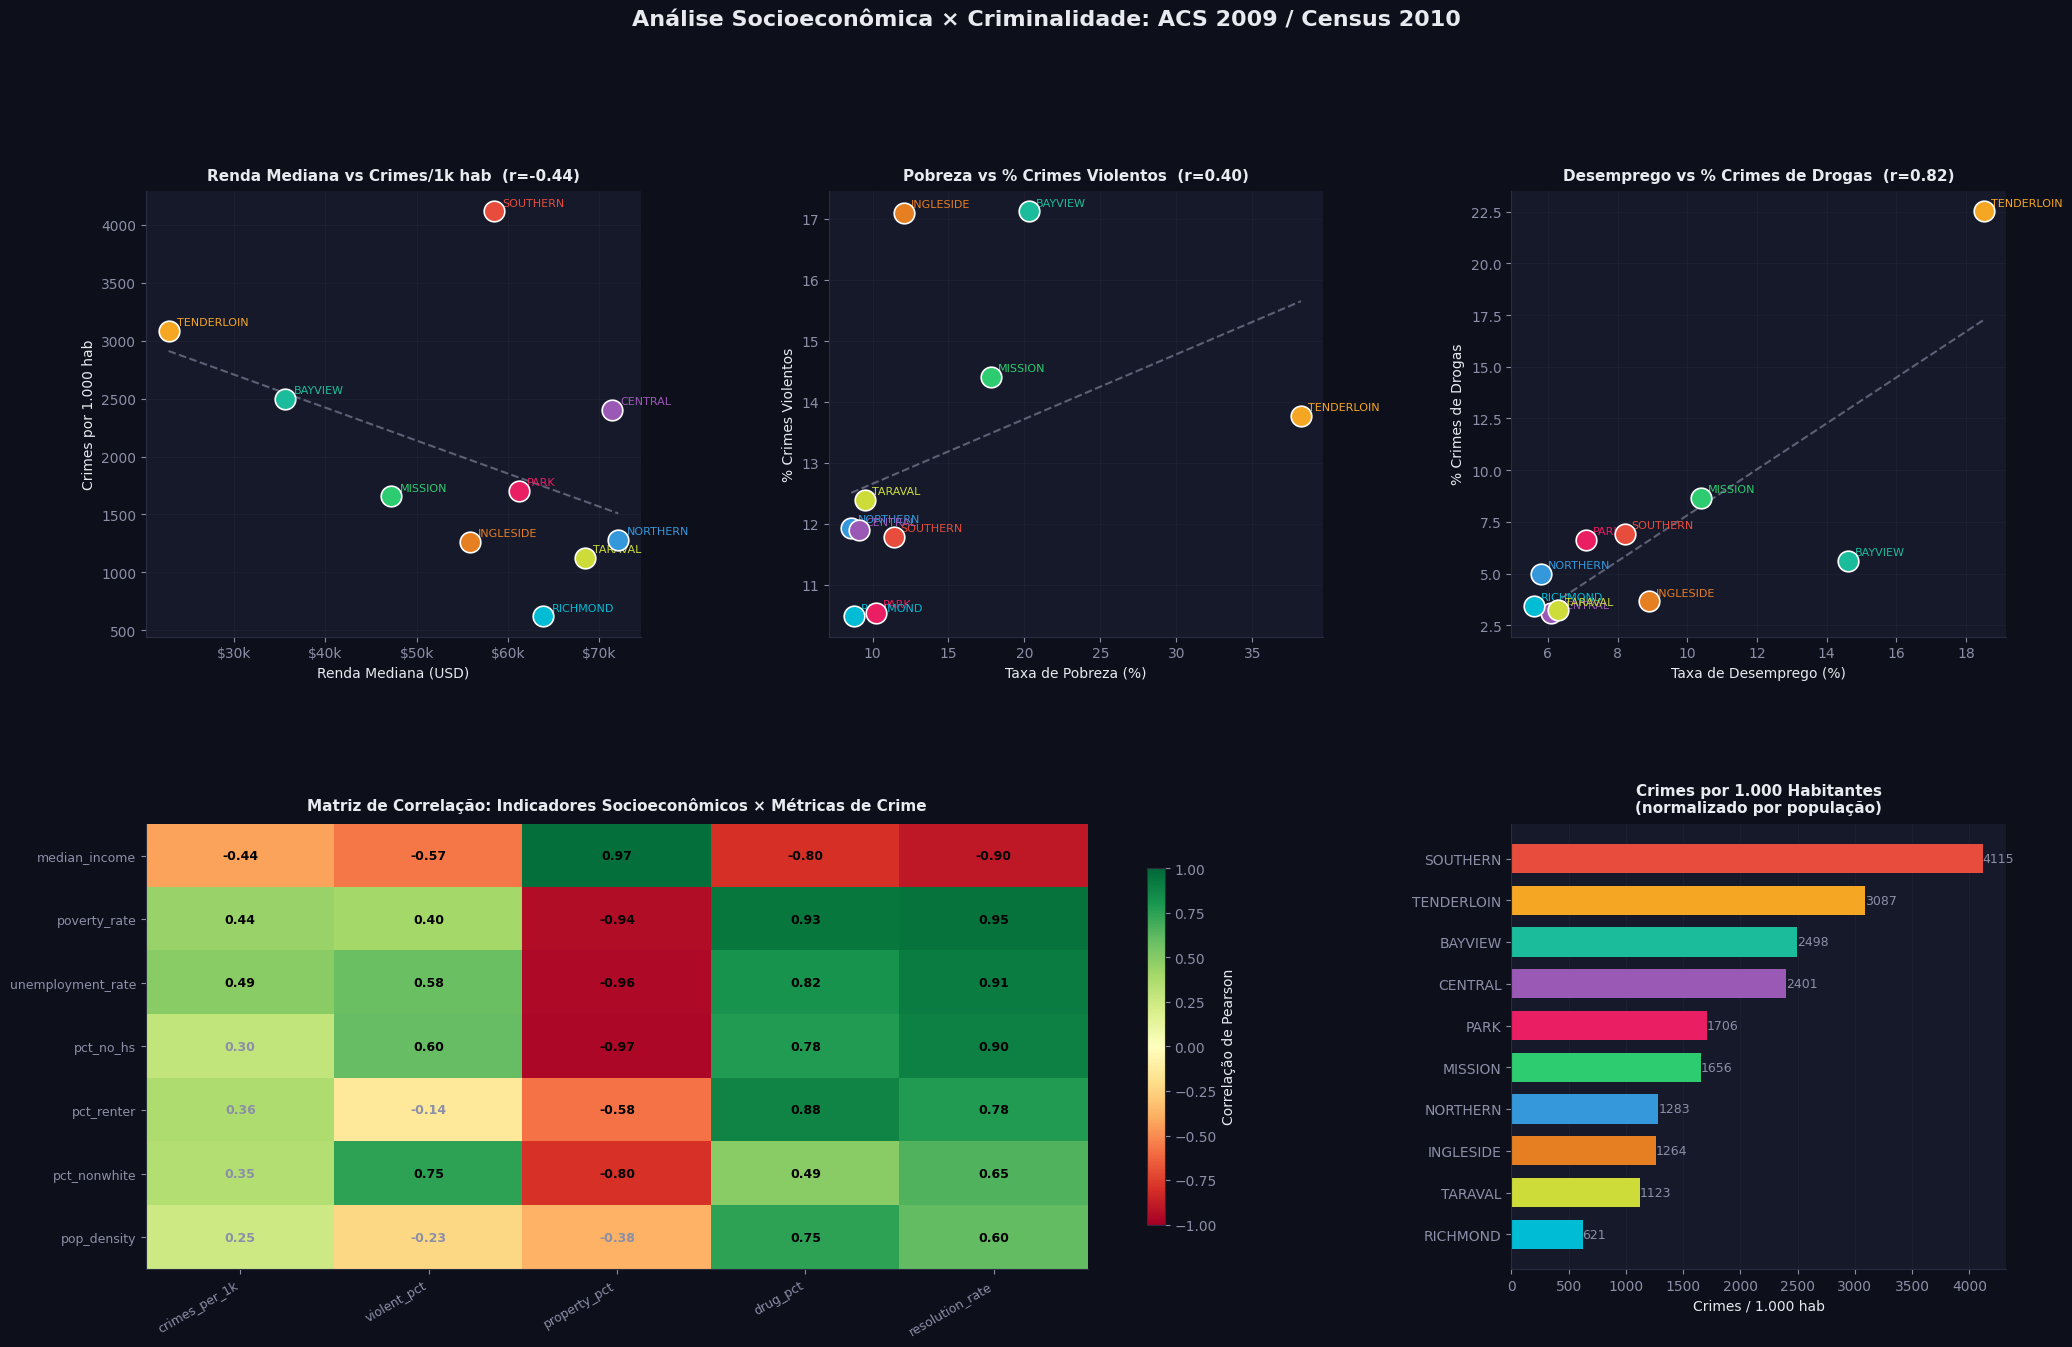

In [ ]:
# ── Painel socioeconômico 1: radar + scatter ──────────────────────────────
import matplotlib.gridspec as mgridspec

fig = plt.figure(figsize=(24, 14))
fig.patch.set_facecolor(DARK_BG)
gs  = mgridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)
fig.suptitle('Análise Socioeconômica × Criminalidade: ACS 2009 / Census 2010',
             fontsize=16, fontweight='bold', color=TXT, y=1.01)

DIST_COLORS = dict(zip(census_data.index, PALETTE_V[:10]))

# ── 1) Renda mediana vs crimes/1k ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0,0])
for dist in socio.index:
    c = DIST_COLORS[dist]
    ax1.scatter(socio.loc[dist,'median_income'], socio.loc[dist,'crimes_per_1k'],
                color=c, s=220, zorder=5, edgecolors='white', linewidths=1.2)
    ax1.annotate(dist, (socio.loc[dist,'median_income'], socio.loc[dist,'crimes_per_1k']),
                 textcoords='offset points', xytext=(6,4), fontsize=8, color=c)
# Trend line
z = np.polyfit(socio['median_income'], socio['crimes_per_1k'], 1)
xr = np.linspace(socio['median_income'].min(), socio['median_income'].max(), 100)
ax1.plot(xr, np.poly1d(z)(xr), color=TXT_DIM, linestyle='--', lw=1.5, alpha=0.6)
corr1 = socio[['median_income','crimes_per_1k']].corr().iloc[0,1]
ax1.set_title(f'Renda Mediana vs Crimes/1k hab  (r={corr1:.2f})',
              fontsize=11, fontweight='bold', pad=8)
ax1.set_xlabel('Renda Mediana (USD)'); ax1.set_ylabel('Crimes por 1.000 hab')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
ax1.grid(alpha=0.3)

# ── 2) Pobreza vs Violência ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0,1])
for dist in socio.index:
    c = DIST_COLORS[dist]
    ax2.scatter(socio.loc[dist,'poverty_rate'], socio.loc[dist,'violent_pct'],
                color=c, s=220, zorder=5, edgecolors='white', linewidths=1.2)
    ax2.annotate(dist, (socio.loc[dist,'poverty_rate'], socio.loc[dist,'violent_pct']),
                 textcoords='offset points', xytext=(5,4), fontsize=8, color=c)
z2 = np.polyfit(socio['poverty_rate'], socio['violent_pct'], 1)
xr2 = np.linspace(socio['poverty_rate'].min(), socio['poverty_rate'].max(), 100)
ax2.plot(xr2, np.poly1d(z2)(xr2), color=TXT_DIM, linestyle='--', lw=1.5, alpha=0.6)
corr2 = socio[['poverty_rate','violent_pct']].corr().iloc[0,1]
ax2.set_title(f'Pobreza vs % Crimes Violentos  (r={corr2:.2f})',
              fontsize=11, fontweight='bold', pad=8)
ax2.set_xlabel('Taxa de Pobreza (%)'); ax2.set_ylabel('% Crimes Violentos')
ax2.grid(alpha=0.3)

# ── 3) Desemprego vs Drogas ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0,2])
for dist in socio.index:
    c = DIST_COLORS[dist]
    ax3.scatter(socio.loc[dist,'unemployment_rate'], socio.loc[dist,'drug_pct'],
                color=c, s=220, zorder=5, edgecolors='white', linewidths=1.2)
    ax3.annotate(dist, (socio.loc[dist,'unemployment_rate'], socio.loc[dist,'drug_pct']),
                 textcoords='offset points', xytext=(5,4), fontsize=8, color=c)
z3 = np.polyfit(socio['unemployment_rate'], socio['drug_pct'], 1)
xr3 = np.linspace(socio['unemployment_rate'].min(), socio['unemployment_rate'].max(), 100)
ax3.plot(xr3, np.poly1d(z3)(xr3), color=TXT_DIM, linestyle='--', lw=1.5, alpha=0.6)
corr3 = socio[['unemployment_rate','drug_pct']].corr().iloc[0,1]
ax3.set_title(f'Desemprego vs % Crimes de Drogas  (r={corr3:.2f})',
              fontsize=11, fontweight='bold', pad=8)
ax3.set_xlabel('Taxa de Desemprego (%)'); ax3.set_ylabel('% Crimes de Drogas')
ax3.grid(alpha=0.3)

# ── 4) Heatmap de correlação socio × crime ────────────────────────────────
ax4 = fig.add_subplot(gs[1,:2])
cols_socio = ['median_income','poverty_rate','unemployment_rate',
              'pct_no_hs','pct_renter','pct_nonwhite','pop_density']
cols_crime = ['crimes_per_1k','violent_pct','property_pct','drug_pct','resolution_rate']
corr_mat = socio[cols_socio + cols_crime].corr().loc[cols_socio, cols_crime]
im = ax4.imshow(corr_mat.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax4.set_xticks(range(len(cols_crime)));  ax4.set_xticklabels(cols_crime, rotation=30, ha='right', fontsize=9)
ax4.set_yticks(range(len(cols_socio))); ax4.set_yticklabels(cols_socio, fontsize=9)
for i in range(len(cols_socio)):
    for j in range(len(cols_crime)):
        v = corr_mat.values[i,j]
        ax4.text(j, i, f'{v:.2f}', ha='center', va='center',
                 fontsize=9, fontweight='bold',
                 color='black' if abs(v) > 0.4 else TXT_DIM)
ax4.set_title('Matriz de Correlação: Indicadores Socioeconômicos × Métricas de Crime',
              fontsize=11, fontweight='bold', pad=10)
plt.colorbar(im, ax=ax4, shrink=0.8, label='Correlação de Pearson')

# ── 5) Barras rankeadas por crimes/1k ──────────────────────────────────────
ax5 = fig.add_subplot(gs[1,2])
ranked = socio['crimes_per_1k'].sort_values(ascending=True)
cols_r = [DIST_COLORS[d] for d in ranked.index]
bars = ax5.barh(ranked.index, ranked.values, color=cols_r, height=0.7, edgecolor='none')
ax5.set_title('Crimes por 1.000 Habitantes\n(normalizado por população)', fontsize=11, fontweight='bold', pad=8)
ax5.set_xlabel('Crimes / 1.000 hab')
for bar, val in zip(bars, ranked.values):
    ax5.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.0f}',
             va='center', fontsize=9, color=TXT_DIM)
ax5.grid(axis='x', alpha=0.3); ax5.set_axisbelow(True)

plt.tight_layout()
plt.show()


Ponto de surpresa é Southern ser uma das regioes mais ricas, mas com maior violência/habitante (SOUTHERN cobre o centro comercial e a Bryant Street, que atraem fluxo da cidade inteira)

Relação desemprego × drogas com r = 0.82. TENDERLOIN: 18.5% de desemprego e 22.5% de crimes de drogas. Para a Nova Alpha especificamente, isso significa que o posto precisará de duas especializações distintas: combate a furto para a parte SOUTHERN do cluster e atenção a drogas e ordem pública para a parte TENDERLOIN


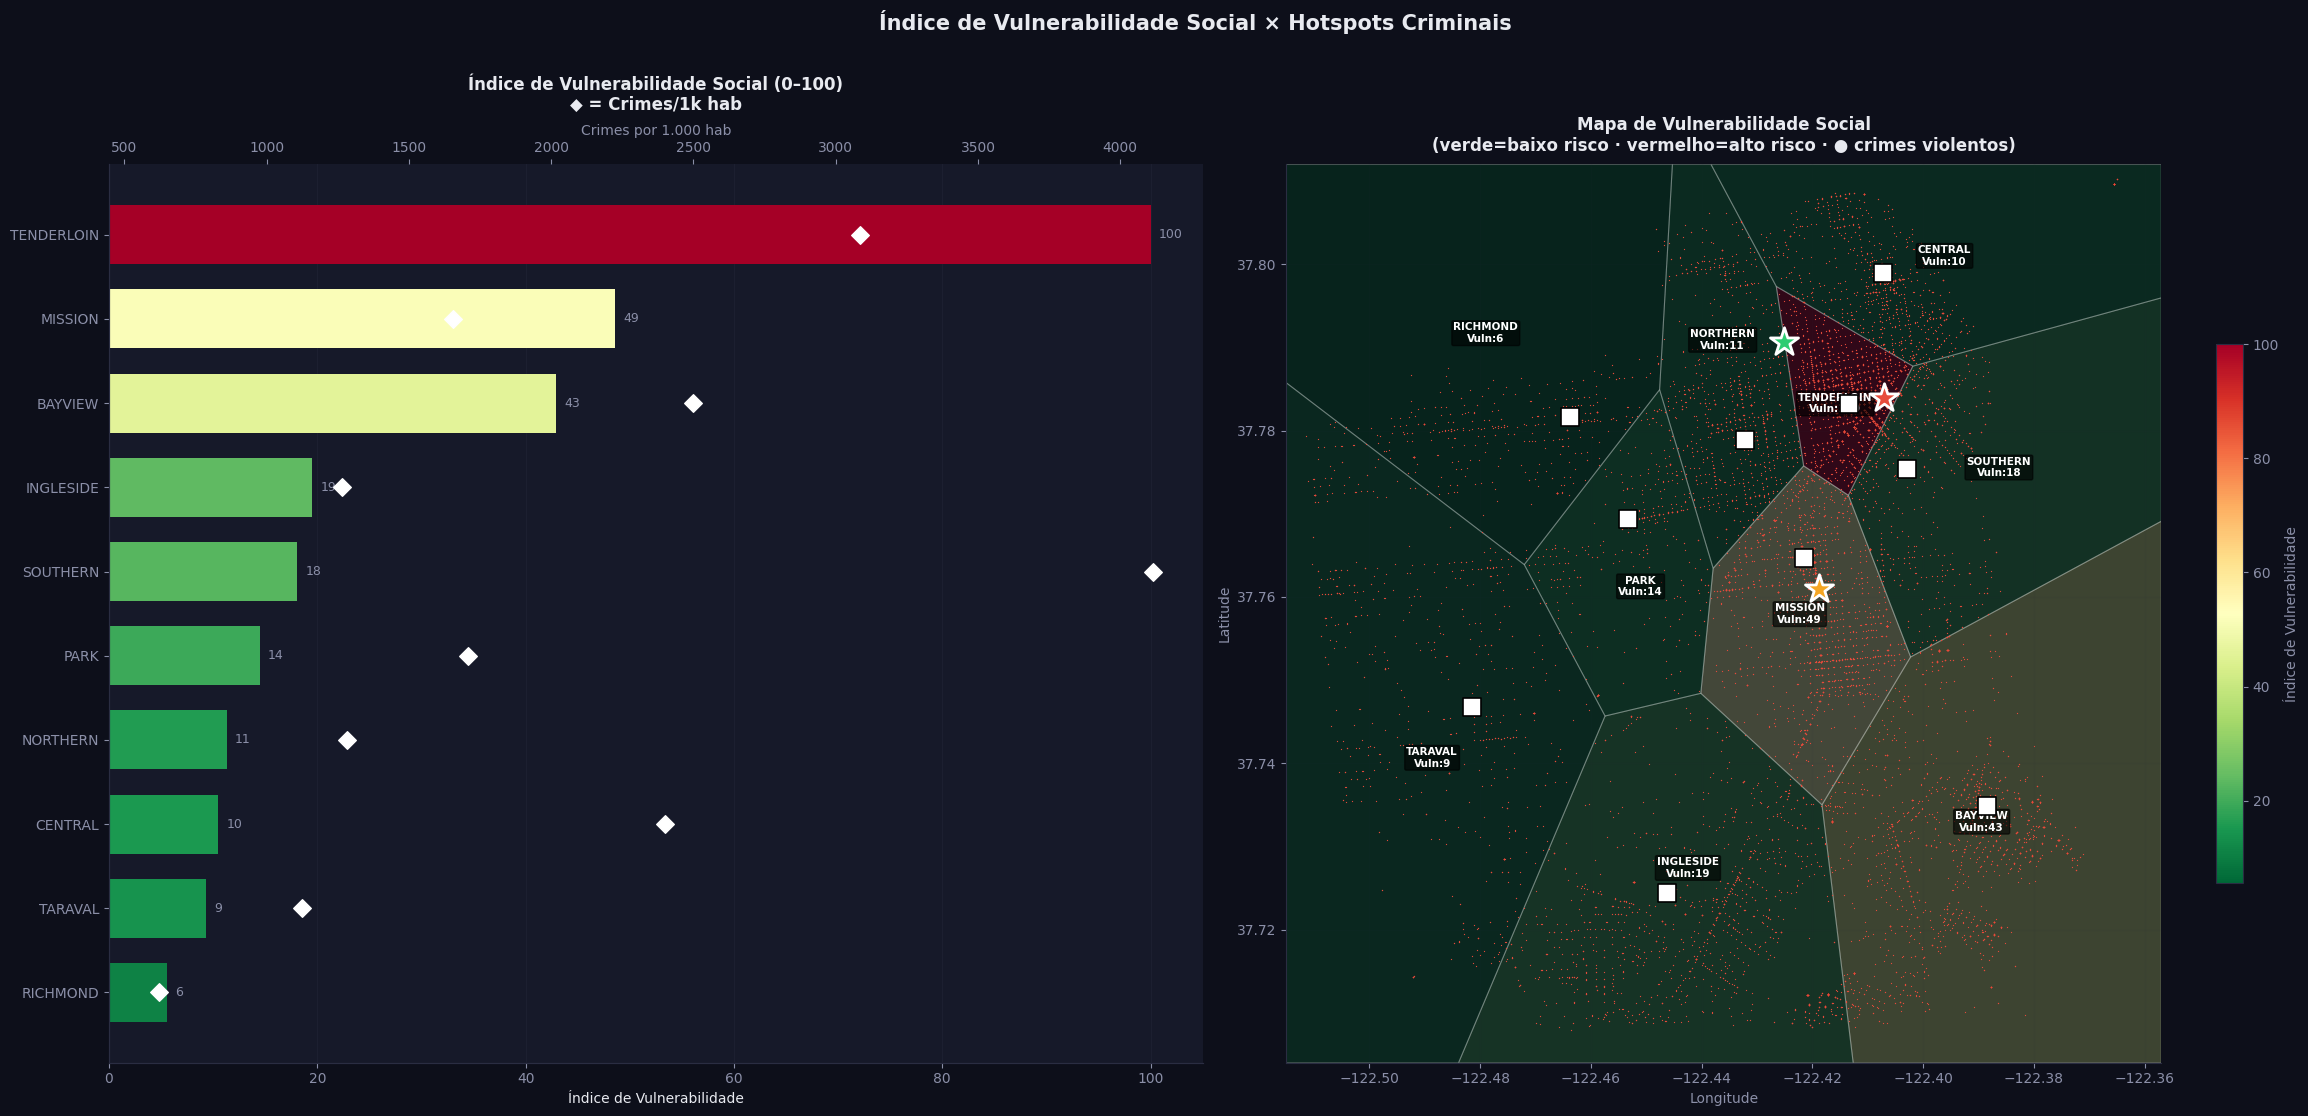

In [ ]:
# ── Painel socioeconômico 2: perfil radar + mapa de vulnerabilidade ────────
fig, axes = plt.subplots(1, 2, figsize=(24, 11))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Índice de Vulnerabilidade Social × Hotspots Criminais',
             fontsize=15, fontweight='bold', color=TXT, y=1.01)

# ── Índice de vulnerabilidade (0-100) ─────────────────────────────────────
# Normaliza e combina: pobreza, desemprego, sem HS, % não-branco (proxy histórico de desinvestimento)
from sklearn.preprocessing import MinMaxScaler

vuln_cols = ['poverty_rate','unemployment_rate','pct_no_hs','pct_renter']
scaler_v  = MinMaxScaler()
socio_copy = socio.copy()
socio_copy['vuln_index'] = scaler_v.fit_transform(socio[vuln_cols]).mean(axis=1) * 100

# ── Barras de vulnerabilidade ─────────────────────────────────────────────
ax = axes[0]
ranked_v = socio_copy['vuln_index'].sort_values(ascending=True)
norm_v = plt.Normalize(0, 100)
cols_v = plt.cm.RdYlGn_r(norm_v(ranked_v.values))
bars = ax.barh(ranked_v.index, ranked_v.values, color=cols_v, height=0.7, edgecolor='none')

# Adicionar crimes/1k como marcador
ax2_twin = ax.twiny()
ranked_c = socio_copy.loc[ranked_v.index, 'crimes_per_1k']
ax2_twin.scatter(ranked_c.values, range(len(ranked_v)), color='white',
                 s=80, zorder=5, marker='D', label='Crimes/1k')
ax2_twin.set_xlabel('Crimes por 1.000 hab', color=TXT_DIM)
ax2_twin.tick_params(colors=TXT_DIM)
ax2_twin.spines['top'].set_color(BORDER)

for bar, val, dist in zip(bars, ranked_v.values, ranked_v.index):
    ax.text(val+0.8, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9, color=TXT_DIM)

ax.set_title('Índice de Vulnerabilidade Social (0–100)\n◆ = Crimes/1k hab',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Índice de Vulnerabilidade')
ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)

# ── Mapa: crimes coloridos por vulnerabilidade do distrito ────────────────
ax = axes[1]
ax.set_facecolor('#0a0c14')
ax.set_xlim(SF_BBOX[0], SF_BBOX[2]); ax.set_ylim(SF_BBOX[1], SF_BBOX[3])

# Regiões Voronoi coloridas pelo índice de vulnerabilidade
vuln_min = socio_copy['vuln_index'].min()
vuln_max = socio_copy['vuln_index'].max()
norm_vm  = plt.Normalize(vuln_min, vuln_max)
cmap_vm  = plt.cm.RdYlGn_r

for i, (name, poly) in enumerate(voronoi_polys.items()):
    vi = socio_copy.loc[name, 'vuln_index'] if name in socio_copy.index else 50
    color = cmap_vm(norm_vm(vi))
    patch = MplPolygon(poly, closed=True, facecolor=color,
                       alpha=0.25, edgecolor='white', linewidth=0.8)
    ax.add_patch(patch)
    cx = float(np.mean(poly[:,0])); cy = float(np.mean(poly[:,1]))
    ax.text(cx, cy, f'{name}\nVuln:{vi:.0f}',
            ha='center', va='center', fontsize=7.5, color='white',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.6))

# Crimes violentos (pontos)
viol_pts = df_crime[df_crime['CrimeType']=='Violento'].sample(15_000, random_state=42)
ax.scatter(viol_pts['X'], viol_pts['Y'], c=RED, s=0.8, alpha=1,
           rasterized=True, linewidths=0)

# Delegacias
for i, (name, st) in enumerate(STATIONS.items()):
    ax.scatter(st['lon'], st['lat'], c='white', s=160, zorder=12,
               edgecolors='black', linewidths=1.2, marker='s')

# Novas delegacias
for d, color, dname in zip(delegacias, DELEGACIA_COLORS, DELEGACIA_NAMES):
    ax.scatter(d['cx'], d['cy'], c=color, s=450, zorder=15,
               edgecolors='white', linewidths=2, marker='*')

sm = plt.cm.ScalarMappable(cmap=cmap_vm, norm=norm_vm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, label='Índice de Vulnerabilidade')
cbar.ax.yaxis.label.set_color(TXT_DIM)

ax.set_title('Mapa de Vulnerabilidade Social\n(verde=baixo risco · vermelho=alto risco · ● crimes violentos)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Longitude', color=TXT_DIM); ax.set_ylabel('Latitude', color=TXT_DIM)
ax.grid(alpha=0.06)
for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.show()


In [ ]:
# ── Tabela síntese: socioeconômico + criminalidade por distrito ────────────
print(f"{'='*90}")
print(f"{'SÍNTESE SOCIOECONÔMICA × CRIMINALIDADE POR DISTRITO POLICIAL':^90}")
print(f"{'Fonte: ACS 2005-2009 | Census 2010 | SF Crime Dataset 2003-2015':^90}")
print(f"{'='*90}")
print(f"{'Distrito':<12} {'Renda Med.':>10} {'Pobreza':>8} {'Desemprg':>9} "
      f"{'Crimes/1k':>10} {'%Violento':>10} {'Resolução':>10} {'Vuln.Idx':>9}")
print(f"{'-'*90}")
for dist in socio_copy.sort_values('crimes_per_1k', ascending=False).index:
    r = socio_copy.loc[dist]
    print(f"{dist:<12} ${r['median_income']:>9,.0f} {r['poverty_rate']:>7.1f}% "
          f"{r['unemployment_rate']:>8.1f}% {r['crimes_per_1k']:>10.0f} "
          f"{r['violent_pct']:>9.1f}% {r['resolution_rate']:>9.1f}% "
          f"{r['vuln_index']:>9.0f}")
print(f"{'='*90}")



               SÍNTESE SOCIOECONÔMICA × CRIMINALIDADE POR DISTRITO POLICIAL               
             Fonte: ACS 2005-2009 | Census 2010 | SF Crime Dataset 2003-2015              
Distrito     Renda Med.  Pobreza  Desemprg  Crimes/1k  %Violento  Resolução  Vuln.Idx
------------------------------------------------------------------------------------------
SOUTHERN     $   58,500    11.4%      8.2%       4115      11.8%      40.2%        18
TENDERLOIN   $   22,800    38.2%     18.5%       3087      13.8%      66.1%       100
BAYVIEW      $   35,600    20.3%     14.6%       2498      17.1%      42.1%        43
CENTRAL      $   71,400     9.1%      6.1%       2401      11.9%      29.3%        10
PARK         $   61,200    10.2%      7.1%       1706      10.5%      37.3%        14
MISSION      $   47,200    17.8%     10.4%       1656      14.4%      47.4%        49
NORTHERN     $   72,100     8.6%      5.8%       1283      11.9%      33.3%        11
INGLESIDE    $   55,800    12.1%      8

## 17. Conclusão

### Recomendação Final

| Delegacia | Cluster | Distrito | Volume Total | Especialidade | Taxa Resolução | Pico Horário |
|---|---|---|---|---|---|---|
| **Alpha** | C0 | Southern | ~290k | Patrimonial / Drogas | ~39% | 18h |
| **Beta**  | C6 | Mission  | ~161k | Patrimonial / Geral | ~37% | 17h |
| **Gamma** | C4 | Northern | ~126k | Patrimonial / Crimes de Rua | ~41% | 18h |



---

### Principais Insights da Análise

**Temporal**
- O crime cresce no decorrer do dia, com pico entre **12h e 20h** em toda a cidade
- **Sextas e sábados** concentram o maior volume semanal
- **Verão** (Jul–Ago) tende a apresentar leve aumento em crimes violentos

**Geográfico**
- **Southern, Mission e Northern** são os 3 distritos com maior volume absoluto
- O DBSCAN revelou micro-hotspots na **Bryant St** e na região da **Mission/16th St**

**Tipologia**
- **Patrimonial** domina (54% dos crimes): foco em furto, roubo de veículos e arrombamento
- **Taxa de resolução média: ~39%**: crimes de drogas e mandados têm maior taxa; furtos têm a menor
- O network graph mostra que **Larceny/Theft e Vehicle Theft** têm perfis horários altamente correlacionados

**WordCloud**
- Termos dominantes: `THEFT`, `GRAND`, `AUTO`, `PROPERTY`, `LOCKED`: confirmam predominância patrimonial
- Crimes violentos concentram termos como `BATTERY`, `ASSAULT`, `WEAPON`



Percebe-se que a nova delegacia Alpha, em seu raio, engloba o range da delegacia de TENDERLOIN, que nao esta suprindo o suficiente